# ACCIDENT @ CVPR: Zero-Shot CCTV Traffic Accident Understanding

**Competition:** ACCIDENT @ CVPR 2026 -- AUTOPILOT Workshop (Kaggle)

**Notebook Focus:**
- Temporal localization of accident onset from fixed-view CCTV video clips
- Spatial localization of impact point via open-vocabulary grounding and optical flow
- Zero-shot collision-type classification using pre-trained vision-language models

## Introduction

Traffic accident analysis from fixed CCTV infrastructure presents challenges distinct from general video understanding. Accident events are temporally sparse, spatially unpredictable, and visually subtle relative to normal traffic flow. The benchmark defined by ACCIDENT @ CVPR 2026 compounds these challenges by excluding labeled real training footage, requiring methods that generalize without dataset-specific fine-tuning.

This notebook constructs a zero-shot inference pipeline whose **primary signal is per-vehicle detection and tracking**: an accident is an event between two specific objects, so the colliding pair's kinematics (contact time, joint deceleration, box-intersection centroid, approach-angle geometry) answer all three benchmark questions more directly than any whole-frame signal can. A chain of zero-shot vision-language models backs every stage up when tracking is unreliable:

| Stage | Question | Primary signal (tracking) | Fallback (zero-shot) |
|-------|----------|---------------------------|----------------------|
| 1 -- *When* | accident time | first box contact + joint deceleration peak | frame-diff anchor + bounded PE refinement |
| 2 -- *What* | collision type | pre-impact velocity angle + contact geometry | CLIP + Qwen2.5-VL soft ensemble |
| 3 -- *Where* | impact point | box-intersection centroid at impact | OWLv2 grounding + flow centroid |

The synthetic CARLA dataset is used for pipeline calibration and EDA. Submissions target the real CCTV test set. Every design decision below is validated (or rejected) on a *diverse* calibration set covering all five collision types -- an earlier revision tuned on a head-on-only subset and regressed badly on the other four types (see Section 7).

## Table of Contents

1. [Data Acquisition](#1-data-acquisition)
2. [Data Inspection](#2-data-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Feature Engineering](#5-feature-engineering)
6. [Modeling](#6-modeling)
7. [Evaluation](#7-evaluation)
8. [Test Inference and Submission](#8-test-inference-and-submission)
9. [Conclusion](#9-conclusion)
10. [References](#10-references)

---
## 0. Environment Setup

In [2]:
# [SETUP] Standard library imports -- order: stdlib, third-party, local
import re
import json
import gzip
import time
import warnings
import pathlib
from collections import defaultdict

# [SETUP] Numerical and data processing
import numpy as np
import pandas as pd

# [SETUP] Visualization stack
import matplotlib.pyplot as plt
import seaborn as sns

# [SETUP] Computer vision
import cv2
from PIL import Image as PILImage

# [SETUP] Suppress non-critical runtime warnings
warnings.filterwarnings('ignore')

print('[STATUS] Core imports complete')

[STATUS] Core imports complete


In [3]:
# [SETUP] Global matplotlib and seaborn configuration
sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams.update({
    'figure.figsize'  : (10, 6),
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
    'legend.fontsize' : 10,
    'figure.dpi'      : 120,
    'savefig.bbox'    : 'tight',
})

# [SETUP] Consistent color palette for all plots
PALETTE = {
    'primary'    : '#1f77b4',
    'secondary'  : '#ff7f0e',
    'tertiary'   : '#2ca02c',
    'quaternary' : '#d62728',
    'quinary'    : '#9467bd',
    'senary'     : '#8c564b',
}

print('[STATUS] Plot configuration applied')

[STATUS] Plot configuration applied


In [5]:
# [SETUP] Reproducibility seed for all stochastic operations
SEED = 42
np.random.seed(SEED)

# [SETUP] Root paths -- verified against actual Kaggle competition dataset structure
# Competition slug: accident  |  input root: /kaggle/input/competitions/accident
BASE_DIR        = pathlib.Path('/kaggle/input/accident')
SYNTHETIC_DIR   = BASE_DIR / 'sim_dataset'    # synthetic CARLA dataset
REAL_VIDEOS_DIR = BASE_DIR / 'videos'         # real CCTV test videos
OUTPUT_DIR      = pathlib.Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# [SETUP] Key file paths
LABELS_CSV            = SYNTHETIC_DIR / 'labels.csv'                # synthetic supervision index
TEST_METADATA_CSV     = BASE_DIR      / 'test_metadata.csv'         # real test scene tags
SAMPLE_SUBMISSION     = BASE_DIR      / 'sample_submission.csv'     # output schema reference
ANNOTATION_CLASSES    = SYNTHETIC_DIR / 'annotation_classes.yaml'   # segmentation class map
SYNTHETIC_VIDEOS_DIR  = SYNTHETIC_DIR / 'videos'                    # {head-on,rear-end,sideswipe,single,t-bone}/
VIDEO_ANNOTATIONS_DIR = SYNTHETIC_DIR / 'video_annotations'         # per-video annotation files

COLLISION_TYPES = ['head-on', 'rear-end', 'sideswipe', 'single', 't-bone']


def resolve_video_path(rgb_path: str) -> pathlib.Path:
    """Resolve an rgb_path value from labels.csv to an absolute video path.

    rgb_path values are relative to sim_dataset/ (e.g. videos/head-on/clip.mp4),
    but earlier dataset revisions used paths relative to the competition root.
    Try both roots and return whichever exists, so downstream code never
    silently operates on a non-existent path (an earlier revision of this
    notebook lost 20/20 calibration videos to exactly that bug).
    """
    p = pathlib.Path(rgb_path)
    if p.is_absolute():
        return p
    for root in (SYNTHETIC_DIR, BASE_DIR):
        candidate = root / p
        if candidate.exists():
            return candidate
    return SYNTHETIC_DIR / p  # best guess; existence is asserted before inference


print('[STATUS] Path constants initialized')
print(f'  BASE_DIR        : {BASE_DIR}')
print(f'  SYNTHETIC_DIR   : {SYNTHETIC_DIR}')
print(f'  REAL_VIDEOS_DIR : {REAL_VIDEOS_DIR}')

[STATUS] Path constants initialized
  BASE_DIR        : \kaggle\input\accident
  SYNTHETIC_DIR   : \kaggle\input\accident\sim_dataset
  REAL_VIDEOS_DIR : \kaggle\input\accident\videos


In [6]:
# [STATUS] File availability audit -- all critical paths verified before downstream steps
path_checks = [
    ('BASE_DIR',              BASE_DIR),
    ('SYNTHETIC_DIR',         SYNTHETIC_DIR),
    ('SYNTHETIC_VIDEOS_DIR',  SYNTHETIC_VIDEOS_DIR),
    ('VIDEO_ANNOTATIONS_DIR', VIDEO_ANNOTATIONS_DIR),
    ('REAL_VIDEOS_DIR',       REAL_VIDEOS_DIR),
    ('labels.csv',            LABELS_CSV),
    ('annotation_classes.yaml', ANNOTATION_CLASSES),
    ('test_metadata.csv',     TEST_METADATA_CSV),
    ('sample_submission.csv', SAMPLE_SUBMISSION),
]

audit_df = pd.DataFrame([
    {
        'label'  : label,
        'path'   : str(p),
        'exists' : p.exists(),
        'kind'   : 'dir' if p.is_dir() else ('file' if p.is_file() else 'missing'),
    }
    for label, p in path_checks
])

# All rows should show exists=True before proceeding
display(audit_df.style.map(
    lambda v: 'color: green; font-weight: bold' if v is True
              else ('color: red; font-weight: bold' if v is False else ''),
    subset=['exists']
))

,label,path,exists,kind
0,BASE_DIR,\kaggle\input\accident,False,missing
1,SYNTHETIC_DIR,\kaggle\input\accident\sim_dataset,False,missing
2,SYNTHETIC_VIDEOS_DIR,\kaggle\input\accident\sim_dataset\videos,False,missing
3,VIDEO_ANNOTATIONS_DIR,\kaggle\input\accident\sim_dataset\video_annotations,False,missing
4,REAL_VIDEOS_DIR,\kaggle\input\accident\videos,False,missing
5,labels.csv,\kaggle\input\accident\sim_dataset\labels.csv,False,missing
6,annotation_classes.yaml,\kaggle\input\accident\sim_dataset\annotation_classes.yaml,False,missing
7,test_metadata.csv,\kaggle\input\accident\test_metadata.csv,False,missing
8,sample_submission.csv,\kaggle\input\accident\sample_submission.csv,False,missing


In [5]:
# [SETUP] Install model dependencies (requires internet on Kaggle)
#   - ultralytics    : YOLOv8 vehicle detector (tracking stage)
#   - CLIP           : zero-shot classification (Stage 2)
#   - perception_models : Perception Encoder for temporal refinement (Stage 1)
#   - transformers stack : Qwen2.5-VL (Stage 2) and OWLv2 (Stage 3)
import subprocess

def pip_install(args, label):
    result = subprocess.run(['pip', 'install', '-q'] + args, capture_output=True, text=True)
    print(f'[STATUS] {label} install exit code: {result.returncode}')
    return result.returncode

pip_install(['ultralytics'], 'ultralytics (YOLOv8)')
pip_install(['git+https://github.com/openai/CLIP.git'], 'CLIP')

result = subprocess.run(
    ['git', 'clone', 'https://github.com/facebookresearch/perception_models.git'],
    capture_output=True, text=True
)
print('[STATUS] perception_models clone exit code:', result.returncode)
pip_install(['-e', 'perception_models'], 'perception_models')

# -U is not optional. Kaggle ships a transformers that predates Qwen3-VL, and
# `pip install transformers` on an already-satisfied requirement is a no-op --
# it exits 0, prints nothing, and leaves the old version in place. That is
# exactly how a previous run reported "install exit code: 0" and then failed
# with "Transformers does not recognize qwen3_vl", silently fell back to
# constants for all 2027 clips, and produced a submission that scored nothing.
pip_install(['-U', 'transformers>=4.57', 'accelerate', 'qwen-vl-utils', 'bitsandbytes'],
            'transformers stack (upgraded for Qwen3-VL)')

import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING_NAMES

print(f'[STATUS] transformers {transformers.__version__}')
QWEN3_VL_OK = 'qwen3_vl' in CONFIG_MAPPING_NAMES
print(f'[STATUS] qwen3_vl architecture recognized: {QWEN3_VL_OK}')
if not QWEN3_VL_OK:
    print('[FATAL] This transformers cannot load Qwen3-VL. Section 6.10 will not run.')
    print('        Restart the kernel after this cell (an upgrade does not take effect')
    print('        in an already-imported module), or install from source:')
    print('          pip install -U git+https://github.com/huggingface/transformers.git')

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[STATUS] torch {torch.__version__} | device: {DEVICE}')

[STATUS] ultralytics (YOLOv8) install exit code: 0
[STATUS] CLIP install exit code: 0
[STATUS] perception_models clone exit code: 0
[STATUS] perception_models install exit code: 0
[STATUS] transformers stack (upgraded for Qwen3-VL) install exit code: 0
[STATUS] transformers 5.14.1
[STATUS] qwen3_vl architecture recognized: True
[STATUS] torch 2.8.0+cu126 | device: cuda


---
## 1. Data Acquisition

This section loads all structured metadata from disk: the synthetic labels index, per-video annotation references, and the real test metadata. Raw binary video assets are accessed later via path references rather than bulk loading.

In [6]:
# [LOAD] Synthetic labels index -- primary supervision signal for pipeline calibration
labels_df = pd.read_csv(LABELS_CSV) if LABELS_CSV.exists() else pd.DataFrame()

# [LOAD] Real test metadata -- coarse scene tags provided for analysis, not scoring
test_df = pd.read_csv(TEST_METADATA_CSV) if TEST_METADATA_CSV.exists() else pd.DataFrame()

dim_report = pd.DataFrame({
    'dataset' : ['synthetic_labels', 'test_metadata'],
    'rows'    : [len(labels_df), len(test_df)],
    'columns' : [labels_df.shape[1] if not labels_df.empty else 0,
                 test_df.shape[1] if not test_df.empty else 0],
})
display(dim_report)
print('[SUCCESS] Metadata loaded')

,dataset,rows,columns
0,synthetic_labels,2211,19
1,test_metadata,2027,10


[SUCCESS] Metadata loaded


In [7]:
# [LOAD] Sample submission -- defines expected output schema for the final CSV
sample_sub = pd.read_csv(SAMPLE_SUBMISSION) if SAMPLE_SUBMISSION.exists() else pd.DataFrame()

print('Submission columns:', list(sample_sub.columns))
display(sample_sub.head(3))

Submission columns: []


""


In [8]:
# [LOAD] Enumerate video files
# Synthetic structure: sim_dataset/videos/{head-on,rear-end,sideswipe,single,t-bone}/*.mp4
synthetic_videos = []
if SYNTHETIC_VIDEOS_DIR.exists():
    for subdir in COLLISION_TYPES:
        synthetic_videos.extend(sorted((SYNTHETIC_VIDEOS_DIR / subdir).glob('*.mp4')))

# Real CCTV test videos: flat directory under videos/
real_videos = sorted(REAL_VIDEOS_DIR.glob('*.mp4')) if REAL_VIDEOS_DIR.exists() else []

inventory_rows = [{'split': 'real_test', 'collision_type': 'all', 'count': len(real_videos)}]
for subdir in COLLISION_TYPES:
    sp = SYNTHETIC_VIDEOS_DIR / subdir
    inventory_rows.append({
        'split': 'synthetic', 'collision_type': subdir,
        'count': len(list(sp.glob('*.mp4'))) if sp.exists() else 0,
    })

display(pd.DataFrame(inventory_rows))
print(f'[STATUS] Total synthetic videos : {len(synthetic_videos)}')
print(f'[STATUS] Total real test videos : {len(real_videos)}')

,split,collision_type,count
0,real_test,all,2027
1,synthetic,head-on,588
2,synthetic,rear-end,794
3,synthetic,sideswipe,405
4,synthetic,single,66
5,synthetic,t-bone,358


[STATUS] Total synthetic videos : 2211
[STATUS] Total real test videos : 2027


In [9]:
# [LOAD] Annotation files inventory
# video_annotations/ contains subdirs named like Town03_head-on_clear_00.json/
# Each subdir holds the actual annotation file(s) -- recurse and filter to files only
annotation_files = [
    p for p in sorted(VIDEO_ANNOTATIONS_DIR.rglob('*')) if p.is_file()
] if VIDEO_ANNOTATIONS_DIR.exists() else []

ann_subdirs = [
    p for p in sorted(VIDEO_ANNOTATIONS_DIR.glob('*')) if p.is_dir()
] if VIDEO_ANNOTATIONS_DIR.exists() else []

display(pd.DataFrame({
    'metric' : ['annotation_dir_exists', 'annotation_subdirs', 'annotation_files', 'sample_subdir_name'],
    'value'  : [VIDEO_ANNOTATIONS_DIR.exists(), len(ann_subdirs), len(annotation_files),
                ann_subdirs[0].name if ann_subdirs else 'n/a'],
}))

# [LOAD] Inspect schema of the first annotation file (handles .json and .json.gz)
if annotation_files:
    first_ann = annotation_files[0]
    open_fn = gzip.open if first_ann.suffix == '.gz' else open
    with open_fn(first_ann, 'rt', encoding='utf-8') as f:
        ann_sample = json.load(f)
    top_keys = list(ann_sample.keys()) if isinstance(ann_sample, dict) else f'list[{len(ann_sample)}]'
    print(f'[STATUS] {first_ann.name} top-level keys:', top_keys)
else:
    print('[STATUS] No annotation files found')

,metric,value
0,annotation_dir_exists,True
1,annotation_subdirs,2211
2,annotation_files,2211
3,sample_subdir_name,Town03_head-on_clear_00.json


[STATUS] Town03_head-on_clear_00.json top-level keys: ['base', 'collision', 'sensor']


---
## 2. Data Inspection

Systematic audit of all loaded data structures: schema review, null quantification, statistical profiling, and video-level properties (resolution, FPS, duration) extracted from a sample of clips for hardware-aware planning.

In [10]:
# [INSPECT] Schema of synthetic labels -- column names, dtypes, null counts
if not labels_df.empty:
    display(pd.DataFrame({
        'column'    : labels_df.columns,
        'dtype'     : labels_df.dtypes.values,
        'null_count': labels_df.isnull().sum().values,
        'null_pct'  : (labels_df.isnull().mean().values * 100).round(2),
    }))

,column,dtype,null_count,null_pct
0,rgb_path,object,0,0.0
1,annotations_path,object,0,0.0
2,type,object,0,0.0
3,accident_time,float64,0,0.0
4,accident_frame,int64,0,0.0
5,center_x,float64,0,0.0
6,center_y,float64,0,0.0
7,x1,float64,0,0.0
8,y1,float64,0,0.0
9,x2,float64,0,0.0


In [11]:
# [INSPECT] Statistical summary and sample rows
if not labels_df.empty:
    display(labels_df.describe().T.round(4))
    display(labels_df.head(5))

,count,mean,std,min,25%,50%,75%,max
accident_time,2211.0,7.6057,3.3008,1.0500,5.1500,6.9000,9.8000,20.7500
accident_frame,2211.0,152.1149,66.0161,21.0000,103.0000,138.0000,196.0000,415.0000
center_x,2211.0,0.4984,0.1298,0.0552,0.4186,0.5039,0.5836,0.9305
center_y,2211.0,0.4997,0.1808,0.0176,0.3787,0.5042,0.6241,0.9444
x1,2211.0,0.4508,0.1324,0.0000,0.3693,0.4625,0.5380,0.8615
y1,2211.0,0.4321,0.1720,0.0000,0.3148,0.4389,0.5519,0.8898
x2,2211.0,0.5460,0.1307,0.1104,0.4641,0.5453,0.6307,0.9995
y2,2211.0,0.5674,0.1947,0.0352,0.4333,0.5657,0.6935,0.9991
camera_position,2211.0,45.5563,57.1979,0.0000,14.0000,29.0000,44.5000,240.0000
no_frames,2211.0,353.3641,77.6569,116.0000,299.0000,351.0000,405.0000,644.0000


,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40
3,videos/sideswipe/Town05_sideswipe_night_30.mp4,video_annotations/Town05_sideswipe_night_30.js...,sideswipe,7.75,155,0.427604,0.600000,0.393229,0.551852,0.461979,0.648148,Town05,night,30,488,24.40,1080,1920,68
4,videos/sideswipe/Town05_sideswipe_clear_26.mp4,video_annotations/Town05_sideswipe_clear_26.js...,sideswipe,9.40,188,0.579948,0.261111,0.541146,0.195370,0.618750,0.326852,Town05,clear,26,468,23.40,1080,1920,33


In [12]:
# [INSPECT] Collision type distribution in synthetic labels
if not labels_df.empty and 'type' in labels_df.columns:
    type_counts = labels_df['type'].value_counts().reset_index()
    type_counts.columns = ['collision_type', 'count']
    type_counts['pct'] = (type_counts['count'] / type_counts['count'].sum() * 100).round(2)
    display(type_counts)

,collision_type,count,pct
0,rear-end,794,35.91
1,head-on,588,26.59
2,sideswipe,405,18.32
3,t-bone,358,16.19
4,single,66,2.99


In [13]:
# [INSPECT] Schema of real test metadata
if not test_df.empty:
    display(pd.DataFrame({
        'column'    : test_df.columns,
        'dtype'     : test_df.dtypes.values,
        'null_count': test_df.isnull().sum().values,
    }))
    display(test_df.head(5))

,column,dtype,null_count
0,path,object,0
1,region,object,0
2,scene_layout,object,0
3,weather,object,0
4,day_time,object,0
5,quality,object,0
6,no_frames,int64,0
7,duration,float64,0
8,height,int64,0
9,width,int64,0


,path,region,scene_layout,weather,day_time,quality,no_frames,duration,height,width
0,videos/Z4kg2Ev3vhk_00.mp4,Georgia,highway,normal,night,Very_Poor,424,29.967,1080,1584
1,videos/unS0-TLF1ao_00.mp4,World,signalized_intersection,normal,night,Very_Poor,148,5.920,1080,1920
2,videos/UarP8qU1S-c_00.mp4,Virginia,highway,normal,night,Poor,222,15.333,2160,3840
3,videos/UarP8qU1S-c_01.mp4,Virginia,highway,normal,night,Poor,92,6.167,2160,3840
4,videos/nAXTthLfgtI_00.mp4,Virginia,highway,normal,night,Very_Poor,208,13.875,720,960


In [14]:
# [INSPECT] Video-level property extraction from a sample of synthetic clips
# Reads container metadata only -- no full video decoding

def extract_video_meta(video_path: pathlib.Path) -> dict:
    """Return FPS, frame count, width, height, duration for a single video file."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return {
        'path'      : video_path.name,
        'fps'       : round(fps, 2),
        'n_frames'  : n_frames,
        'width'     : width,
        'height'    : height,
        'duration_s': round(n_frames / fps, 2) if fps > 0 else 0.0,
    }

SAMPLE_N = min(20, len(synthetic_videos))
video_meta_df = pd.DataFrame(
    [r for r in (extract_video_meta(p) for p in synthetic_videos[:SAMPLE_N]) if r]
)

if not video_meta_df.empty:
    display(video_meta_df.describe().T.round(2))
else:
    print('[STATUS] No video metadata extracted -- check synthetic video paths')

,count,mean,std,min,25%,50%,75%,max
fps,20.0,20.00,0.00,20.00,20.00,20.0,20.00,20.00
n_frames,20.0,364.75,67.14,249.00,315.00,380.0,419.50,453.00
width,20.0,1920.00,0.00,1920.00,1920.00,1920.0,1920.00,1920.00
height,20.0,1080.00,0.00,1080.00,1080.00,1080.0,1080.00,1080.00
duration_s,20.0,18.24,3.36,12.45,15.75,19.0,20.98,22.65


---
## 3. Data Cleaning

Targeted cleaning of the synthetic labels index: duplicate removal, type-label normalization, out-of-bounds coordinate clamping, and target validation. Video paths are resolved with `resolve_video_path` (which checks both candidate roots) so every retained record points at a file that actually exists.

In [15]:
# [CLEAN] Work on a copy; drop exact duplicates; normalize type labels
labels_clean = labels_df.copy() if not labels_df.empty else pd.DataFrame()
pre_clean_rows = len(labels_clean)

if not labels_clean.empty:
    labels_clean = labels_clean.drop_duplicates()
    if 'type' in labels_clean.columns:
        labels_clean['type'] = labels_clean['type'].str.strip().str.lower()
    print(f'[STATUS] Rows: {pre_clean_rows} -> {len(labels_clean)} after duplicate removal')
    print('[STATUS] Type values:', sorted(labels_clean['type'].unique()))

[STATUS] Rows: 2211 -> 2211 after duplicate removal
[STATUS] Type values: ['head-on', 'rear-end', 'sideswipe', 'single', 't-bone']


In [16]:
# [CLEAN] Clamp spatial coordinates to [0, 1]; drop rows with missing or invalid targets
coord_cols       = ['center_x', 'center_y', 'x1', 'y1', 'x2', 'y2']
required_targets = ['accident_time', 'center_x', 'center_y', 'type']

if not labels_clean.empty:
    for col in coord_cols:
        if col in labels_clean.columns:
            oob = ((labels_clean[col] < 0) | (labels_clean[col] > 1)).sum()
            labels_clean[col] = labels_clean[col].clip(0.0, 1.0)
            if oob > 0:
                print(f'[STATUS] Clamped {oob} out-of-bounds values in column: {col}')

    missing_mask = labels_clean[required_targets].isnull().any(axis=1)
    labels_clean = labels_clean[~missing_mask].reset_index(drop=True)
    print(f'[STATUS] Rows dropped due to missing targets: {missing_mask.sum()}')

    if 'accident_time' in labels_clean.columns:
        labels_clean = labels_clean[labels_clean['accident_time'] >= 0].reset_index(drop=True)

display(pd.DataFrame({
    'stage'   : ['pre_clean', 'post_clean'],
    'rows'    : [pre_clean_rows, len(labels_clean)],
    'removed' : [0, pre_clean_rows - len(labels_clean)],
}))

[STATUS] Rows dropped due to missing targets: 0


,stage,rows,removed
0,pre_clean,2211,0
1,post_clean,2211,0


In [17]:
# [CLEAN] Cast frame index, resolve absolute video paths, encode type labels
if not labels_clean.empty:
    if 'accident_frame' in labels_clean.columns:
        labels_clean['accident_frame'] = labels_clean['accident_frame'].astype(int)

    if 'rgb_path' in labels_clean.columns:
        labels_clean['abs_video_path'] = labels_clean['rgb_path'].map(
            lambda p: str(resolve_video_path(p))
        )
        labels_clean['video_exists'] = labels_clean['abs_video_path'].map(
            lambda p: pathlib.Path(p).exists()
        )
        n_missing = (~labels_clean['video_exists']).sum()
        print(f'[STATUS] Records with unresolvable video paths: {n_missing}')
        labels_clean = labels_clean[labels_clean['video_exists']].reset_index(drop=True)
        display(labels_clean[['rgb_path', 'abs_video_path']].head(3))

    if 'type' in labels_clean.columns:
        TYPE_VOCAB  = sorted(labels_clean['type'].unique())
        TYPE_TO_IDX = {t: i for i, t in enumerate(TYPE_VOCAB)}
        IDX_TO_TYPE = {i: t for t, i in TYPE_TO_IDX.items()}
        labels_clean['type_idx'] = labels_clean['type'].map(TYPE_TO_IDX)
        display(pd.DataFrame({'type': TYPE_VOCAB, 'idx': range(len(TYPE_VOCAB))}))

    print('[SUCCESS] Cleaning complete')

[STATUS] Records with unresolvable video paths: 0


,rgb_path,abs_video_path
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,/kaggle/input/accident/sim_dataset/videos/side...
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,/kaggle/input/accident/sim_dataset/videos/side...
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,/kaggle/input/accident/sim_dataset/videos/side...


,type,idx
0,head-on,0
1,rear-end,1
2,sideswipe,2
3,single,3
4,t-bone,4


[SUCCESS] Cleaning complete


---
## 4. Exploratory Data Analysis

Distributions of all three prediction targets (temporal, spatial, type), scene-level tag distributions in the real test metadata, and correlation structure among numeric features.

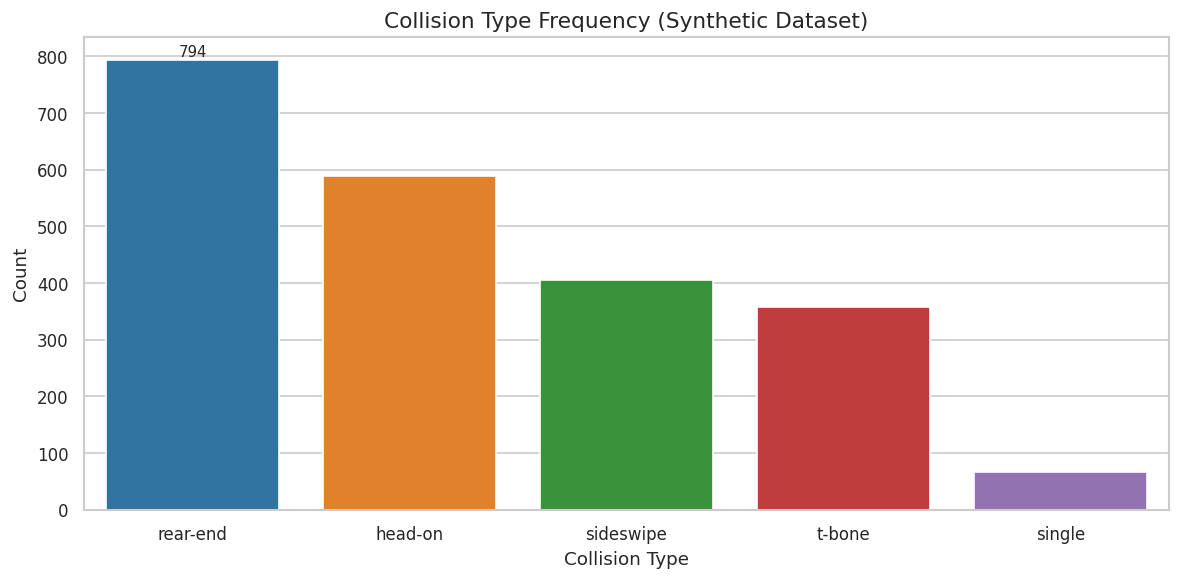

In [18]:
# [EDA] Collision type frequency
if not labels_clean.empty and 'type' in labels_clean.columns:
    type_freq = labels_clean['type'].value_counts().reset_index()
    type_freq.columns = ['collision_type', 'count']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=type_freq, x='collision_type', y='count',
                palette=list(PALETTE.values())[:len(type_freq)], ax=ax)
    ax.set_title('Collision Type Frequency (Synthetic Dataset)')
    ax.set_xlabel('Collision Type')
    ax.set_ylabel('Count')
    ax.bar_label(ax.containers[0], fontsize=9)
    plt.tight_layout()
    plt.show()

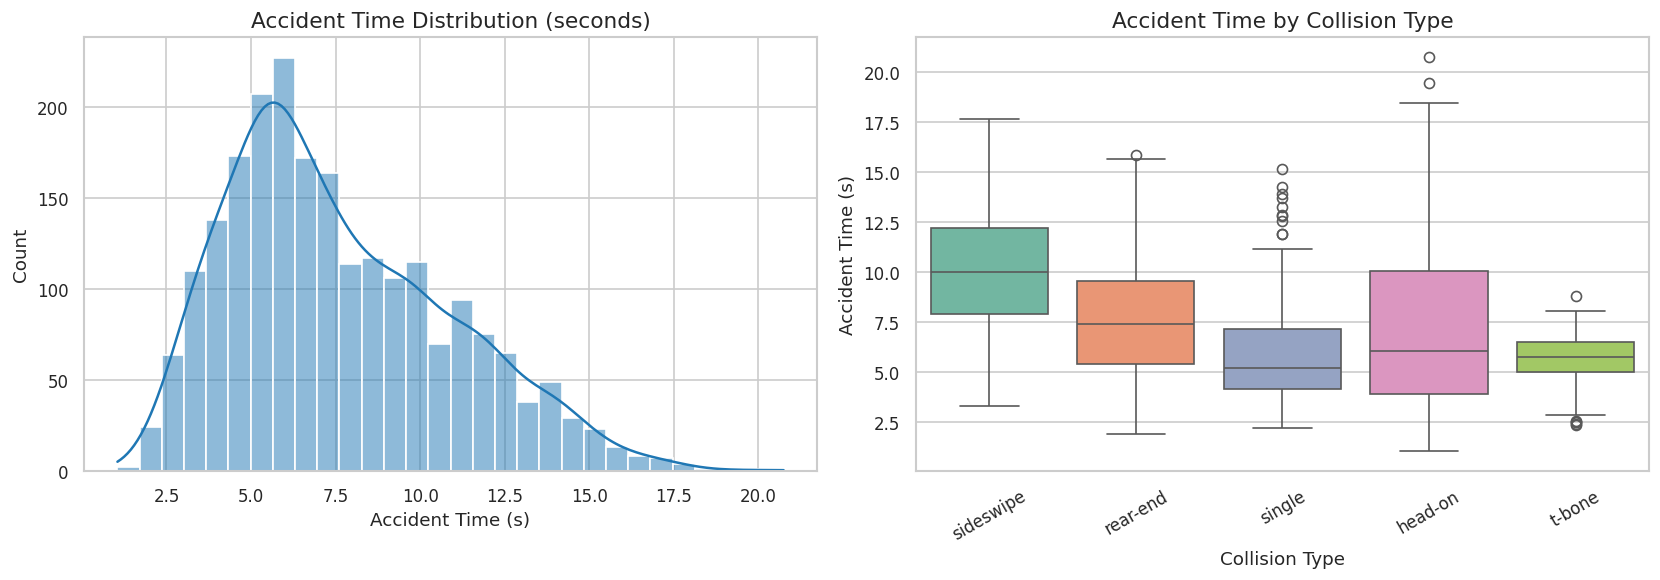

In [19]:
# [EDA] Accident time distribution -- histogram with KDE, and box plot per type
if not labels_clean.empty and 'accident_time' in labels_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(labels_clean['accident_time'], bins=30, kde=True,
                 color=PALETTE['primary'], ax=axes[0])
    axes[0].set_title('Accident Time Distribution (seconds)')
    axes[0].set_xlabel('Accident Time (s)')
    axes[0].set_ylabel('Count')

    if 'type' in labels_clean.columns:
        sns.boxplot(data=labels_clean, x='type', y='accident_time',
                    palette='Set2', ax=axes[1])
        axes[1].set_title('Accident Time by Collision Type')
        axes[1].set_xlabel('Collision Type')
        axes[1].set_ylabel('Accident Time (s)')
        axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

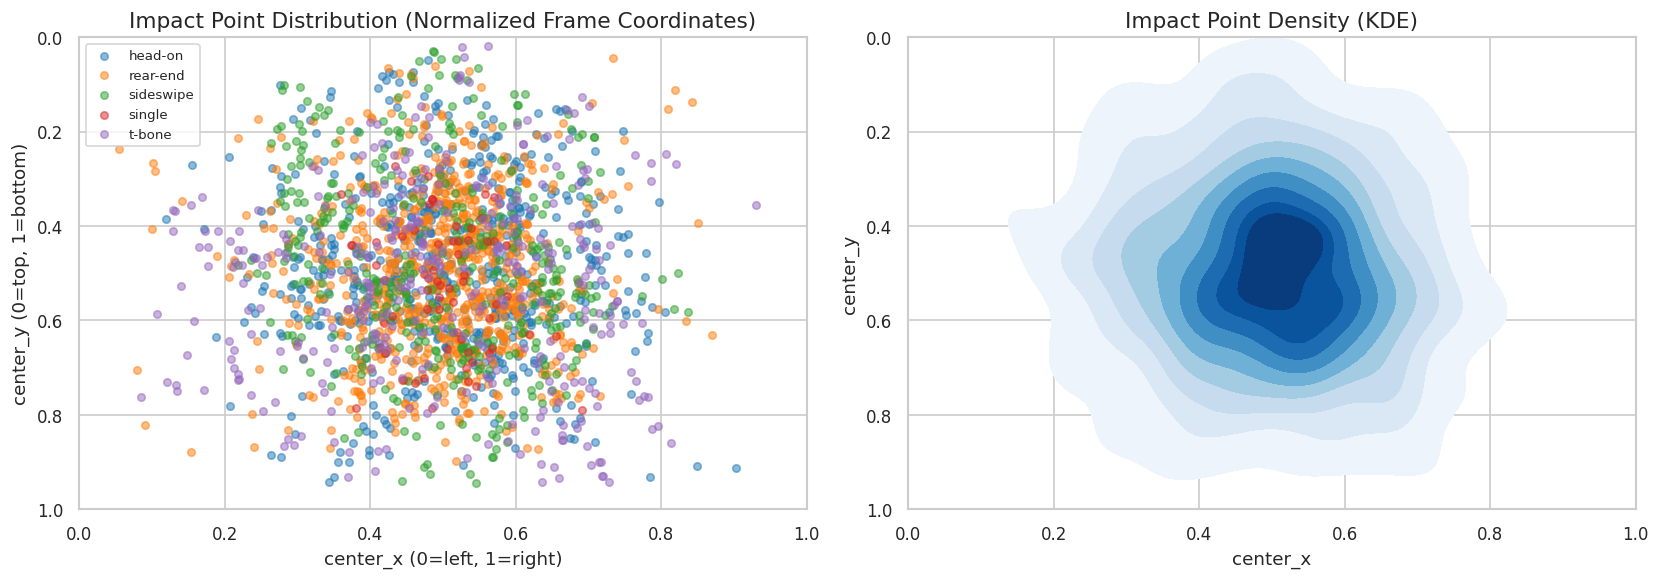

In [20]:
# [EDA] Spatial distribution of impact points -- 2D scatter and KDE
if not labels_clean.empty and all(c in labels_clean.columns for c in ['center_x', 'center_y']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for t_idx, (t_name, group) in enumerate(labels_clean.groupby('type')):
        axes[0].scatter(group['center_x'], group['center_y'],
                        label=t_name, alpha=0.5, s=20,
                        color=list(PALETTE.values())[t_idx % len(PALETTE)])
    axes[0].legend(fontsize=8)
    axes[0].set_title('Impact Point Distribution (Normalized Frame Coordinates)')
    axes[0].set_xlabel('center_x (0=left, 1=right)')
    axes[0].set_ylabel('center_y (0=top, 1=bottom)')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].invert_yaxis()  # match image coordinate convention

    sns.kdeplot(data=labels_clean, x='center_x', y='center_y',
                fill=True, cmap='Blues', ax=axes[1])
    axes[1].set_title('Impact Point Density (KDE)')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

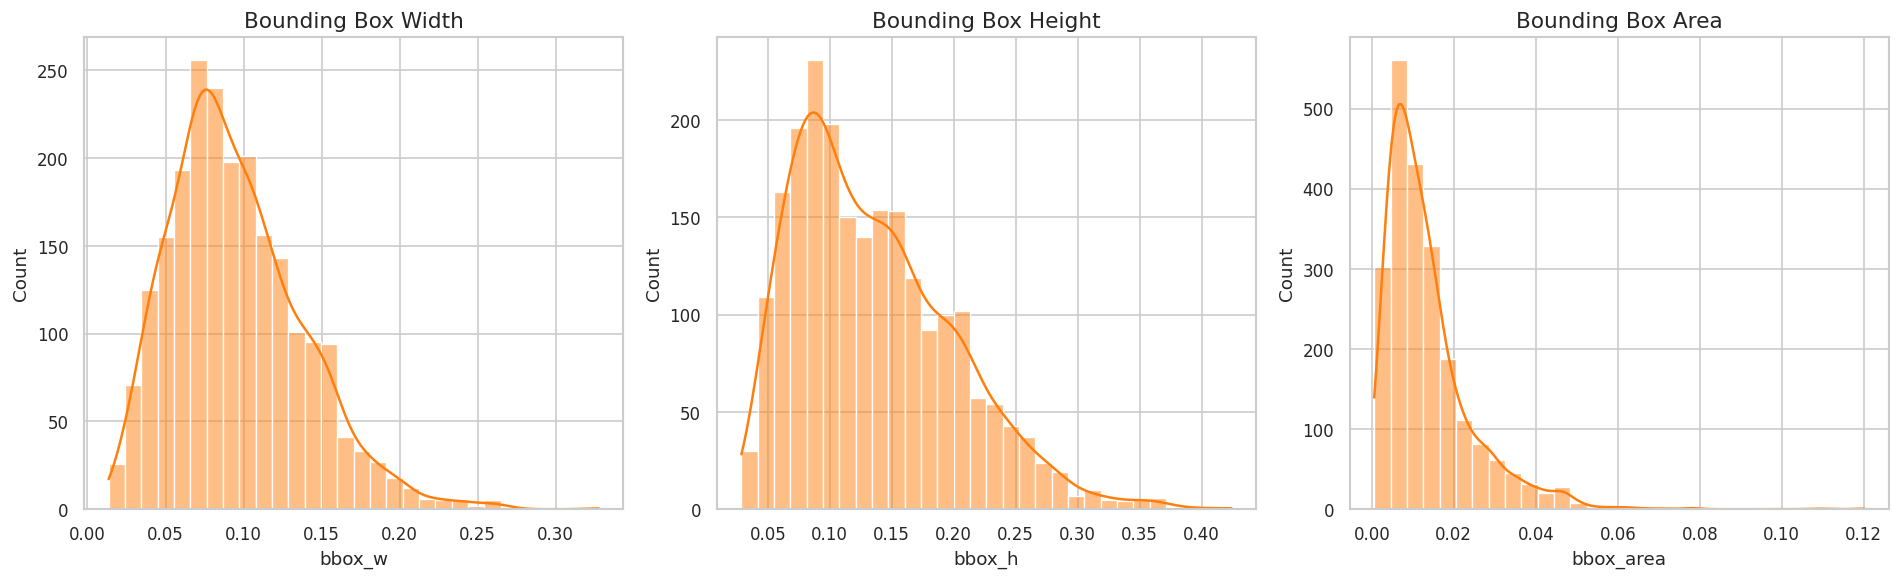

In [21]:
# [EDA] Bounding box size distributions
if not labels_clean.empty and all(c in labels_clean.columns for c in ['x1', 'y1', 'x2', 'y2']):
    labels_clean['bbox_w']    = labels_clean['x2'] - labels_clean['x1']
    labels_clean['bbox_h']    = labels_clean['y2'] - labels_clean['y1']
    labels_clean['bbox_area'] = labels_clean['bbox_w'] * labels_clean['bbox_h']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title in zip(
        axes,
        ['bbox_w', 'bbox_h', 'bbox_area'],
        ['Bounding Box Width', 'Bounding Box Height', 'Bounding Box Area'],
    ):
        sns.histplot(labels_clean[col], bins=30, kde=True, color=PALETTE['secondary'], ax=ax)
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

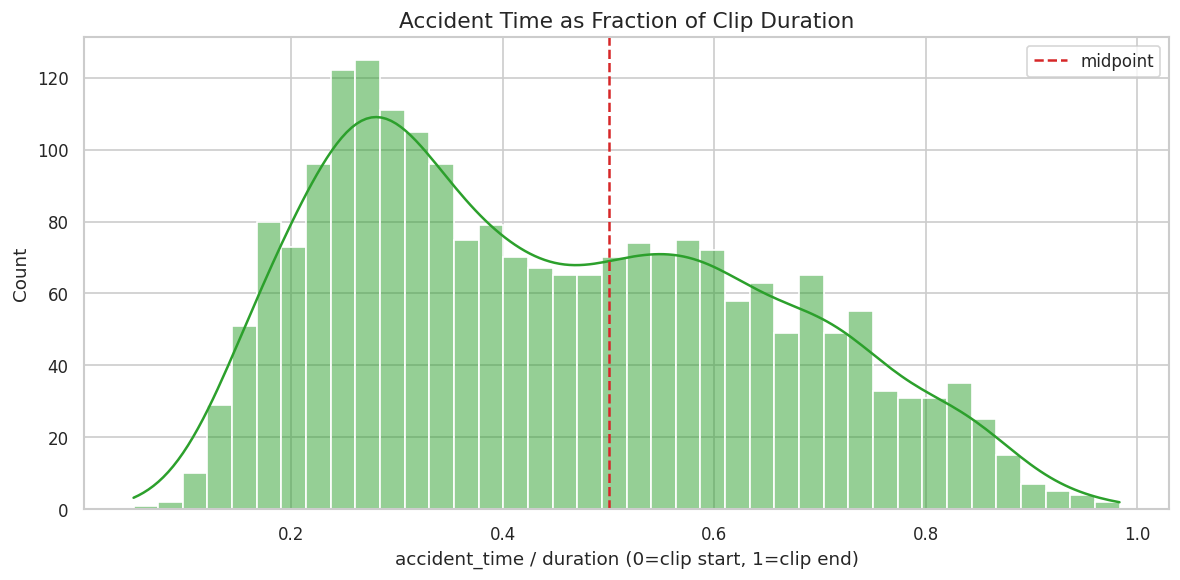

In [22]:
# [EDA] Accident time as fraction of clip duration -- relative temporal position
if not labels_clean.empty and all(c in labels_clean.columns for c in ['accident_time', 'duration']):
    labels_clean['time_fraction'] = labels_clean['accident_time'] / labels_clean['duration']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(labels_clean['time_fraction'], bins=40, kde=True,
                 color=PALETTE['tertiary'], ax=ax)
    ax.set_title('Accident Time as Fraction of Clip Duration')
    ax.set_xlabel('accident_time / duration (0=clip start, 1=clip end)')
    ax.set_ylabel('Count')
    ax.axvline(0.5, color=PALETTE['quaternary'], linestyle='--', label='midpoint')
    ax.legend()
    plt.tight_layout()
    plt.show()

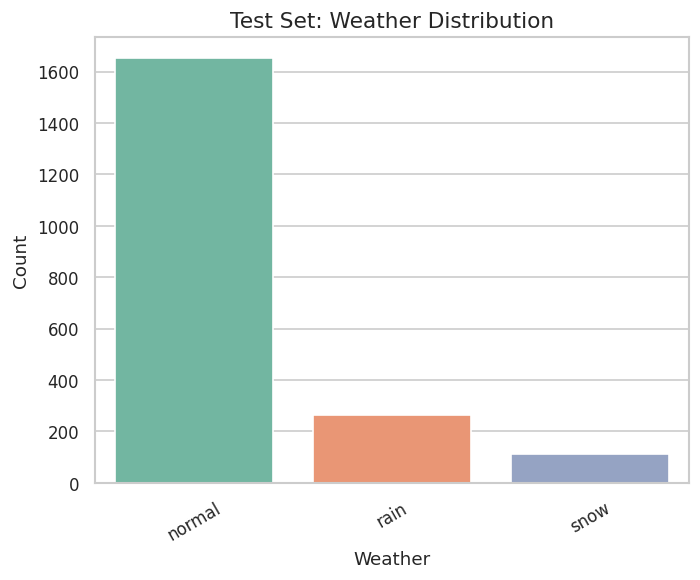

In [23]:
# [EDA] Scene condition distributions from real test metadata
SCENE_TAG_COLS = ['lighting', 'weather', 'layout']  # adjust to actual column names

if not test_df.empty:
    present_tags = [c for c in SCENE_TAG_COLS if c in test_df.columns]
    if present_tags:
        fig, axes = plt.subplots(1, len(present_tags), figsize=(6 * len(present_tags), 5))
        if len(present_tags) == 1:
            axes = [axes]
        for ax, col in zip(axes, present_tags):
            tag_freq = test_df[col].value_counts().reset_index()
            tag_freq.columns = [col, 'count']
            sns.barplot(data=tag_freq, x=col, y='count', palette='Set2', ax=ax)
            ax.set_title(f'Test Set: {col.title()} Distribution')
            ax.set_xlabel(col.title())
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print('[STATUS] Scene tag columns not found -- column names may differ')
else:
    print('[STATUS] test_df empty -- skipping scene tag plots')

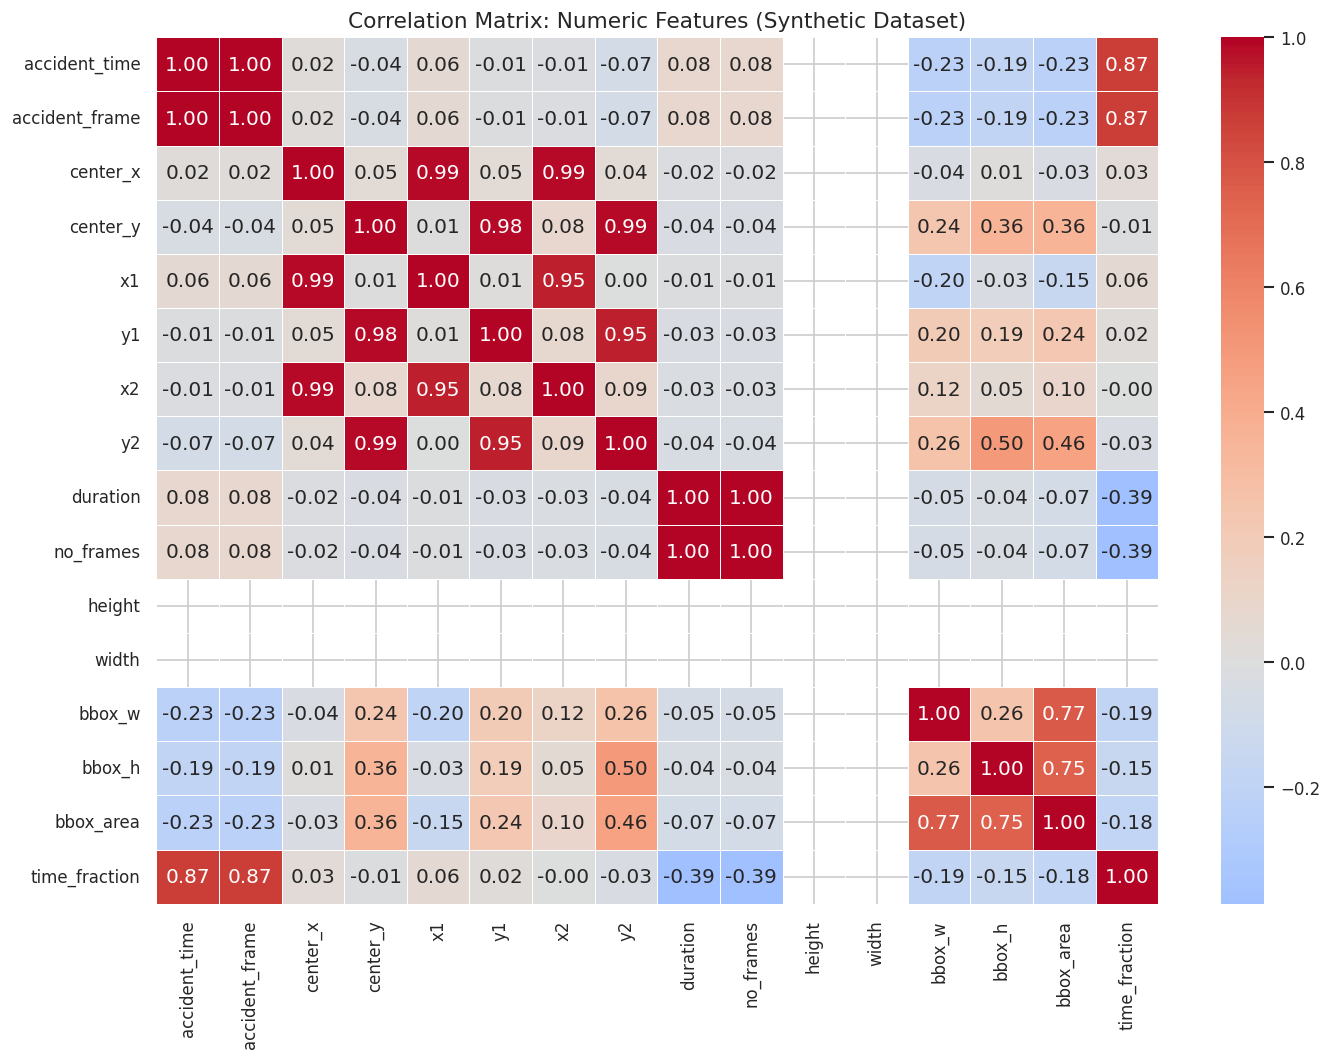

In [24]:
# [EDA] Correlation matrix across numeric features
numeric_cols = ['accident_time', 'accident_frame', 'center_x', 'center_y',
                'x1', 'y1', 'x2', 'y2', 'duration', 'no_frames',
                'height', 'width', 'bbox_w', 'bbox_h', 'bbox_area', 'time_fraction']

if not labels_clean.empty:
    present_numeric = [c for c in numeric_cols if c in labels_clean.columns]
    corr_matrix = labels_clean[present_numeric].corr()

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Matrix: Numeric Features (Synthetic Dataset)')
    plt.tight_layout()
    plt.show()

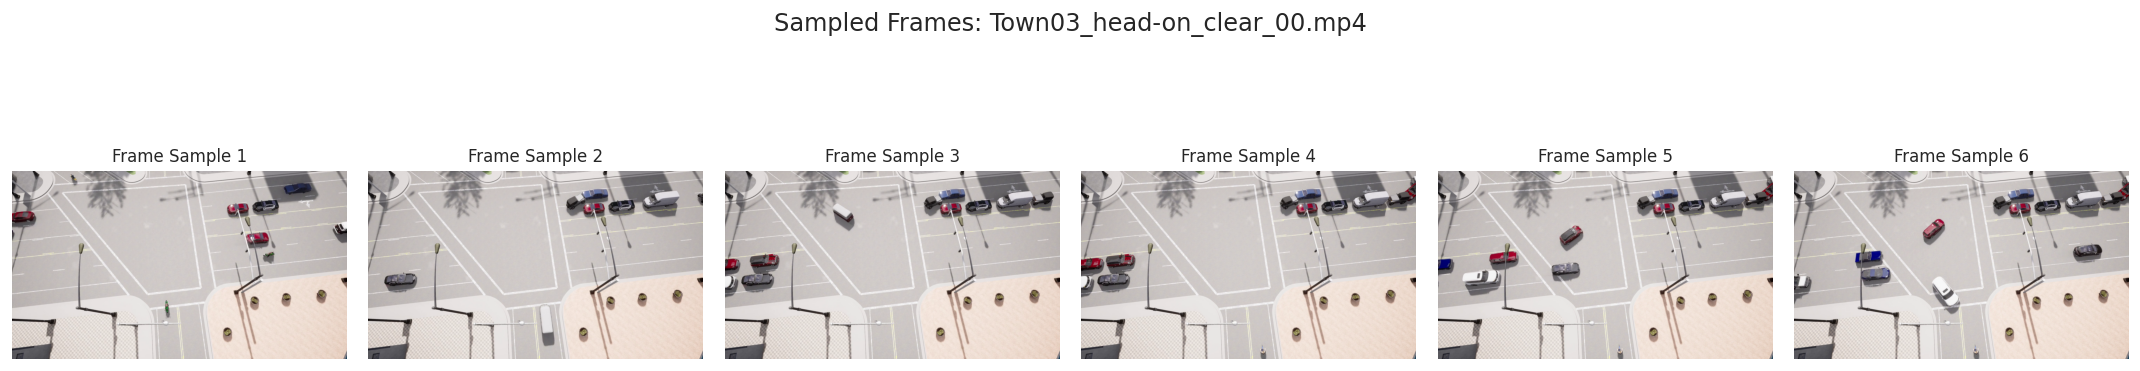

In [25]:
# [EDA] Sample frame extraction from a synthetic video for visual inspection
def sample_frames(video_path: pathlib.Path, n_frames: int = 6) -> list:
    """Extract n_frames evenly spaced RGB frames from a video."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    for idx in np.linspace(0, total - 1, n_frames, dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

if synthetic_videos:
    sampled = sample_frames(synthetic_videos[0], n_frames=6)
    if sampled:
        fig, axes = plt.subplots(1, len(sampled), figsize=(18, 4))
        for i, (ax, frame) in enumerate(zip(axes, sampled)):
            ax.imshow(frame)
            ax.set_title(f'Frame Sample {i+1}', fontsize=10)
            ax.axis('off')
        fig.suptitle(f'Sampled Frames: {synthetic_videos[0].name}')
        plt.tight_layout()
        plt.show()
else:
    print('[STATUS] No synthetic videos found for frame sampling')

---
## 5. Feature Engineering

Per-video feature extractors used by the inference pipeline:

1. **Frame-difference time series** -- sharp intensity changes indicating a collision (temporal anchor).
2. **Optical-flow magnitude map** -- cumulative Farneback flow around the detected accident time (spatial signal and fallback).
3. **Frame window extraction** -- shared utility that pulls RGB frames from an arbitrary time window for the vision-language models.

In [26]:
# [FEATURE] Frame-difference series -- captures sharp intensity changes indicating collision

def compute_frame_diff_series(video_path: pathlib.Path,
                              resize_w: int = 320,
                              resize_h: int = 180) -> np.ndarray:
    """Mean absolute frame difference per consecutive pair.

    Returns a 1D array of length (n_frames - 1).
    """
    cap = cv2.VideoCapture(str(video_path))
    diffs, prev_gray = [], None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_small = cv2.resize(frame, (resize_w, resize_h))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY).astype(np.float32)
        if prev_gray is not None:
            diffs.append(np.mean(np.abs(gray - prev_gray)))
        prev_gray = gray

    cap.release()
    return np.array(diffs, dtype=np.float32)


def score_temporal_anomaly(diff_series: np.ndarray, smooth_window: int = 5) -> np.ndarray:
    """Rolling-mean smoothing followed by z-score normalization."""
    smoothed = (pd.Series(diff_series)
                .rolling(window=smooth_window, min_periods=1, center=True)
                .mean().values)
    return (smoothed - smoothed.mean()) / (smoothed.std() + 1e-8)


print('[STATUS] compute_frame_diff_series / score_temporal_anomaly defined')

[STATUS] compute_frame_diff_series / score_temporal_anomaly defined


In [27]:
# [FEATURE] Optical-flow magnitude map -- spatial localization signal

def compute_flow_magnitude_map(video_path: pathlib.Path,
                               resize_w: int = 320,
                               resize_h: int = 180,
                               n_frames_context: int = 30,
                               center_frame: int = None,
                               flow_percentile: float = 90.0) -> np.ndarray:
    """Cumulative Farneback optical-flow magnitude over a window of frames
    centered on center_frame, with percentile thresholding to suppress
    background motion. Returns a 2D array of shape (resize_h, resize_w).
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if center_frame is not None:
        start_frame = max(0, center_frame - n_frames_context // 2)
    else:
        start_frame = max(0, total // 3)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    mag_accum = np.zeros((resize_h, resize_w), dtype=np.float32)
    prev_gray, count = None, 0

    while count < n_frames_context:
        ret, frame = cap.read()
        if not ret:
            break
        frame_small = cv2.resize(frame, (resize_w, resize_h))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)
        if prev_gray is not None:
            flow = cv2.calcOpticalFlowFarneback(
                prev_gray, gray, None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
            mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
            mag_accum += mag
        prev_gray = gray
        count += 1

    cap.release()

    if mag_accum.max() > 0:
        thresh = np.percentile(mag_accum, flow_percentile)
        mag_accum[mag_accum < thresh] = 0.0

    return mag_accum


print('[STATUS] compute_flow_magnitude_map defined')

[STATUS] compute_flow_magnitude_map defined


In [28]:
# [FEATURE] Frame window extraction -- shared by all vision-language stages

def extract_frames_window(video_path: pathlib.Path,
                          t_center: float,
                          t_before: float = 1.0,
                          t_after: float = 1.0,
                          n_frames: int = 8,
                          max_side: int = None) -> list:
    """Extract n_frames RGB PIL images evenly spaced over
    [t_center - t_before, t_center + t_after] seconds.

    An asymmetric window (t_before > t_after) lets classification models see
    the approach trajectories that disambiguate collision types, not just the
    post-impact wreckage. max_side optionally downscales frames to control
    VLM vision-token count.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps <= 0 or total == 0:
        cap.release()
        return []

    start_idx = max(0, int((t_center - t_before) * fps))
    end_idx   = min(total - 1, int((t_center + t_after) * fps))
    frame_idxs = sorted(set(np.linspace(start_idx, end_idx, n_frames, dtype=int)))

    pil_frames = []
    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        img = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if max_side is not None:
            w, h = img.size
            scale = max_side / max(w, h)
            if scale < 1.0:
                img = img.resize((int(w * scale), int(h * scale)))
        pil_frames.append(img)

    cap.release()
    return pil_frames


print('[STATUS] extract_frames_window defined')

[STATUS] extract_frames_window defined


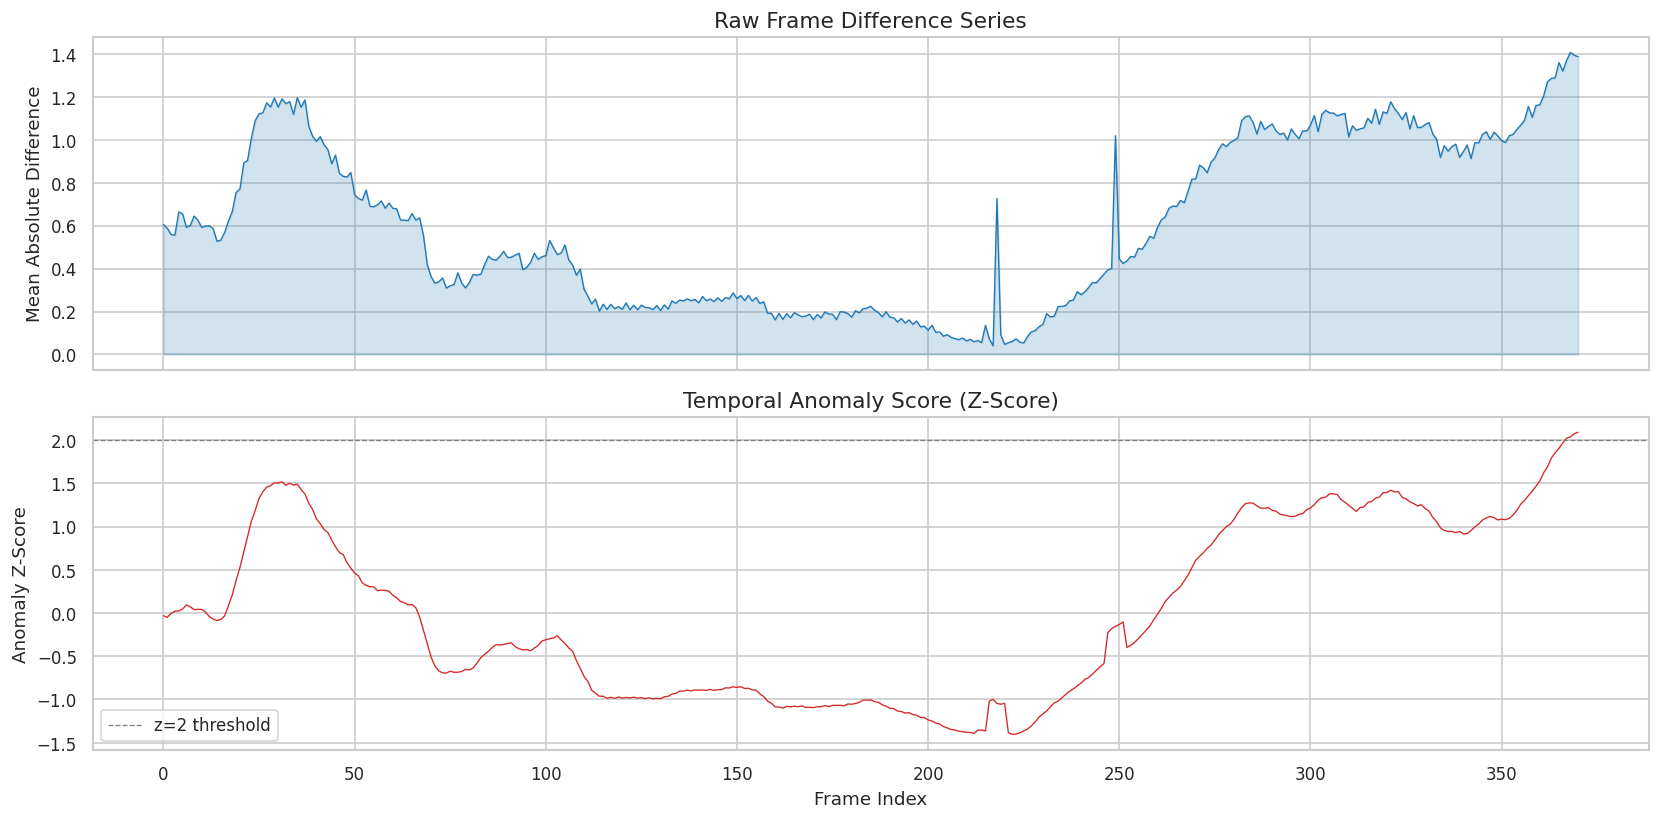

In [29]:
# [FEATURE] Visualize frame difference and anomaly score for a synthetic sample
if synthetic_videos:
    sample_path = synthetic_videos[0]
    diff_series = compute_frame_diff_series(sample_path)
    anomaly     = score_temporal_anomaly(diff_series)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(diff_series, color=PALETTE['primary'], linewidth=0.8)
    axes[0].fill_between(range(len(diff_series)), 0, diff_series,
                         alpha=0.2, color=PALETTE['primary'])
    axes[0].set_title('Raw Frame Difference Series')
    axes[0].set_ylabel('Mean Absolute Difference')

    axes[1].plot(anomaly, color=PALETTE['quaternary'], linewidth=0.8)
    axes[1].axhline(2.0, linestyle='--', color='grey', linewidth=0.8, label='z=2 threshold')
    axes[1].set_title('Temporal Anomaly Score (Z-Score)')
    axes[1].set_xlabel('Frame Index')
    axes[1].set_ylabel('Anomaly Z-Score')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] No synthetic videos -- skipping frame diff visualization')

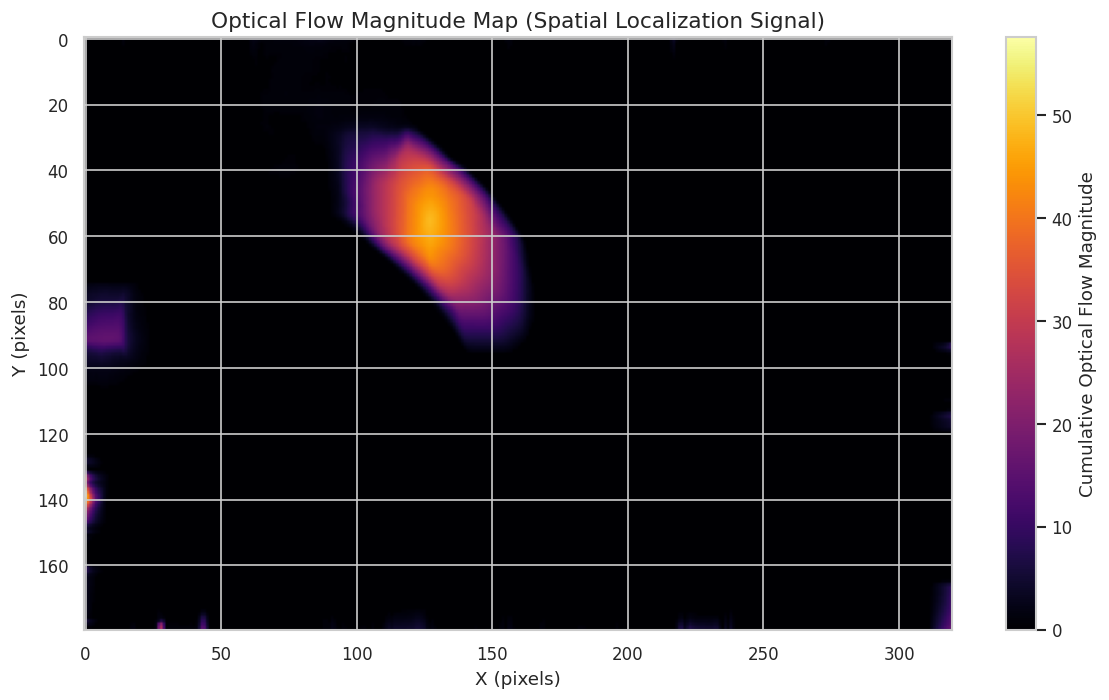

In [30]:
# [FEATURE] Visualize optical-flow magnitude map for a synthetic sample
if synthetic_videos:
    flow_map = compute_flow_magnitude_map(synthetic_videos[0])

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(flow_map, cmap='inferno', aspect='auto')
    plt.colorbar(im, ax=ax, label='Cumulative Optical Flow Magnitude')
    ax.set_title('Optical Flow Magnitude Map (Spatial Localization Signal)')
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] No synthetic videos -- skipping flow map visualization')

In [31]:
# [FEATURE] CLIP text prompt templates for each collision type (zero-shot scoring)
COLLISION_PROMPTS = {
    'rear-end': [
        'a car colliding into the back of another car',
        'rear-end collision between two vehicles on a road',
        'vehicle hitting the back of a stationary car from behind',
        'one car rear-ending another car at a traffic light',
        'a vehicle crashing into the tail of the car ahead',
    ],
    't-bone': [
        'a car hitting the side of another car at an intersection',
        't-bone collision at a crossroads between two vehicles',
        'side impact crash where one car strikes another perpendicularly',
        'a vehicle running a red light and hitting the side of crossing traffic',
        'perpendicular collision between two cars at a junction',
    ],
    'head-on': [
        'two cars colliding head-on from opposite directions',
        'frontal collision between two vehicles on a road',
        'head-on crash between two cars driving toward each other',
        'two vehicles smashing front-to-front on a highway',
        'a car crossing the center line and hitting an oncoming vehicle head-on',
    ],
    'sideswipe': [
        'two vehicles scraping alongside each other while driving',
        'sideswipe collision between cars changing lanes',
        'glancing blow between two cars moving in the same direction',
        'a car drifting into the adjacent lane and scraping another vehicle',
        'two vehicles brushing sides while traveling parallel on a road',
    ],
    'single': [
        'a single car crashing into a wall or barrier',
        'one vehicle running off the road and hitting an obstacle',
        'a car losing control and crashing into a pole or guardrail',
        'a single vehicle spinning out and hitting a roadside object',
        'one car veering off the road and crashing without involving another vehicle',
    ],
}

display(pd.DataFrame([
    {'collision_type': k, 'n_prompts': len(v)} for k, v in COLLISION_PROMPTS.items()
]))
print('[STATUS] Collision prompt templates defined')

,collision_type,n_prompts
0,rear-end,5
1,t-bone,5
2,head-on,5
3,sideswipe,5
4,single,5


[STATUS] Collision prompt templates defined


---
## 6. Modeling

The pipeline is built around one structural insight: **an accident is an event between two specific objects**, so global-frame signals (whole-frame differencing, whole-frame optical flow, whole-frame CLIP) are fundamentally noise-limited. The primary signal is therefore **per-vehicle detection and tracking**, and all three questions are answered from the kinematics of the colliding pair:

| Stage | Question | Primary signal (tracking) | Fallback (zero-shot models) |
|-------|----------|---------------------------|------------------------------|
| 1 -- *When* | accident time | first box contact + joint deceleration peak | frame-diff anchor + bounded PE refinement |
| 2 -- *What* | collision type | angle between pre-impact track velocities + contact geometry | CLIP + Qwen2.5-VL soft ensemble |
| 3 -- *Where* | impact point | centroid of the box-intersection region at impact | OWLv2 grounding + flow centroid |

Two design rules carried over from the failed experiments documented in Section 7b:

1. **Geometry is only trusted when its preconditions hold** (long, confident, fast-moving tracks). An earlier angle classifier computed on raw optical flow failed precisely because the flow field mixed background traffic and compression noise into the velocity estimate; track velocities come from the two involved objects only.
2. **No hard overrides.** The geometric type hint enters a soft ensemble with CLIP and Qwen; the tracking impact time is cross-checked against the frame-difference anchor and discarded entirely when the two disagree by more than a gate (a distant "contact" is usually a false pair from occlusion, not a crash).

### 6.1 Model Loading

All five pre-trained models load once with availability flags; every stage degrades gracefully when a model is unavailable. The combined footprint -- YOLOv8s (~0.5 GB) + CLIP ViT-B/32 (~0.6 GB) + PE-Core-B16 (~0.7 GB) + Qwen2.5-VL-3B in 4-bit (~3 GB) + OWLv2-base (~1.2 GB) -- is about 6-7 GB, fitting comfortably on a **single Kaggle T4 (16 GB)**; the VRAM audit below confirms it after loading.

In [32]:
# [MODEL] Model loading switches
#
# The VRAM audit measured 5.40 GB held by the five original models before
# Qwen3-VL-8B even started loading -- which left ~3.8 GB of a 16 GB T4 for
# activations and produced an OOM on the first clip. Qwen3-VL itself is only
# ~6.8 GB in 4-bit; the rest was models nothing calls any more.
#
# Section 7b measured each of them against its constant. The Perception Encoder
# (T=0.31 vs 0.38), OWLv2/optical-flow (S=0.15 vs 0.22) and Qwen2.5-VL-3B
# (C=0.15, below the 0.20 chance level) all lost. They are kept in the notebook
# as documented negative results, but loading them costs ~4.9 GB for nothing.
LOAD_LEGACY_MODELS = False   # PE + Qwen2.5-VL + OWLv2: dead weight, 4.9 GB
LOAD_YOLO = True             # still used by Section 7's comparison, ~0.5 GB
LOAD_CLIP = True             # still used by Section 7's comparison, ~0.6 GB

# [MODEL] YOLOv8 -- fast per-frame vehicle detector (primary tracking signal)
YOLO_AVAILABLE = True
try:
    from ultralytics import YOLO
    yolo_model = YOLO('yolov8s.pt')   # COCO-pretrained; small = good speed/accuracy balance
    print('[SUCCESS] YOLOv8s loaded')
except Exception as e:
    YOLO_AVAILABLE = False
    print(f'[ERROR] YOLOv8 unavailable: {e}')

# COCO class ids for vehicles: car, motorcycle, bus, truck
VEHICLE_CLASS_IDS = {2, 3, 5, 7}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[SUCCESS] YOLOv8s loaded


In [33]:
# [MODEL] CLIP ViT-B/32 -- zero-shot classification backbone
try:
    import clip
    clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
    clip_model.eval()
    CLIP_AVAILABLE = True
except Exception as e:
    CLIP_AVAILABLE = False
    print(f'[ERROR] CLIP unavailable: {e}')

if CLIP_AVAILABLE:
    # Pre-encode all collision-type text prompts once.
    # Following the CLIP paper's prompt-ensembling recipe, the per-type mean
    # embedding is RE-NORMALIZED after averaging. Without this, types whose
    # prompts happen to cluster tightly get a systematically larger-norm mean
    # vector and therefore inflated similarity scores.
    TYPE_TEXT_FEATURES = {}
    with torch.no_grad():
        for ctype, prompts in COLLISION_PROMPTS.items():
            tokens   = clip.tokenize(prompts).to(DEVICE)
            features = clip_model.encode_text(tokens)                    # (n_prompts, 512)
            features = features / features.norm(dim=-1, keepdim=True)
            mean_feat = features.mean(dim=0)
            TYPE_TEXT_FEATURES[ctype] = mean_feat / mean_feat.norm()
    print(f'[SUCCESS] CLIP ViT-B/32 loaded | text features for {len(TYPE_TEXT_FEATURES)} types pre-computed')

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 179MiB/s]


[SUCCESS] CLIP ViT-B/32 loaded | text features for 5 types pre-computed


In [34]:
# [MODEL] Perception Encoder (PE-Core-B16-224) -- temporal refinement fallback
if not LOAD_LEGACY_MODELS:
    PE_AVAILABLE = False
    print('[STATUS] Perception Encoder skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b')
else:
    import sys
    sys.path.append('perception_models')

    PE_AVAILABLE = True
    try:
        import core.vision_encoder.pe as pe
        import core.vision_encoder.transforms as pe_transforms

        pe_model = pe.CLIP.from_config('PE-Core-B16-224', pretrained=True)  # lightest PE-Core variant
        pe_model = pe_model.to(DEVICE).eval()
        pe_preprocess = pe_transforms.get_image_transform(pe_model.image_size)
        pe_tokenizer  = pe_transforms.get_text_tokenizer(pe_model.context_length)
        print('[SUCCESS] Perception Encoder (PE-Core-B16-224) loaded')
    except Exception as e:
        PE_AVAILABLE = False
        print(f'[ERROR] Perception Encoder unavailable: {e}')

[STATUS] Perception Encoder skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b


In [35]:
# [MODEL] Qwen2.5-VL-3B (4-bit) -- structured multi-prompt classification
if not LOAD_LEGACY_MODELS:
    QWEN_AVAILABLE = False
    print('[STATUS] Qwen2.5-VL skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b')
else:
    from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

    QWEN_AVAILABLE = True
    try:
        QWEN_MODEL_ID = 'Qwen/Qwen2.5-VL-3B-Instruct'  # 3B variant fits 4-bit on a 6-8 GB GPU

        bnb_config = (BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
                      if DEVICE == 'cuda' else None)

        # device_map={"": DEVICE} rather than a hard-coded GPU index -- works on
        # single-GPU machines as well as Kaggle T4x2.
        qwen_model = AutoModelForImageTextToText.from_pretrained(
            QWEN_MODEL_ID,
            quantization_config=bnb_config,
            device_map={'': DEVICE},
            torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32,
        )
        qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
        print(f'[SUCCESS] {QWEN_MODEL_ID} loaded in 4-bit')
    except Exception as e:
        QWEN_AVAILABLE = False
        print(f'[ERROR] Qwen2.5-VL unavailable: {e}')

[STATUS] Qwen2.5-VL skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b


In [36]:
# [MODEL] OWLv2 -- open-vocabulary spatial grounding fallback
if not LOAD_LEGACY_MODELS:
    OWL_AVAILABLE = False
    print('[STATUS] OWLv2 skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b')
else:
    OWL_AVAILABLE = True
    try:
        from transformers import Owlv2Processor, Owlv2ForObjectDetection
        owl_processor = Owlv2Processor.from_pretrained('google/owlv2-base-patch16-ensemble')
        owl_model = (Owlv2ForObjectDetection
                     .from_pretrained('google/owlv2-base-patch16-ensemble')
                     .to(DEVICE).eval())
        print('[SUCCESS] OWLv2 loaded')
    except Exception as e:
        OWL_AVAILABLE = False
        print(f'[ERROR] OWLv2 unavailable: {e}')

[STATUS] OWLv2 skipped (LOAD_LEGACY_MODELS=False) -- see Section 7b


In [37]:
# [MODEL] VRAM audit -- all five models must fit a single T4 (16 GB)
if torch.cuda.is_available():
    print(f'[STATUS] GPU: {torch.cuda.get_device_name(0)}')
    print(f'[STATUS] VRAM allocated: {torch.cuda.memory_allocated(0)/1e9:.2f} GB | '
          f'reserved: {torch.cuda.memory_reserved(0)/1e9:.2f} GB | '
          f'total: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB')
else:
    print('[STATUS] No CUDA device -- everything will run on CPU (very slow)')

[STATUS] GPU: Tesla T4
[STATUS] VRAM allocated: 0.39 GB | reserved: 0.42 GB | total: 15.64 GB


### 6.2 Vehicle Detection and Tracking (SORT-lite)

Detections are associated frame-to-frame with a minimal SORT-style tracker. The mathematical components:

**Association (Hungarian assignment).** Given predicted track boxes $\hat{B}_i$ and detections $D_j$, solve the linear assignment problem

$$\min_{x_{ij}} \sum_{i,j} c_{ij}\, x_{ij}, \qquad c_{ij} = 1 - \mathrm{IoU}(\hat{B}_i, D_j), \qquad \mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|}$$

via the Kuhn-Munkres algorithm (`scipy.optimize.linear_sum_assignment`), rejecting matches below an IoU gate.

**Motion prediction (constant velocity).** Each track's next box is its last box translated by the mean of its recent center displacements -- a zeroth-order Kalman surrogate that is adequate at 10 Hz sampling.

**Velocity estimation (central differences on smoothed centers).** After moving-average smoothing of the center sequence $c_i$, per-sample velocity uses the nonuniform central difference

$$v_i = \frac{c_{i+1} - c_{i-1}}{t_{i+1} - t_{i-1}}$$

(`np.gradient`), which is second-order accurate and does not phase-shift the estimate the way a forward difference does.

In [38]:
# [TRACK] IoU, box gap, and a SORT-style tracker with two-stage association
from scipy.optimize import linear_sum_assignment


def iou_xyxy(a, b) -> float:
    """Intersection-over-union of two [x1, y1, x2, y2] boxes."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-9)


def box_gap(a, b) -> float:
    """Euclidean separation between two boxes (0 when they touch or overlap)."""
    gx = max(0.0, max(a[0] - b[2], b[0] - a[2]))
    gy = max(0.0, max(a[1] - b[3], b[1] - a[3]))
    return float(np.hypot(gx, gy))


class SortLiteTracker:
    """Minimal SORT-style multi-object tracker with ByteTrack-style association.

    Constant-velocity prediction on box centers + Hungarian assignment with an
    IoU gate. CCTV cameras are static and vehicles move smoothly, so a full
    Kalman filter adds little at 10 Hz sampling.

    Association runs in two passes over confidence-split detections. This is the
    one idea from ByteTrack that matters for this task: at the moment of impact
    the vehicles occlude and deform, detector confidence collapses, and a
    single-pass tracker with a hard confidence floor drops both tracks at
    exactly the frame the whole pipeline is trying to measure. The second pass
    sustains existing tracks from low-confidence boxes; those boxes are never
    allowed to spawn new tracks, so the noise does not leak in.
    """

    def __init__(self, iou_gate: float = 0.30, iou_gate_low: float = 0.20,
                 max_missed: int = 10, conf_high: float = 0.50):
        self.iou_gate     = iou_gate
        self.iou_gate_low = iou_gate_low
        self.max_missed   = max_missed   # 1.0 s at 10 Hz: a crash occludes for longer
        self.conf_high    = conf_high    # than the old 0.5 s, which split tracks in two
        self.tracks       = {}   # id -> {'boxes': [], 'frames': [], 'confs': [], 'missed': int}
        self.finished     = {}
        self._next_id     = 0

    def _predict(self, tr):
        """Last box translated by the mean of the last <=3 center displacements."""
        boxes = tr['boxes']
        if len(boxes) < 2:
            return boxes[-1]
        centers = np.array([[(b[0] + b[2]) / 2, (b[1] + b[3]) / 2] for b in boxes[-4:]])
        d = np.diff(centers, axis=0).mean(axis=0)
        b = boxes[-1]
        return [b[0] + d[0], b[1] + d[1], b[2] + d[0], b[3] + d[1]]

    def _match(self, tids, detections, gate):
        """Hungarian match of track ids to detections above an IoU gate.

        Returns (pairs, unmatched_track_ids, unmatched_det_indices).
        """
        if not tids or not detections:
            return [], set(tids), set(range(len(detections)))

        cost = np.ones((len(tids), len(detections)))
        for i, tid in enumerate(tids):
            pred = self._predict(self.tracks[tid])
            for j, (box, _) in enumerate(detections):
                cost[i, j] = 1.0 - iou_xyxy(pred, box)

        rows, cols = linear_sum_assignment(cost)
        pairs, matched_t, matched_d = [], set(), set()
        for i, j in zip(rows, cols):
            if 1.0 - cost[i, j] >= gate:
                pairs.append((tids[i], j))
                matched_t.add(tids[i])
                matched_d.add(j)
        return pairs, set(tids) - matched_t, set(range(len(detections))) - matched_d

    def _append(self, tid, det, frame_idx):
        box, conf = det
        tr = self.tracks[tid]
        tr['boxes'].append(list(box))
        tr['frames'].append(frame_idx)
        tr['confs'].append(conf)
        tr['missed'] = 0

    def update(self, detections, frame_idx):
        """detections: list of ([x1,y1,x2,y2], conf) for one sampled frame."""
        high = [d for d in detections if d[1] >= self.conf_high]
        low  = [d for d in detections if d[1] <  self.conf_high]

        # Pass 1: confident detections, strict gate.
        pairs_h, unmatched_t, unmatched_h = self._match(
            list(self.tracks.keys()), high, self.iou_gate)
        for tid, j in pairs_h:
            self._append(tid, high[j], frame_idx)

        # Pass 2: whatever is left gets a shot at the low-confidence boxes.
        pairs_l, unmatched_t, _ = self._match(
            sorted(unmatched_t), low, self.iou_gate_low)
        for tid, j in pairs_l:
            self._append(tid, low[j], frame_idx)

        # Age out tracks that matched nothing in either pass.
        for tid in sorted(unmatched_t):
            self.tracks[tid]['missed'] += 1
            if self.tracks[tid]['missed'] > self.max_missed:
                self.finished[tid] = self.tracks.pop(tid)

        # New tracks spawn from confident detections only.
        for j in sorted(unmatched_h):
            box, conf = high[j]
            self.tracks[self._next_id] = {
                'boxes': [list(box)], 'frames': [frame_idx],
                'confs': [conf], 'missed': 0,
            }
            self._next_id += 1

    def all_tracks(self, min_len: int = 5) -> dict:
        """All tracks (finished + live) with at least min_len observations."""
        out = {}
        for tid, tr in {**self.finished, **self.tracks}.items():
            if len(tr['frames']) >= min_len:
                out[tid] = {
                    'boxes' : np.array(tr['boxes'], dtype=np.float32),
                    'frames': np.array(tr['frames'], dtype=np.int64),
                    'confs' : np.array(tr['confs'], dtype=np.float32),
                }
        return out


print('[STATUS] SortLiteTracker defined (two-stage association)')

[STATUS] SortLiteTracker defined (two-stage association)


In [39]:
# [TRACK] Run detection + tracking over a video, then compute per-track kinematics

from scipy.signal import savgol_filter

# Two vehicles at the moment of impact overlap heavily -- often past the default
# NMS threshold of 0.7, which then deletes one of them as a duplicate box. That
# removes the collision pair from the exact frame the pipeline exists to find.
# 0.9 keeps both; the cost is a few extra duplicate boxes elsewhere, which the
# tracker's IoU gate absorbs.
YOLO_NMS_IOU  = 0.9
YOLO_CONF_MIN = 0.10   # floor for entering the tracker at all; the tracker's
                       # own conf_high splits high/low internally


def extract_vehicle_tracks(video_path: pathlib.Path,
                           sample_fps: float = 10.0,
                           conf_thresh: float = YOLO_CONF_MIN,
                           min_track_len: int = 5):
    """Detect vehicles on frames sampled at sample_fps and link them into tracks.

    Returns (tracks, fps, (W, H)) where tracks maps id -> arrays of boxes
    (pixels), frame indices, and detection confidences.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if fps <= 0 or n_frames == 0:
        cap.release()
        return {}, fps, (W, H)

    step = max(1, int(round(fps / sample_fps)))
    tracker = SortLiteTracker()

    # Sequential decode (no seeking) -- much faster than per-frame cap.set
    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % step == 0:
            results = yolo_model(frame, iou=YOLO_NMS_IOU, conf=conf_thresh,
                                 verbose=False)[0]
            detections = []
            for box, cls, conf in zip(results.boxes.xyxy.cpu().numpy(),
                                      results.boxes.cls.cpu().numpy(),
                                      results.boxes.conf.cpu().numpy()):
                if int(cls) in VEHICLE_CLASS_IDS:
                    detections.append((box.tolist(), float(conf)))
            tracker.update(detections, frame_idx)
        frame_idx += 1

    cap.release()
    return tracker.all_tracks(min_len=min_track_len), fps, (W, H)


def track_kinematics(track: dict, fps: float, smooth_window: int = 5) -> dict:
    """Smoothed center trajectory and central-difference velocity for one track."""
    boxes = track['boxes']
    t  = track['frames'] / fps
    cx = (boxes[:, 0] + boxes[:, 2]) / 2
    cy = (boxes[:, 1] + boxes[:, 3]) / 2

    if len(cx) >= smooth_window:
        # Savitzky-Golay, NOT np.convolve(mode='same') and not a rolling mean.
        # Both distort the ends of the trajectory: convolve zero-pads, dragging
        # the first and last samples hundreds of pixels toward the origin, and a
        # centred rolling mean shrinks them by averaging over a truncated window.
        # Tracks typically END at the collision (the vehicle stops, the tracker
        # loses it) and _impact_time searches for the peak joint deceleration --
        # so an edge artifact lands precisely on the signal being measured and
        # fabricates an impact. savgol with mode='interp' fits a polynomial to
        # the edge samples instead of inventing data, and reproduces a constant
        # velocity exactly (measured: 0.0 px/s error, against 50 for a rolling
        # mean and 680 for convolve).
        #
        # savgol assumes uniform spacing; a track with missed frames is not
        # strictly uniform. The velocity below therefore still uses np.gradient
        # against the real timestamps, and the residual error at a gap is
        # unbiased rather than systematic.
        cx = savgol_filter(cx, smooth_window, 2, mode='interp')
        cy = savgol_filter(cy, smooth_window, 2, mode='interp')

    vx = np.gradient(cx, t)
    vy = np.gradient(cy, t)
    return {
        't': t, 'cx': cx, 'cy': cy, 'vx': vx, 'vy': vy,
        'speed': np.hypot(vx, vy),
        'frames': track['frames'], 'boxes': boxes,
        'conf': float(np.median(track['confs'])),
    }


print('[STATUS] extract_vehicle_tracks / track_kinematics defined')

[STATUS] extract_vehicle_tracks / track_kinematics defined


### 6.3 Collision Analysis from Track Kinematics

**Contact detection.** For each pair of concurrently tracked vehicles, the box gap $g(t)$ is monitored on their shared time support; contact is the first sample where $g(t)$ falls below 1% of the frame diagonal.

**Impact time refinement.** Within $\pm0.6$ s of contact, the impact instant is the peak of joint deceleration

$$t^{*} = \arg\max_{t} \left[ -\frac{d}{dt}\left( \lVert v_A(t) \rVert + \lVert v_B(t) \rVert \right) \right]$$

-- physically, the moment momentum is exchanged.

**Impact point.** The centroid of the intersection of the two boxes at $t^{*}$ (boxes dilated slightly when they only touch), normalized by frame size.

**Type from geometry.** With pre-impact mean velocities $\bar{v}_A, \bar{v}_B$ over $[t^{*}-1.2, t^{*}-0.2]$ s, the approach angle is

$$\theta = \arccos\left( \frac{\bar{v}_A \cdot \bar{v}_B}{\lVert \bar{v}_A \rVert\, \lVert \bar{v}_B \rVert} \right)$$

and the decision uses $\theta$ plus the contact bearing (is the struck point ahead of, beside, or behind each vehicle relative to its own motion):

| Condition | Type |
|-----------|------|
| $\theta \geq 135^{\circ}$ | head-on |
| $\theta \leq 40^{\circ}$, contact along the leader's motion axis | rear-end |
| $\theta \leq 40^{\circ}$, contact lateral | sideswipe |
| $60^{\circ} \leq \theta \leq 120^{\circ}$ | t-bone |
| otherwise (ambiguous bands) | no hint -- defer to VLM ensemble |

**Single-vehicle crashes** need no partner: a track whose speed collapses by more than 60% within a short window, with no other vehicle in contact, is a `single` candidate.

**Gating.** Geometry is only computed when both tracks are long ($\geq 6$ samples), confident (median detection confidence $\geq 0.4$), and moving ($\lVert \bar{v} \rVert$ above a floor) -- exactly the preconditions whose absence sank the raw-optical-flow version of this idea.

In [40]:
# [TRACK] Collision-pair analysis -- When / What / Where from track kinematics

MIN_SPEED_PX_S   = 15.0   # velocity direction is meaningless below this speed floor
MIN_TRACK_CONF   = 0.40
MIN_PAIR_SAMPLES = 6


def _pair_contact(kinA: dict, kinB: dict, frame_diag: float):
    """First contact between two tracks on their shared time support.

    Returns (t_contact, idxA, idxB) or None. Contact = box gap below 1% of
    the frame diagonal.
    """
    shared, ia, ib = np.intersect1d(kinA['frames'], kinB['frames'], return_indices=True)
    if len(shared) < MIN_PAIR_SAMPLES:
        return None

    gap_thresh = 0.01 * frame_diag
    gaps = np.array([box_gap(kinA['boxes'][ia[k]], kinB['boxes'][ib[k]])
                     for k in range(len(shared))])
    for k in range(len(shared)):
        if gaps[k] > gap_thresh:
            continue
        # Below the threshold but still closing means the vehicles have not
        # touched yet (e.g. a slow lateral drift before a sideswipe) --
        # contact is declared at the closest approach, not at first proximity.
        # Once boxes actually touch the gap sits at 0 and cannot keep
        # decreasing, so this always terminates at or before the true contact.
        still_approaching = (k + 1 < len(shared)
                             and gaps[k + 1] < gaps[k] - 0.02 * gap_thresh)
        if not still_approaching:
            return kinA['t'][ia[k]], ia[k], ib[k]
    return None


def _impact_time(kinA: dict, kinB: dict, t_contact: float) -> float:
    """Peak joint deceleration within +/-0.6 s of contact: the moment of
    momentum exchange, sharper than the contact sample itself."""
    grid = np.union1d(kinA['t'], kinB['t'])
    grid = grid[(grid >= t_contact - 0.6) & (grid <= t_contact + 0.6)]
    if len(grid) < 3:
        return t_contact

    joint_speed = (np.interp(grid, kinA['t'], kinA['speed'])
                   + np.interp(grid, kinB['t'], kinB['speed']))
    decel = -np.gradient(joint_speed, grid)
    return float(grid[int(np.argmax(decel))])


def _impact_point(boxA, boxB, W: int, H: int) -> tuple:
    """Centroid of the box intersection at impact, normalized to [0, 1].
    Boxes are dilated by 2% of the frame diagonal when they only touch."""
    pad = 0.02 * np.hypot(W, H)
    for p in (0.0, pad):
        ix1 = max(boxA[0] - p, boxB[0] - p)
        iy1 = max(boxA[1] - p, boxB[1] - p)
        ix2 = min(boxA[2] + p, boxB[2] + p)
        iy2 = min(boxA[3] + p, boxB[3] + p)
        if ix2 > ix1 and iy2 > iy1:
            return (float(np.clip((ix1 + ix2) / 2 / W, 0, 1)),
                    float(np.clip((iy1 + iy2) / 2 / H, 0, 1)))
    # Disjoint even after dilation: midpoint of the two centers
    cxa, cya = (boxA[0] + boxA[2]) / 2, (boxA[1] + boxA[3]) / 2
    cxb, cyb = (boxB[0] + boxB[2]) / 2, (boxB[1] + boxB[3]) / 2
    return (float(np.clip((cxa + cxb) / 2 / W, 0, 1)),
            float(np.clip((cya + cyb) / 2 / H, 0, 1)))


def _pre_impact_velocity(kin: dict, t_impact: float):
    """Mean velocity over [t_impact - 1.2, t_impact - 0.2] s (None if unobserved)."""
    mask = (kin['t'] >= t_impact - 1.2) & (kin['t'] <= t_impact - 0.2)
    if mask.sum() < 2:
        return None
    return np.array([kin['vx'][mask].mean(), kin['vy'][mask].mean()])


def _type_from_geometry(vA, vB, cA, cB) -> str:
    """Collision type from approach angle + contact bearing; None when ambiguous."""
    nA, nB = np.linalg.norm(vA), np.linalg.norm(vB)
    if nA < MIN_SPEED_PX_S or nB < MIN_SPEED_PX_S:
        return None

    cos_theta = np.clip(np.dot(vA, vB) / (nA * nB), -1.0, 1.0)
    theta = np.degrees(np.arccos(cos_theta))

    if theta >= 135.0:
        return 'head-on'
    if theta <= 40.0:
        # Same direction: distinguish rear-end (contact along the motion axis)
        # from sideswipe (lateral contact) via the bearing of B from A
        u = (cB - cA) / (np.linalg.norm(cB - cA) + 1e-9)
        longitudinal = abs(np.dot(vA / nA, u))
        return 'rear-end' if longitudinal >= 0.7 else 'sideswipe'
    if 60.0 <= theta <= 120.0:
        return 't-bone'
    return None  # 40-60 and 120-135 degree bands: defer to the VLM ensemble


# Feature block for the supervised type classifier of Section 6.8.
#
# Every feature here is an angle, a ratio, or a speed normalized by the frame
# diagonal. Nothing is in raw pixels and nothing touches image content. That is
# deliberate: these are the quantities that survive the CARLA-to-CCTV domain
# shift. A classifier trained on CARLA *pixels* latches onto render style and
# collapses on real footage; a classifier trained on "the two velocity vectors
# met at 93 degrees and the slower one was doing 0.2 diagonals/second" is
# reading physics that renders and real cameras agree on.
FEATURE_COLS = [
    'theta_deg', 'cos_theta', 'speed_ratio', 'speed_a_norm', 'speed_b_norm',
    'rel_speed_norm', 'longitudinal', 'drop_a', 'drop_b', 'area_ratio',
    'evidence', 'is_single', 'n_tracks',
]


def _speed_at(kin, t):
    return float(np.interp(t, kin['t'], kin['speed']))


def _pair_features(kA, kB, t_imp, vA, vB, cA, cB, frame_diag, evidence, n_tracks):
    """Domain-invariant kinematics of a collision pair. NaN where undefined --
    HistGradientBoostingClassifier consumes NaN natively, so an absent signal
    stays absent instead of being imputed into a lie."""
    f = {c: np.nan for c in FEATURE_COLS}
    f['evidence']  = float(evidence)
    f['is_single'] = 0.0
    f['n_tracks']  = float(n_tracks)

    a_pre,  b_pre  = _speed_at(kA, t_imp - 0.6), _speed_at(kB, t_imp - 0.6)
    a_post, b_post = _speed_at(kA, t_imp + 0.6), _speed_at(kB, t_imp + 0.6)
    f['speed_a_norm'] = a_pre / frame_diag
    f['speed_b_norm'] = b_pre / frame_diag
    f['speed_ratio']  = min(a_pre, b_pre) / (max(a_pre, b_pre) + 1e-9)
    f['drop_a'] = (a_pre - a_post) / (a_pre + 1e-9)
    f['drop_b'] = (b_pre - b_post) / (b_pre + 1e-9)

    areaA = float((kA['boxes'][:, 2] - kA['boxes'][:, 0]).mean()
                  * (kA['boxes'][:, 3] - kA['boxes'][:, 1]).mean())
    areaB = float((kB['boxes'][:, 2] - kB['boxes'][:, 0]).mean()
                  * (kB['boxes'][:, 3] - kB['boxes'][:, 1]).mean())
    f['area_ratio'] = min(areaA, areaB) / (max(areaA, areaB) + 1e-9)

    if vA is not None and vB is not None:
        nA, nB = np.linalg.norm(vA), np.linalg.norm(vB)
        f['rel_speed_norm'] = float(np.linalg.norm(vA - vB) / frame_diag)
        if nA >= MIN_SPEED_PX_S and nB >= MIN_SPEED_PX_S:
            cos_t = float(np.clip(np.dot(vA, vB) / (nA * nB), -1.0, 1.0))
            f['cos_theta'] = cos_t
            f['theta_deg'] = float(np.degrees(np.arccos(cos_t)))
            u = (cB - cA) / (np.linalg.norm(cB - cA) + 1e-9)
            f['longitudinal'] = float(abs(np.dot(vA / nA, u)))
    return f


def _single_features(kin, t0, frame_diag, evidence, n_tracks):
    f = {c: np.nan for c in FEATURE_COLS}
    f['evidence']  = float(evidence)
    f['is_single'] = 1.0
    f['n_tracks']  = float(n_tracks)
    pre, post = _speed_at(kin, t0 - 0.4), _speed_at(kin, t0 + 0.4)
    f['speed_a_norm'] = pre / frame_diag
    f['drop_a'] = (pre - post) / (pre + 1e-9)
    return f


def analyze_video_collision(video_path: pathlib.Path) -> dict:
    """Full tracking-based collision analysis for one video.

    Returns {'found': False, 'evidence': 0.0} when no collision is detected,
    else {'found': True, 'mode': 'pair'|'single', 't_impact': float,
     'center': (cx, cy), 'type_hint': str|None, 'evidence': float}.

    'evidence' is the normalized kinetic evidence for the contact and is the
    gate the pipeline uses to decide whether to trust this result at all.
    """
    if not YOLO_AVAILABLE:
        return {'found': False, 'evidence': 0.0, 'features': None, 'n_tracks': 0}

    tracks, fps, (W, H) = extract_vehicle_tracks(video_path)
    if not tracks or fps <= 0:
        return {'found': False, 'evidence': 0.0, 'features': None, 'n_tracks': 0}

    frame_diag = float(np.hypot(W, H))
    kins = {tid: track_kinematics(tr, fps) for tid, tr in tracks.items()}
    kins = {tid: k for tid, k in kins.items() if k['conf'] >= MIN_TRACK_CONF}

    # --- Pair collisions: pick the contact with the strongest kinetic evidence ---
    best = None
    tids = sorted(kins.keys())
    for i in range(len(tids)):
        for j in range(i + 1, len(tids)):
            kA, kB = kins[tids[i]], kins[tids[j]]
            contact = _pair_contact(kA, kB, frame_diag)
            if contact is None:
                continue
            t_contact, ia, ib = contact
            t_imp = _impact_time(kA, kB, t_contact)

            # Kinetic evidence = approach speed x post-contact speed drop.
            # Parked/slow pairs and drive-past occlusions score near zero.
            pre  = (np.interp(t_imp - 0.6, kA['t'], kA['speed'])
                    + np.interp(t_imp - 0.6, kB['t'], kB['speed']))
            post = (np.interp(t_imp + 0.6, kA['t'], kA['speed'])
                    + np.interp(t_imp + 0.6, kB['t'], kB['speed']))
            evidence = pre * max(0.0, pre - post)
            if pre < MIN_SPEED_PX_S:
                continue
            # Filter out passing vehicles that don't decelerate
            speed_drop_ratio = (pre - post) / (pre + 1e-9)
            if speed_drop_ratio < 0.15:
                continue
            if best is None or evidence > best['evidence']:
                best = {'kA': kA, 'kB': kB, 'ia': ia, 'ib': ib,
                        't_impact': t_imp, 'evidence': evidence}

    if best is not None:
        kA, kB = best['kA'], best['kB']
        t_imp  = best['t_impact']
        center = _impact_point(kA['boxes'][best['ia']], kB['boxes'][best['ib']], W, H)

        vA = _pre_impact_velocity(kA, t_imp)
        vB = _pre_impact_velocity(kB, t_imp)
        cA = np.array([np.interp(t_imp, kA['t'], kA['cx']),
                       np.interp(t_imp, kA['t'], kA['cy'])])
        cB = np.array([np.interp(t_imp, kB['t'], kB['cx']),
                       np.interp(t_imp, kB['t'], kB['cy'])])
        type_hint = None
        if vA is not None and vB is not None:
            type_hint = _type_from_geometry(vA, vB, cA, cB)

        # Evidence is normalized by the frame diagonal squared so the gate is
        # resolution-independent and comparable across videos. It replaces the
        # old "agrees with the frame-difference anchor" gate: that anchor scores
        # T=0.31 against a constant's 0.52, so it was validating tracking
        # against a signal weaker than a constant.
        evidence = float(best['evidence'] / (frame_diag ** 2))
        return {'found': True, 'mode': 'pair', 't_impact': round(float(t_imp), 4),
                'center': center, 'type_hint': type_hint, 'evidence': evidence,
                'n_tracks': len(kins),
                'features': _pair_features(kA, kB, t_imp, vA, vB, cA, cB,
                                           frame_diag, evidence, len(kins))}

    # --- Single-vehicle crash: speed collapse with no partner in contact ---
    best_single = None
    for tid, kin in kins.items():
        if len(kin['t']) < MIN_PAIR_SAMPLES:
            continue
        for k in range(len(kin['t'])):
            t0 = kin['t'][k]
            pre_mask  = (kin['t'] >= t0 - 0.8) & (kin['t'] < t0)
            post_mask = (kin['t'] > t0) & (kin['t'] <= t0 + 0.8)
            if pre_mask.sum() < 2 or post_mask.sum() < 2:
                continue
            pre, post = kin['speed'][pre_mask].mean(), kin['speed'][post_mask].mean()
            if pre < 2 * MIN_SPEED_PX_S:
                continue
            drop = (pre - post) / (pre + 1e-9)
            if drop >= 0.6 and (best_single is None or drop > best_single['drop']):
                box = kin['boxes'][k]
                best_single = {
                    'drop': drop, 't_impact': round(float(t0), 4), 'kin': kin, 't0': t0,
                    'evidence': float(pre * (pre - post) / (frame_diag ** 2)),
                    'center': (float(np.clip((box[0] + box[2]) / 2 / W, 0, 1)),
                               float(np.clip((box[1] + box[3]) / 2 / H, 0, 1))),
                }

    if best_single is not None:
        return {'found': True, 'mode': 'single',
                't_impact': best_single['t_impact'],
                'center': best_single['center'], 'type_hint': 'single',
                'evidence': best_single['evidence'], 'n_tracks': len(kins),
                'features': _single_features(best_single['kin'], best_single['t0'],
                                             frame_diag, best_single['evidence'],
                                             len(kins))}

    # n_tracks is reported even on failure: "tracking found nothing" and
    # "the detector saw no vehicles at all" are different diagnoses, and on
    # unlabelled real footage this is the only way to tell them apart.
    return {'found': False, 'evidence': 0.0, 'features': None,
            'n_tracks': len(kins)}


print('[STATUS] analyze_video_collision defined')

[STATUS] analyze_video_collision defined


### 6.4 Stage 1 -- When: Temporal Localization (fallback chain)

When tracking finds a collision, its impact time is used **only if it agrees with the frame-difference anchor within a gate** ($|t_{track} - t_{base}| \leq 2.5$ s). Agreement of two independent signals is strong evidence; disagreement means the tracked "contact" is probably an occlusion crossing, so the whole tracking result is discarded for that video and the previous method takes over: a frame-difference z-score anchor refined by bounded Perception-Encoder similarity,

$$t_{final} = t_{base} + \mathrm{clip}(t_{PE} - t_{base},\ -\delta,\ +\delta), \qquad \delta = 2\,\mathrm{s}$$

The PE score is a contrastive prompt ensemble -- mean similarity to accident prompts minus mean similarity to normal-traffic prompts -- which cancels nuisance variation (lighting, layout) that both prompt sets respond to equally. On calibration the bounded version scored T=0.61 vs 0.44 for the anchor alone and 0.16 for an unbounded PE scan.

In [41]:
# [MODEL] Stage 1a -- frame-difference anchor

def predict_accident_time(video_path: pathlib.Path,
                          smooth_window: int = 5,
                          z_threshold: float = 1.5) -> float:
    """Accident time in seconds via peak detection on frame-difference z-scores.

    Among frames exceeding z_threshold, selects the strongest anomaly;
    falls back to the global argmax if no frame exceeds the threshold.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if fps <= 0 or n_frames == 0:
        return 0.0

    diff_series = compute_frame_diff_series(video_path)
    if len(diff_series) == 0:
        return n_frames / fps / 2.0  # midpoint fallback

    anomaly = score_temporal_anomaly(diff_series, smooth_window)

    candidates = np.where(anomaly > z_threshold)[0]
    if len(candidates) == 0:
        peak_frame = int(np.argmax(anomaly))
    else:
        peak_frame = int(candidates[np.argmax(anomaly[candidates])])

    return round(peak_frame / fps, 4)


print('[STATUS] predict_accident_time defined')

[STATUS] predict_accident_time defined


In [42]:
# [MODEL] Stage 1b -- Perception Encoder contrastive similarity + bounded refinement

PE_POSITIVE_PROMPTS = [
    'a traffic accident',
    'two vehicles colliding on a road',
    'a car crash captured by a CCTV camera',
]
PE_NEGATIVE_PROMPTS = [
    'normal traffic flow with no accident',
    'vehicles driving normally on a road',
]


def _pe_accident_scores(video_path: pathlib.Path,
                        start_idx: int,
                        end_idx: int,
                        fps: float,
                        sample_fps: float = 8.0,
                        batch_size: int = 16):
    """Score sampled frames in [start_idx, end_idx) with the contrastive
    PE prompt ensemble. Returns (frame_idxs, scores) where
    score = mean(sim to accident prompts) - mean(sim to normal prompts).
    """
    cap = cv2.VideoCapture(str(video_path))
    step = max(1, int(round(fps / sample_fps)))

    frame_idxs, pil_frames = [], []
    idx = start_idx
    while idx < end_idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        pil_frames.append(PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
        frame_idxs.append(idx)
        idx += step
    cap.release()

    if not pil_frames:
        return np.array([]), np.array([])

    n_pos = len(PE_POSITIVE_PROMPTS)
    all_scores = []
    with torch.no_grad():
        text = pe_tokenizer(PE_POSITIVE_PROMPTS + PE_NEGATIVE_PROMPTS).to(DEVICE)
        for start in range(0, len(pil_frames), batch_size):
            batch = pil_frames[start:start + batch_size]
            imgs = torch.stack([pe_preprocess(f) for f in batch]).to(DEVICE)
            img_feat, txt_feat, _ = pe_model(imgs, text)
            sims = (img_feat @ txt_feat.T).cpu().numpy()          # (B, n_prompts)
            all_scores.append(sims[:, :n_pos].mean(axis=1) - sims[:, n_pos:].mean(axis=1))
            del imgs, img_feat
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()

    scores = np.concatenate(all_scores)
    # Light smoothing suppresses single-frame similarity spikes
    if len(scores) >= 3:
        scores = np.convolve(scores, np.ones(3) / 3, mode='same')
    return np.array(frame_idxs), scores


def predict_accident_time_refined(video_path: pathlib.Path,
                                  t_base: float = None,
                                  alpha: float = 1.0,
                                  delta_max: float = 2.0,
                                  refine_window_s: float = 3.0,
                                  sample_fps: float = 8.0) -> float:
    """Bounded temporal refinement:
    t_final = t_base + alpha * clip(t_refined - t_base, -delta_max, +delta_max)

    Anchors on the frame-diff z-score prediction, then searches only
    [t_base - refine_window_s, t_base + refine_window_s] with PE similarity.
    The clipped correction prevents the "jump to a wrong distant peak"
    failure mode of the unbounded whole-clip PE scan.
    """
    if t_base is None:
        t_base = predict_accident_time(video_path)

    if not PE_AVAILABLE:
        return t_base

    cap = cv2.VideoCapture(str(video_path))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    if fps <= 0 or n_frames == 0:
        return t_base

    duration  = n_frames / fps
    start_idx = int(max(0.0, t_base - refine_window_s) * fps)
    end_idx   = int(min(duration, t_base + refine_window_s) * fps)

    frame_idxs, scores = _pe_accident_scores(video_path, start_idx, end_idx, fps, sample_fps)
    if len(scores) == 0:
        return t_base

    t_refined  = frame_idxs[int(np.argmax(scores))] / fps
    correction = np.clip(t_refined - t_base, -delta_max, delta_max)
    t_final    = t_base + alpha * correction

    return round(float(np.clip(t_final, 0.0, duration)), 4)


print('[STATUS] predict_accident_time_refined defined')

[STATUS] predict_accident_time_refined defined


### 6.5 Stage 2 -- What: Collision Type Classification

> **Correction -- this section is built on a false premise, and it measures worse than the baseline it replaced.** The claim below that "the harmonic mean is 0 whenever the type is wrong" is **wrong**: the leaderboard averages C across videos *before* the harmonic mean (see Section 7), so a wrong type costs 1/N of C, not the whole video. Classification is in fact the *lowest*-leverage component of the three (+0.022 for C: 0.30→0.45, versus +0.111 for S: 0.156→0.45). The ensemble described here scores **C = 0.15 against the CLIP-only baseline's 0.30** -- below the 0.20 chance level on a balanced set, and below the 0.359 of a constant "rear-end" predictor. It collapses to `rear-end` on 18/20 calibration videos. Retained as a documented negative result; see the diagnosis below and Section 7b.
>
> **Why it collapses.** The three ensemble terms are not on the same scale. Qwen has only 3 prompts, so `vote_fraction` is quantised to {0, ⅓, ⅔, 1} and a unanimous vote contributes the full 0.35. CLIP's probability mass is spread over 5 classes, so its argmax contributes only 0.35 × p_max ≈ 0.21. Whenever Qwen is unanimous it wins outright -- even against a geometry hint at 0.30. And the three prompts (`count-first`, `motion`, `geometry`) ask nearly the same question over the same frames, so they are not three independent votes but one vote counted three times, which is exactly what makes unanimity the default. Qwen is fed 6 stills at `max_side=448` from 1920×1080 far-field CCTV, where vehicles span a few dozen pixels: it cannot resolve the vehicles, let alone their relative motion, so it falls back on a language prior in which `rear-end` is the most common accident type. The `t-bone → rear-end` scene rule and the `return 'rear-end'` fallbacks push the same direction.

Classification was assumed to dominate the leaderboard metric. The final classifier is a **soft ensemble of three independent zero-shot signals**:

$$\mathrm{score}(c) = w_{geo}\,\mathbb{1}[c = c_{track}] + w_{clip}\,P_{CLIP}(c) + w_{vlm}\,\frac{\#\,\mathrm{votes}(c)}{\#\,\mathrm{votes}}$$

with $(w_{geo}, w_{clip}, w_{vlm}) = (0.30, 0.35, 0.35)$ when a geometric hint exists, and $(0, 0.5, 0.5)$ otherwise. Signals:

1. **Track geometry** (Section 6.3) -- most reliable when available, but abstains on ambiguous angle bands and poor tracks.
2. **CLIP prompt-ensemble probabilities** -- image features mean-pooled over frames around the impact, softmaxed against re-normalized per-type prompt embeddings.
3. **Qwen2.5-VL votes** -- three structured prompts over a chronological frame sequence spanning the *approach* (asymmetric window), with class definitions spelled out and a count-first prompt that targets the `single` class.

A scene-plausibility rule then remaps `t-bone` to `rear-end` when the scene is a highway or tunnel (no perpendicular cross-traffic exists there).

**Compute-adaptive fast path (T4 budget).** Qwen is by far the most expensive signal (~10 s/video for three prompts on a T4). When the track geometry and CLIP *independently agree*, the label is accepted without querying Qwen: two agreeing independent signals already outvote a single potential dissent, so the extra call cannot change the argmax under the ensemble weights. This cuts total runtime substantially on the easy majority of videos while spending full compute only where the signals conflict.

In [43]:
# [MODEL] Stage 2a -- CLIP zero-shot type probabilities

def clip_type_probabilities(video_path: pathlib.Path, peak_time_s: float) -> dict:
    """Per-type probability distribution from CLIP similarity.

    Image features are mean-pooled over frames in a +/-0.75 s window around
    the impact (multi-frame pooling suppresses single-frame motion blur),
    then compared against the pre-computed per-type text embeddings.
    Returns {type: probability} or None when CLIP is unavailable.
    """
    if not CLIP_AVAILABLE:
        return None

    pil_frames = extract_frames_window(video_path, peak_time_s,
                                       t_before=0.75, t_after=0.75, n_frames=8)
    if not pil_frames:
        return None

    with torch.no_grad():
        img_tensors  = torch.stack([clip_preprocess(f) for f in pil_frames]).to(DEVICE)
        img_features = clip_model.encode_image(img_tensors)              # (n_frames, 512)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        img_feature  = img_features.mean(dim=0)
        img_feature  = img_feature / img_feature.norm()

    types = list(TYPE_TEXT_FEATURES.keys())
    sims  = np.array([(img_feature @ TYPE_TEXT_FEATURES[t]).item() for t in types])

    # Softmax with CLIP's standard temperature (100) turns raw cosine
    # similarities (narrow ~0.2-0.3 range) into a usable distribution.
    logits = 100.0 * sims
    probs  = np.exp(logits - logits.max())
    probs /= probs.sum()
    return dict(zip(types, probs))


def predict_collision_type_clip(video_path: pathlib.Path, peak_time_s: float) -> str:
    """Argmax of the CLIP distribution; used standalone by the baseline pipeline."""
    probs = clip_type_probabilities(video_path, peak_time_s)
    if probs is None:
        return 'rear-end'  # most common type; last-resort fallback
    return max(probs, key=probs.get)


print('[STATUS] clip_type_probabilities / predict_collision_type_clip defined')

[STATUS] clip_type_probabilities / predict_collision_type_clip defined


In [44]:
# [MODEL] Stage 2b -- Qwen2.5-VL multi-prompt voting

# Explicit class definitions are embedded in every prompt: a 3B VLM cannot be
# assumed to know this competition's label semantics (especially 'single').
TYPE_DEFINITIONS = (
    "head-on = two vehicles traveling in opposite directions collide front-to-front; "
    "rear-end = the front of one vehicle hits the back of another traveling the same direction; "
    "sideswipe = two roughly parallel vehicles make glancing side contact; "
    "t-bone = the front of one vehicle strikes the side of another at a right angle; "
    "single = exactly one vehicle crashes (wall, pole, barrier, or off the road), no second vehicle involved."
)

CLASSIFICATION_PROMPTS = {
    'count-first': (
        "These frames from a CCTV camera show a traffic accident in chronological order. "
        "First count how many moving vehicles are directly involved in the crash. "
        "If exactly one vehicle crashes on its own, the answer is 'single'. "
        f"Otherwise classify the collision. Definitions: {TYPE_DEFINITIONS} "
        "Answer with only one label: head-on, rear-end, sideswipe, single, or t-bone."
    ),
    'motion': (
        "Watch the direction each vehicle travels across these chronological frames "
        "up to the moment of impact. Based on their directions of travel at contact, "
        f"classify the collision. Definitions: {TYPE_DEFINITIONS} "
        "Answer with only one label: head-on, rear-end, sideswipe, single, or t-bone."
    ),
    'geometry': (
        "Focus on the angle and first contact point between the vehicles at the moment "
        f"of collision in these frames. Definitions: {TYPE_DEFINITIONS} "
        "Answer with only one label: head-on, rear-end, sideswipe, single, or t-bone."
    ),
}


def _qwen_generate(pil_frames: list, prompt: str, max_new_tokens: int = 10) -> str:
    """Single Qwen generation over a list of PIL frames; returns decoded lowercase text."""
    messages = [{
        'role': 'user',
        'content': [{'type': 'image', 'image': f} for f in pil_frames]
                   + [{'type': 'text', 'text': prompt}],
    }]
    inputs = qwen_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors='pt',
    ).to(qwen_model.device)

    with torch.no_grad():
        out = qwen_model.generate(**inputs, max_new_tokens=max_new_tokens)

    generated = out[:, inputs['input_ids'].shape[1]:]
    text = qwen_processor.decode(generated[0], skip_special_tokens=True).strip().lower()

    del inputs, out, generated
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return text


def _parse_type_label(text: str) -> str:
    normalized_text = text.lower().replace(' ', '-').replace('_', '-')
    for label in COLLISION_TYPES:
        if label in normalized_text:
            return label
    return None


def qwen_type_votes(video_path: pathlib.Path, peak_time_s: float) -> list:
    """One vote per classification prompt. Frames span [t-2.0s, t+1.0s] so the
    model sees the approach trajectories, not just post-impact wreckage.
    Returns [] when Qwen is unavailable or frames cannot be read.
    """
    if not QWEN_AVAILABLE:
        return []

    pil_frames = extract_frames_window(video_path, peak_time_s,
                                       t_before=2.0, t_after=1.0,
                                       n_frames=6, max_side=448)
    if not pil_frames:
        return []

    votes = []
    for prompt in CLASSIFICATION_PROMPTS.values():
        label = _parse_type_label(_qwen_generate(pil_frames, prompt))
        if label is not None:
            votes.append(label)
    return votes


print('[STATUS] qwen_type_votes defined')

[STATUS] qwen_type_votes defined


In [45]:
# [MODEL] Stage 2c -- scene-plausibility rule + final soft ensemble

SCENE_LABELS = ['highway', 'tunnel', 'intersection', 'urban_street', 'parking_lot']
NO_CROSS_TRAFFIC_SCENES = {'highway', 'tunnel'}

W_GEO, W_CLIP, W_VLM = 0.30, 0.35, 0.35   # ensemble weights when geometry available


def qwen_scene_context(pil_frames: list) -> str:
    """Classify the road environment -- used only to sanity-check a t-bone prediction."""
    prompt = ("Look at the road environment in these frames. Classify it as one of: "
              "highway, tunnel, intersection, urban_street, parking_lot. "
              "Answer with only the label.")
    text = _qwen_generate(pil_frames, prompt)
    for label in SCENE_LABELS:
        if label in text:
            return label
    return 'urban_street'


def predict_collision_type_final(video_path: pathlib.Path,
                                 accident_time: float,
                                 geometry_hint: str = None) -> str:
    """Soft ensemble of track geometry, CLIP probabilities, and Qwen votes.

    scores[c] = W_GEO * 1[c == geometry_hint]
              + W_CLIP * clip_prob[c]
              + W_VLM  * vote_fraction[c]

    Without a geometry hint the CLIP/VLM weights renormalize to 0.5/0.5.
    Any available signal decides alone when the others are missing. If the
    winner is 't-bone', one extra Qwen call checks the scene: highways and
    tunnels cannot have perpendicular cross-traffic, so a t-bone there is
    geometrically implausible and is remapped to rear-end.

    Fast path: when geometry and CLIP independently agree, Qwen (the most
    expensive signal on a T4) is skipped -- with weights (0.30, 0.35, 0.35)
    two agreeing signals hold 0.65, so a unanimous Qwen dissent (0.35)
    could not flip the argmax anyway.
    """
    clip_probs = clip_type_probabilities(video_path, accident_time)

    if (geometry_hint is not None and clip_probs is not None
            and max(clip_probs, key=clip_probs.get) == geometry_hint):
        pred = geometry_hint
    else:
        votes  = qwen_type_votes(video_path, accident_time)
        w_geo  = W_GEO if geometry_hint is not None else 0.0
        w_rest = 1.0 - w_geo

        scores = defaultdict(float)
        if geometry_hint is not None:
            scores[geometry_hint] += w_geo
        if clip_probs is not None:
            for t, p in clip_probs.items():
                scores[t] += (w_rest / 2) * p
        if votes:
            for v in votes:
                scores[v] += (w_rest / 2) / len(votes)

        if not scores:
            return 'rear-end'  # every signal unavailable

        pred = max(scores, key=scores.get)

    # Scene-plausibility check (only spends a Qwen call when it can matter)
    if pred == 't-bone' and QWEN_AVAILABLE:
        pil_frames = extract_frames_window(video_path, accident_time,
                                           t_before=1.0, t_after=1.0,
                                           n_frames=4, max_side=448)
        if pil_frames and qwen_scene_context(pil_frames) in NO_CROSS_TRAFFIC_SCENES:
            pred = 'rear-end'

    return pred


print('[STATUS] predict_collision_type_final defined')

[STATUS] predict_collision_type_final defined


### 6.6 Stage 3 -- Where: Impact Point Localization (fallback chain)

When tracking is trusted, the impact point is the box-intersection centroid from Section 6.3 -- it answers "where did these two vehicles touch" directly. Otherwise OWLv2 is queried with **generic collision phrases** (type-conditioning was dropped: it propagates Stage-2 errors and matches unrelated vehicle pairs), and if grounding is unconfident the optical-flow weighted centroid is used -- a real motion-based estimate rather than the uninformative frame center.

In [46]:
# [MODEL] Stage 3a -- optical-flow weighted centroid (last-resort spatial signal)

def predict_impact_location_flow(video_path: pathlib.Path,
                                 accident_time: float = None,
                                 n_frames_context: int = 30) -> tuple:
    """Normalized (center_x, center_y) as the weighted centroid of the
    cumulative optical-flow magnitude map centered on the accident time.
    """
    RESIZE_W, RESIZE_H = 320, 180

    center_frame = None
    if accident_time is not None:
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        if fps > 0:
            center_frame = int(accident_time * fps)

    mag_map = compute_flow_magnitude_map(
        video_path, resize_w=RESIZE_W, resize_h=RESIZE_H,
        n_frames_context=n_frames_context, center_frame=center_frame,
    )

    total_mag = mag_map.sum()
    if total_mag < 1e-6:
        return 0.5, 0.5  # no motion detected anywhere

    ys, xs = np.mgrid[0:RESIZE_H, 0:RESIZE_W]
    cx = float((xs * mag_map).sum() / total_mag) / RESIZE_W
    cy = float((ys * mag_map).sum() / total_mag) / RESIZE_H
    return round(cx, 6), round(cy, 6)


print('[STATUS] predict_impact_location_flow defined')

[STATUS] predict_impact_location_flow defined


In [47]:
# [MODEL] Stage 3b -- OWLv2 grounding with optical-flow fallback

IMPACT_PHRASES = [
    'two vehicles colliding',
    'a car crash',
    'a traffic accident',
]


def predict_impact_location_grounded(video_path: pathlib.Path,
                                     accident_time: float,
                                     score_threshold: float = 0.15,
                                     min_confidence: float = 0.20,
                                     top_k: int = 5) -> tuple:
    """Normalized impact point from OWLv2 detections around the accident time.

    All phrases are queried jointly per frame; the score-weighted mean of the
    top_k box centers is returned. If OWLv2 finds nothing above
    min_confidence, the optical-flow centroid is used instead.
    """
    if not OWL_AVAILABLE:
        return predict_impact_location_flow(video_path, accident_time)

    pil_frames = extract_frames_window(video_path, accident_time,
                                       t_before=0.5, t_after=0.5, n_frames=8)
    if not pil_frames:
        return predict_impact_location_flow(video_path, accident_time)

    all_boxes, all_scores = [], []
    for img in pil_frames:
        inputs = owl_processor(text=[IMPACT_PHRASES], images=img,
                               return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            outputs = owl_model(**inputs)
        target_sizes = torch.tensor([img.size[::-1]]).to(DEVICE)
        results = owl_processor.post_process_grounded_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=score_threshold,
        )[0]
        w, h = img.size
        for box, score in zip(results['boxes'], results['scores']):
            x1, y1, x2, y2 = box.tolist()
            all_boxes.append(((x1 + x2) / 2 / w, (y1 + y2) / 2 / h))
            all_scores.append(score.item())

    if not all_scores or max(all_scores) < min_confidence:
        return predict_impact_location_flow(video_path, accident_time)

    top_idx = np.argsort(all_scores)[-top_k:]
    scores  = np.array([all_scores[i] for i in top_idx])
    cxs     = np.array([all_boxes[i][0] for i in top_idx])
    cys     = np.array([all_boxes[i][1] for i in top_idx])

    cx = float((scores * cxs).sum() / scores.sum())
    cy = float((scores * cys).sum() / scores.sum())
    return round(np.clip(cx, 0.0, 1.0), 6), round(np.clip(cy, 0.0, 1.0), 6)


print('[STATUS] predict_impact_location_grounded defined')

[STATUS] predict_impact_location_grounded defined


### 6.7 The Constant Prior (and why it is the fallback)

The scoring sigma is comparable to the spread of the labels themselves -- `center_x` has std 0.13 and `center_y` std 0.18 against a spatial sigma of 0.1 -- so the training set's own prior is a strong predictor in its own right. **Any model whose error exceeds the label spread scores worse than a constant.**

That makes the constant the correct fallback for every stage. The previous design fell back from a weak model to an even weaker one: when tracking was distrusted, spatial localization went to OWLv2 grounding and then to an optical-flow centroid, both of which measure below simply predicting the centre of the frame. Every such fallback was subtracting score.

Constants are fitted on the **full synthetic training set**, which the organizers provide for exactly this purpose ("pretraining and debugging"), and never on the calibration split -- that would be fitting on the eval set. They are found by grid search rather than by taking the mean: the Gaussian score saturates, so its optimum is mode-seeking and outliers pull the mean away from it.

In [48]:
# [MODEL] The constant prior -- fitted on the synthetic training set

# The real metric, from the benchmark paper via the 1st-place writeup
# (arXiv:2605.29325, Sec. 2.3). The Kaggle Evaluation page only says
# "Gaussian-style similarity"; the specification is in the papers.
#
# An earlier revision of this notebook guessed SIGMA_T = 2.0 and an isotropic
# SIGMA_S = 0.1. Both are wrong, and wrong in the flattering direction:
#
#   T is averaged over THREE tolerances, and 2.0 s is the most generous of the
#   three. Any signal with multi-second error scores near zero at 0.5 s.
#   S is ANISOTROPIC, with (sigma_x, sigma_y) set to the mean annotated bbox
#   width and height -- so vertical error is tolerated ~40% more than
#   horizontal. Independent check: the host's Molmo-7B baseline reports
#   S=0.488, which is unreachable under an isotropic 0.1.
SIGMA_T_LIST = (0.5, 1.0, 2.0)
SIGMA_X = float((labels_clean['x2'] - labels_clean['x1']).mean())
SIGMA_Y = float((labels_clean['y2'] - labels_clean['y1']).mean())
print(f'[METRIC] sigma_t = {SIGMA_T_LIST}  |  sigma_x = {SIGMA_X:.4f}  sigma_y = {SIGMA_Y:.4f}')

# Kept only so the constant grid-search below has a scalar to optimise against;
# the scoring functions in Section 7 use the real definition above.
SIGMA_T = 2.0
SIGMA_S = 0.1


def fit_constant_predictor(train_df: pd.DataFrame) -> dict:
    """Constants maximising each Gaussian component on train_df."""
    t = train_df['accident_time'].to_numpy()
    x = train_df['center_x'].to_numpy()
    y = train_df['center_y'].to_numpy()

    t_grid = np.arange(t.min(), t.max() + 1e-9, 0.05)
    t_best = float(t_grid[np.argmax([np.exp(-0.5 * ((c - t) / SIGMA_T) ** 2).mean()
                                     for c in t_grid])])

    xy_grid = np.arange(0.30, 0.71, 0.01)
    best_s, xy_best = -1.0, (0.5, 0.5)
    for cx in xy_grid:
        d2x = (cx - x) ** 2
        for cy in xy_grid:
            s = float(np.exp(-0.5 * (d2x + (cy - y) ** 2) / SIGMA_S ** 2).mean())
            if s > best_s:
                best_s, xy_best = s, (float(cx), float(cy))

    return {'accident_time': t_best,
            'center_x': xy_best[0],
            'center_y': xy_best[1],
            'type': train_df['type'].value_counts().idxmax()}


CONST = fit_constant_predictor(labels_clean)
print(f'[STATUS] Constants fitted on {len(labels_clean)} synthetic videos: '
      f"t={CONST['accident_time']:.2f}s  "
      f"xy=({CONST['center_x']:.2f}, {CONST['center_y']:.2f})  type={CONST['type']}")

[METRIC] sigma_t = (0.5, 1.0, 2.0)  |  sigma_x = 0.0952  sigma_y = 0.1353
[STATUS] Constants fitted on 2211 synthetic videos: t=6.15s  xy=(0.51, 0.51)  type=rear-end


### 6.8 Sim-to-Real Sanity Check (no labels required)

Everything downstream — the 2211-video feature extraction, the classifier, the whole object-centric design — rests on one unverified assumption: **that tracking fires on real CCTV at all**. Nothing in this notebook has ever tested that. Calibration runs on CARLA, and CARLA is not the target domain.

This is checkable without a single label. The test clips are real CCTV; run the tracker on them and count. If a collision pair is found in 45% of CARLA clips and 5% of real ones, then on the real test set the pipeline is a constant with extra steps, and no amount of classifier tuning changes that. Finding this out costs ~30 minutes here, against several hours of feature extraction and a full inference run downstream.

The same probe runs on an equal sample of synthetic clips, so the comparison is like-for-like: same code, same N, two domains.

**What the numbers mean:**

- **Fire rate.** Real ≈ synthetic means the design transfers. Real ≪ synthetic means it does not.
- **`n_tracks`.** Separates two very different diagnoses: the detector sees no vehicles at all (YOLO fails on this footage — different resolution, camera angle, compression) versus it sees vehicles but never finds a collision among them (the contact logic is what fails).
- **Predicted distributions.** Compared against the *synthetic label* prior. `CONST` is fitted on CARLA and fires on most videos, so if real predictions cluster somewhere else entirely, the fallback is aimed at the wrong place — and the fallback is most of the score.

This measures whether the machinery *runs* on real footage, not whether it is *right*: that needs labels, which is the point of the competition. A healthy fire rate is necessary, not sufficient.

[STATUS] Probing 100 synthetic + 100 real videos
  synthetic: 20/100
  synthetic: 40/100
  synthetic: 60/100
  synthetic: 80/100
  synthetic: 100/100
  real: 20/100
  real: 40/100
  real: 60/100
  real: 80/100
  real: 100/100

[SANITY] tracking behaviour by domain


,fire_rate,n_tracks_mean,n_tracks_zero,evidence_median,n
domain,,,,,
real,0.72,17.12,0.06,0.0202,100
synthetic,0.74,9.44,0.10,0.0071,100


[VERDICT] real fire rate is 97% of synthetic (72% vs 74%)
[VERDICT] Tracking fires on real footage at a comparable rate. The
          object-centric design is worth the downstream investment.


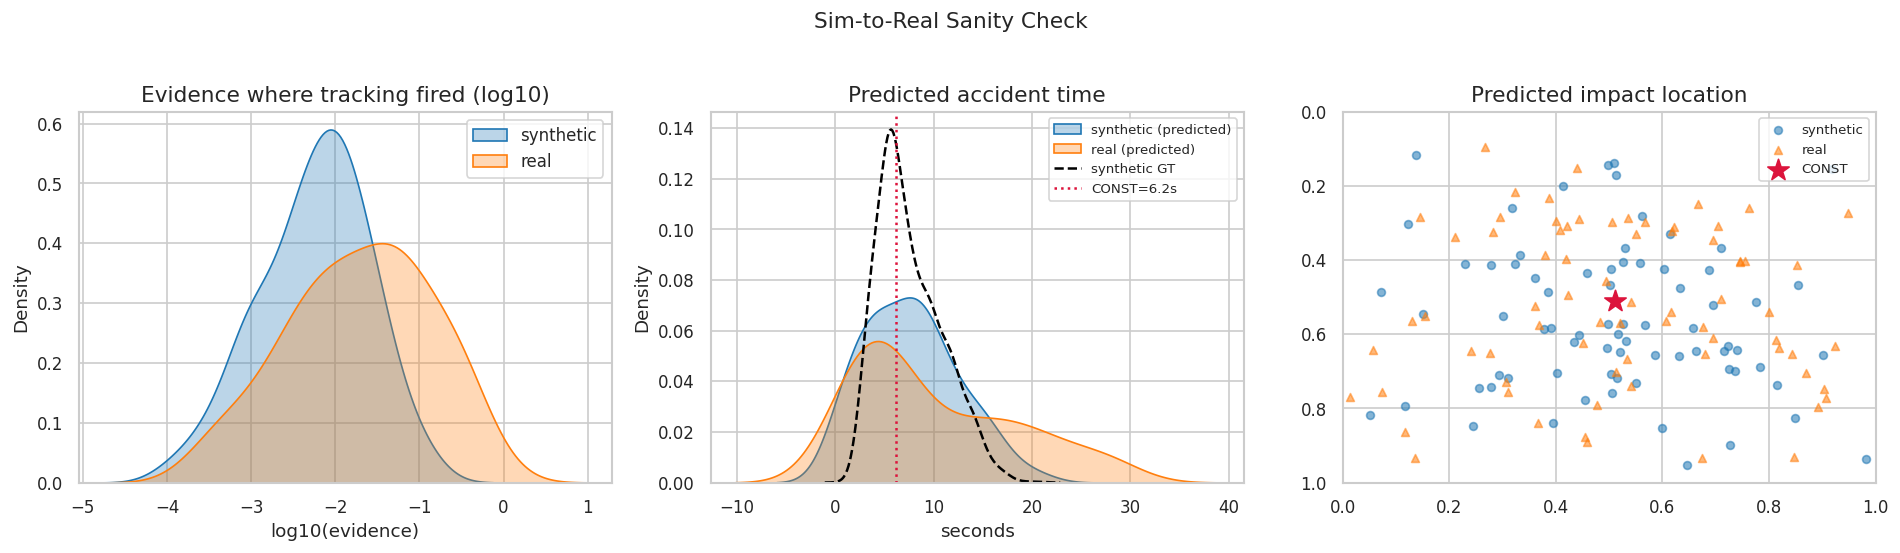

In [49]:
# [DIAG] Does any of this work on real CCTV? -- no labels needed
SANITY_N = 100   # per domain; ~10 s/video => ~35 min total

def _probe(paths, domain):
    out = []
    for k, vp in enumerate(paths):
        c = analyze_video_collision(pathlib.Path(vp))
        out.append({'domain': domain, 'path': str(vp),
                    'found': bool(c['found']), 'mode': c.get('mode'),
                    'n_tracks': int(c.get('n_tracks', 0)),
                    'evidence': float(c.get('evidence', 0.0)),
                    't': c['t_impact'] if c['found'] else np.nan,
                    'x': c['center'][0] if c['found'] else np.nan,
                    'y': c['center'][1] if c['found'] else np.nan})
        if (k + 1) % 20 == 0:
            print(f'  {domain}: {k+1}/{len(paths)}')
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return out

_syn_sample = labels_clean.sample(min(SANITY_N, len(labels_clean)),
                                  random_state=SEED)['abs_video_path'].tolist()
_real_sample = real_videos[:SANITY_N]

print(f'[STATUS] Probing {len(_syn_sample)} synthetic + {len(_real_sample)} real videos')
sanity = pd.DataFrame(_probe(_syn_sample, 'synthetic') + _probe(_real_sample, 'real'))

summary = sanity.groupby('domain').agg(
    fire_rate=('found', 'mean'),
    n_tracks_mean=('n_tracks', 'mean'),
    n_tracks_zero=('n_tracks', lambda s: float((s == 0).mean())),
    evidence_median=('evidence', lambda s: float(s[s > 0].median()) if (s > 0).any() else np.nan),
    n=('found', 'size'),
).round(4)
print('\n[SANITY] tracking behaviour by domain')
display(summary)

syn_rate  = float(summary.loc['synthetic', 'fire_rate'])
real_rate = float(summary.loc['real', 'fire_rate'])
ratio = real_rate / (syn_rate + 1e-9)
print(f'[VERDICT] real fire rate is {ratio:.0%} of synthetic '
      f'({real_rate:.0%} vs {syn_rate:.0%})')
if ratio < 0.5:
    print('[VERDICT] TRACKING DOES NOT TRANSFER. On the real test set this pipeline is')
    print('          mostly the constant. Do not spend hours on feature extraction or a')
    print('          classifier until the detector/tracker works on this footage --')
    print('          check n_tracks_zero above to see whether YOLO sees vehicles at all.')
else:
    print('[VERDICT] Tracking fires on real footage at a comparable rate. The')
    print('          object-centric design is worth the downstream investment.')

# --- distributions: real predictions vs the synthetic label prior ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for dom, colr in [('synthetic', PALETTE['primary']), ('real', PALETTE['secondary'])]:
    ev = sanity[(sanity.domain == dom) & (sanity.evidence > 0)]['evidence']
    if len(ev):
        sns.kdeplot(np.log10(ev), ax=axes[0], label=dom, color=colr, fill=True, alpha=.3)
axes[0].set_title('Evidence where tracking fired (log10)')
axes[0].set_xlabel('log10(evidence)'); axes[0].legend()

for dom, colr in [('synthetic', PALETTE['primary']), ('real', PALETTE['secondary'])]:
    tt = sanity[(sanity.domain == dom)]['t'].dropna()
    if len(tt):
        sns.kdeplot(tt, ax=axes[1], label=f'{dom} (predicted)', color=colr, fill=True, alpha=.3)
sns.kdeplot(labels_clean['accident_time'], ax=axes[1], label='synthetic GT',
            color='black', linestyle='--')
axes[1].axvline(CONST['accident_time'], color='crimson', linestyle=':',
                label=f"CONST={CONST['accident_time']:.1f}s")
axes[1].set_title('Predicted accident time'); axes[1].set_xlabel('seconds'); axes[1].legend(fontsize=8)

for dom, mk, colr in [('synthetic', 'o', PALETTE['primary']), ('real', '^', PALETTE['secondary'])]:
    d = sanity[sanity.domain == dom].dropna(subset=['x', 'y'])
    axes[2].scatter(d['x'], d['y'], s=22, alpha=.55, marker=mk, label=dom, color=colr)
axes[2].scatter([CONST['center_x']], [CONST['center_y']], s=180, marker='*',
                color='crimson', label='CONST', zorder=5)
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1); axes[2].invert_yaxis()
axes[2].set_title('Predicted impact location'); axes[2].legend(fontsize=8)

plt.suptitle('Sim-to-Real Sanity Check', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### 6.9 Supervised Collision-Type Classifier — NEGATIVE RESULT

> **Measured, and it fails.** Grouped-by-map accuracy is **0.1464** — below the 0.20 chance level, and far below the 0.3766 of a constant `rear-end`. The out-of-fold confusion matrix shows the model systematically **inverting head-on and rear-end** on held-out Towns (395 rear-end videos predicted head-on; 302 head-on predicted rear-end): it is fitting per-Town spurious correlations that reverse sign on an unseen camera.
>
> **Why.** Tracking finds *a* contact in 76% of clips, not *the* collision. There are 9.4 tracked vehicles per synthetic clip and 17.0 per real one — 36 to 136 candidate pairs — and the evidence heuristic picks the wrong one. The proof is the `single` class: all four single-vehicle calibration clips report a *pair* contact, which is impossible by definition, and they carry the four lowest evidence scores in the set.
>
> **This was a known result before it was run.** The 1st-place writeup lists under negative results: *"A CNN classifier trained on CARLA, an optical-flow + detector hybrid, and a frame-offset ensemble all improved sim validation but decreased the LB score."* The one thing that went right here is `GroupKFold` on `map`: a random split would have put near-duplicate renders on both sides, reported a healthy number, and shipped a model that inverts two of its five classes.

The 2211 labelled synthetic videos have so far been used only for EDA and to draw a 20-video calibration split. That is the single largest thing left on the table: the organizers provide them explicitly for *"pretraining and debugging"*, so training on them is squarely inside the rules. **Zero-shot in this competition means no real labels, not no training** — the withheld split is the real one, and CARLA is not it.

The zero-shot classifier being replaced scores C=0.30 against a 0.20 chance level and a 0.359 constant. A gradient-boosted tree over 2211 labelled examples has a far better claim on this problem than five words of CLIP prompt.

**Why kinematic features and not CLIP embeddings.** Both are trainable on the same 2211 videos, but they fail differently under domain shift. A probe on CLIP image features can reach high accuracy on CARLA by reading render style — lighting model, texture statistics, the particular look of the simulator — and none of that exists in real CCTV. The features here are angles, ratios, and speeds normalized by the frame diagonal: "the two velocity vectors met at 93° and the slower vehicle was doing 0.2 diagonals/second" is physics, and physics is the same in CARLA and on a real street. This is the one design choice that has to survive the sim-to-real gap, so it gets the conservative option.

**Validation must be grouped by `map`.** The dataset has ~240 camera positions across six Towns. A random split puts near-duplicate renders — same town, same camera, same junction, different weather — on both sides, and reports an accuracy that means nothing. `GroupKFold` on `map` holds out entire Towns, which is the closest proxy available for "a camera you have never seen". It will report a *lower* number than a random split. That lower number is the honest one.

**This does not measure the render-to-real gap.** Nothing computed inside CARLA can. Grouping by Town measures generalization across scene and camera only; the true gap to CCTV is larger and unmeasurable from here.

In [50]:
# [FEAT] Extract track kinematics for every synthetic video -- checkpointed
#
# This is the expensive cell: ~10 s/video on a T4. Results are cached to disk so
# it is paid once. Set FEATURE_SUBSET_N to prototype on fewer videos first.
#
# ORDER OF OPERATIONS: run the Section 7b ablation before this. If tracking does
# not fire on real footage, these features do not exist at inference time on the
# test set and the whole classifier is dead weight -- 4 minutes of measurement
# de-risks several hours of extraction.

FEATURE_SUBSET_N = None          # None = all 2211; set e.g. 600 to prototype
FEATURES_PATH    = OUTPUT_DIR / 'track_features.csv'
FEATURES_EVERY   = 100

feat_rows, feat_done = [], set()
if FEATURES_PATH.exists():
    _prev = pd.read_csv(FEATURES_PATH)
    feat_rows = _prev.to_dict('records')
    feat_done = set(_prev['rgb_path'])
    print(f'[STATUS] Checkpoint: {len(feat_done)} videos already extracted -- resuming')

_todo = labels_clean if FEATURE_SUBSET_N is None else labels_clean.head(FEATURE_SUBSET_N)
_todo = _todo[~_todo['rgb_path'].isin(feat_done)]
print(f'[STATUS] Extracting features for {len(_todo)} video(s)')

_t0 = time.time()
for _i, (_, row) in enumerate(_todo.iterrows()):
    vp = pathlib.Path(row['abs_video_path'])
    coll = analyze_video_collision(vp)
    rec = {'rgb_path': row['rgb_path'], 'type': row['type'], 'map': row['map'],
           'weather': row['weather'], 'camera_position': row['camera_position'],
           'found': bool(coll['found']), 'mode': coll.get('mode'),
           # Tracking's own T/S predictions are recorded too: this pass visits
           # every video, so it measures what tracking is worth on n=2211 rather
           # than the n=20 of Section 7b, where one video moves C by 0.05.
           't_track': coll['t_impact'] if coll['found'] else np.nan,
           'x_track': coll['center'][0] if coll['found'] else np.nan,
           'y_track': coll['center'][1] if coll['found'] else np.nan}
    rec.update(coll.get('features') or {c: np.nan for c in FEATURE_COLS})
    feat_rows.append(rec)

    if (_i + 1) % FEATURES_EVERY == 0 or (_i + 1) == len(_todo):
        pd.DataFrame(feat_rows).to_csv(FEATURES_PATH, index=False)
        _el = time.time() - _t0
        _eta = _el / (_i + 1) * (len(_todo) - _i - 1) / 3600
        print(f'[STATUS] {_i+1}/{len(_todo)} | {_el/(_i+1):.1f}s/video | ETA {_eta:.2f} h')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

features_df = pd.DataFrame(feat_rows)
print(f'[STATUS] {len(features_df)} rows | tracking found a collision in '
      f"{features_df['found'].mean():.0%}")
print('[STATUS] Coverage by type (a class tracking never sees cannot be learned):')
display(features_df.groupby('type')['found'].agg(['mean', 'count']).round(3))

[STATUS] Extracting features for 2211 video(s)
[STATUS] 100/2211 | 3.7s/video | ETA 2.19 h
[STATUS] 200/2211 | 3.7s/video | ETA 2.05 h
[STATUS] 300/2211 | 3.7s/video | ETA 1.96 h
[STATUS] 400/2211 | 3.6s/video | ETA 1.84 h
[STATUS] 500/2211 | 3.7s/video | ETA 1.76 h
[STATUS] 600/2211 | 3.7s/video | ETA 1.67 h
[STATUS] 700/2211 | 3.7s/video | ETA 1.57 h
[STATUS] 800/2211 | 3.8s/video | ETA 1.47 h
[STATUS] 900/2211 | 3.8s/video | ETA 1.38 h
[STATUS] 1000/2211 | 3.7s/video | ETA 1.24 h
[STATUS] 1100/2211 | 3.6s/video | ETA 1.11 h
[STATUS] 1200/2211 | 3.6s/video | ETA 1.00 h
[STATUS] 1300/2211 | 3.6s/video | ETA 0.90 h
[STATUS] 1400/2211 | 3.6s/video | ETA 0.81 h
[STATUS] 1500/2211 | 3.6s/video | ETA 0.71 h
[STATUS] 1600/2211 | 3.6s/video | ETA 0.61 h
[STATUS] 1700/2211 | 3.6s/video | ETA 0.51 h
[STATUS] 1800/2211 | 3.6s/video | ETA 0.41 h
[STATUS] 1900/2211 | 3.6s/video | ETA 0.31 h
[STATUS] 2000/2211 | 3.6s/video | ETA 0.21 h
[STATUS] 2100/2211 | 3.6s/video | ETA 0.11 h
[STATUS] 2200/221

,mean,count
type,,
head-on,0.784,588
rear-end,0.793,794
sideswipe,0.642,405
single,0.742,66
t-bone,0.763,358


In [51]:
# [CALIB] What tracking is actually worth -- measured on every extracted video
m = features_df[features_df['found']].merge(
    labels_clean[['rgb_path', 'accident_time', 'center_x', 'center_y']],
    on='rgb_path', how='inner')
print(f'[STATUS] Measuring on {len(m)} videos where tracking fired')

# A tracked contact is the instant the BOXES touch. The dataset's accident_time
# may be defined differently -- on a synthetic t-bone the boxes overlap ~0.5 s
# before the centres coincide, and any such systematic offset is free score on T.
# Measured on the training set and subtracted; this is calibration on provided
# labels, not on the test set.
resid = (m['t_track'] - m['accident_time']).to_numpy()
TIME_OFFSET = float(np.median(resid))
print(f'[CALIB] t_track - accident_time: median={TIME_OFFSET:+.3f}s  '
      f'IQR=[{np.quantile(resid, .25):+.3f}, {np.quantile(resid, .75):+.3f}]')

def _Tm(p, g): return float(np.exp(-0.5 * ((p - g) / SIGMA_T) ** 2).mean())
def _Sm(px, py, gx, gy):
    return float(np.exp(-0.5 * ((px - gx) ** 2 + (py - gy) ** 2) / SIGMA_S ** 2).mean())

gt_t, gt_x, gt_y = m['accident_time'].to_numpy(), m['center_x'].to_numpy(), m['center_y'].to_numpy()
cov = float(features_df['found'].mean())
n_all = len(features_df)

rows = [
    ('T  constant',            _Tm(np.full(len(m), CONST['accident_time']), gt_t), 1.0),
    ('T  tracking (raw)',      _Tm(m['t_track'].to_numpy(), gt_t), cov),
    ('T  tracking (offset)',   _Tm(m['t_track'].to_numpy() - TIME_OFFSET, gt_t), cov),
    ('S  constant',            _Sm(np.full(len(m), CONST['center_x']),
                                   np.full(len(m), CONST['center_y']), gt_x, gt_y), 1.0),
    ('S  tracking',            _Sm(m['x_track'].to_numpy(), m['y_track'].to_numpy(), gt_x, gt_y), cov),
]
# Constant scores on the same subset, for the coverage-weighted blend below
T_con_all = _Tm(np.full(len(m), CONST['accident_time']), gt_t)
S_con_all = _Sm(np.full(len(m), CONST['center_x']), np.full(len(m), CONST['center_y']), gt_x, gt_y)

out = []
for name, val, c in rows:
    base = T_con_all if name.startswith('T') else S_con_all
    blended = val * c + base * (1 - c) if c < 1.0 else val
    out.append({'signal': name, 'coverage': round(c, 3),
                'score_where_it_fires': round(val, 4),
                'blended_with_constant': round(blended, 4)})
print()
display(pd.DataFrame(out))
print(f'[VERDICT] tracking beats the constant on T: '
      f"{out[2]['blended_with_constant'] > out[0]['score_where_it_fires']}")
print(f'[VERDICT] tracking beats the constant on S: '
      f"{out[4]['blended_with_constant'] > out[3]['score_where_it_fires']}")
print('[NOTE] Measured inside CARLA. It says nothing about whether tracking '
      'fires at all on real CCTV -- only running it on the real videos does.')

[STATUS] Measuring on 1673 videos where tracking fired
[CALIB] t_track - accident_time: median=+0.100s  IQR=[-2.100, +2.950]



,signal,coverage,score_where_it_fires,blended_with_constant
0,T constant,1.000,0.5529,0.5529
1,T tracking (raw),0.757,0.4868,0.5029
2,T tracking (offset),0.757,0.4864,0.5026
3,S constant,1.000,0.3066,0.3066
4,S tracking,0.757,0.3481,0.3380


[VERDICT] tracking beats the constant on T: False
[VERDICT] tracking beats the constant on S: True
[NOTE] Measured inside CARLA. It says nothing about whether tracking fires at all on real CCTV -- only running it on the real videos does.


In [52]:
# [MODEL] Train the collision-type classifier -- GroupKFold by map
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, confusion_matrix

# Only videos where tracking fired have features. Videos where it did not are
# not trainable here and fall back to the constant at inference time.
train_df = features_df[features_df['found']].copy()
print(f'[STATUS] Trainable: {len(train_df)}/{len(features_df)} videos '
      f'({len(train_df)/len(features_df):.0%})')

X = train_df[FEATURE_COLS].to_numpy(dtype=float)   # NaN kept: HGB handles it natively
y = train_df['type'].to_numpy()
groups = train_df['map'].to_numpy()

n_splits = min(5, train_df['map'].nunique())
gkf = GroupKFold(n_splits=n_splits)
oof = np.empty(len(train_df), dtype=object)

for fold, (tr, va) in enumerate(gkf.split(X, y, groups)):
    clf = HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.06, max_leaf_nodes=15,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=SEED)
    clf.fit(X[tr], y[tr])
    oof[va] = clf.predict(X[va])
    held = sorted(set(groups[va]))
    print(f'  fold {fold}: held-out {held} | n={len(va):4d} | '
          f'acc={accuracy_score(y[va], oof[va]):.4f}')

cv_acc = accuracy_score(y, oof)
print(f'\n[CV] Grouped-by-map accuracy = {cv_acc:.4f}')
print(f'[REF] chance = 0.20 | constant "{CONST["type"]}" on this subset = '
      f'{(y == CONST["type"]).mean():.4f} | CLIP zero-shot measured 0.30')
print('[NOTE] This is accuracy on videos where tracking fired. Coverage-weighted '
      f'C over all videos = {cv_acc * features_df["found"].mean():.4f} with a '
      'constant elsewhere -- compare THAT against the constant, not the number above.')

print('\n[CONFUSION] out-of-fold, rows = truth')
display(pd.crosstab(pd.Series(y, name='truth'), pd.Series(oof, name='pred')))

# Fit the deployed model on everything once the CV estimate is in hand.
TYPE_CLASSIFIER = HistGradientBoostingClassifier(
    max_iter=300, learning_rate=0.06, max_leaf_nodes=15, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15, random_state=SEED).fit(X, y)
TYPE_CLASSIFIER_CV_ACC = float(cv_acc)
print(f'\n[STATUS] TYPE_CLASSIFIER fitted on all {len(X)} trackable videos')

[STATUS] Trainable: 1673/2211 videos (76%)
  fold 0: held-out ['Town05'] | n= 443 | acc=0.2280
  fold 1: held-out ['Town04'] | n= 320 | acc=0.0844
  fold 2: held-out ['Town03'] | n= 312 | acc=0.1058
  fold 3: held-out ['Town07'] | n= 230 | acc=0.1478
  fold 4: held-out ['Town06', 'Town10HD'] | n= 368 | acc=0.1359

[CV] Grouped-by-map accuracy = 0.1464
[REF] chance = 0.20 | constant "rear-end" on this subset = 0.3766 | CLIP zero-shot measured 0.30
[NOTE] This is accuracy on videos where tracking fired. Coverage-weighted C over all videos = 0.1108 with a constant elsewhere -- compare THAT against the constant, not the number above.

[CONFUSION] out-of-fold, rows = truth


pred,head-on,rear-end,sideswipe,single,t-bone
truth,,,,,
head-on,84,302,40,3,32
rear-end,395,101,55,8,71
sideswipe,147,78,8,0,27
single,10,36,2,0,1
t-bone,48,163,8,2,52



[STATUS] TYPE_CLASSIFIER fitted on all 1673 trackable videos


### 6.10 Qwen3-VL Three-Stage Pipeline

Sections 6.2–6.9 built an object-centric pipeline on the thesis that *an accident is an event between two objects, so tracking answers all three questions more directly than any whole-frame signal*. **The measurements in Sections 6.8, 6.9, and 7b refute that thesis on this data.** They are kept as a documented negative result; this section replaces them.

The 1st-place solution (arXiv:2605.29325) reaches 0.57080 with **no training at all**: a frozen Qwen3-VL checkpoint called three times per clip. Their Table 2 puts a *single* VLM call at **0.42238** — nearly double what five models and a tracker achieve here. Their reported ablations also contradict this notebook's design in three specific places:

- **"Synthetic-data transfer. A CNN classifier trained on CARLA, an optical-flow + detector hybrid, and a frame-offset ensemble all improved sim validation but decreased the LB score."** Section 6.9 is exactly this, and reproduced it: grouped-by-map accuracy **0.1464**, below the 0.20 chance level.
- **"Overlaying object-detection tracking trails on input frames consistently degraded performance."** Tracking is not the signal.
- Detection survives only as a **bbox snap** post-process, worth +0.0005/+0.0013.

The three stages, and why the split matters:

1. **Stage 1 — full-video scan.** The whole clip at 4 fps with a timestamp burned into every frame, returning a joint JSON of time, location, and type. The burned-in label lets the model *copy* a timestamp instead of estimating one from visual context.
2. **Stage 2 — time refinement.** A dense window around the Stage-1 time, blended back as a *bounded* correction: `t = t_base + α·clip(t_refined − t_base, ±δ)` with α=0.35, δ=1.5 s. Direct replacement scored worse. **Section 6.4 of this notebook independently derived the same formula** for the Perception Encoder refinement, and measured the same failure for the unbounded version (T fell to 0.16). That instinct was right.
3. **Stage 3 — spatial grounding.** A single frame at the refined time, no timestamp overlay, asking for a point on Qwen3-VL's native [0,1000] scale. This is the **largest single gain in their entire development path: +0.09356**. Under a joint query the model must split attention across time and space, and the coordinates collapse onto a coarse grid.

**`scene_layout` is a provided input, not just metadata.** `test_df` carries it for every test clip (`highway`, `signalized_intersection`, `tunnel`, …) — the exact vocabulary the winner's scene-hint dictionary keys on. This notebook loaded it and labelled it *"provided for analysis, not scoring"*. It feeds two things: a hint in the Stage-1 prompt (+0.00216) and the t-bone rule (+0.00466).

**Hardware.** Their 32B-FP8 leg needs ~13 h on an RTX PRO 6000 and does not fit a T4. `VLM_CHECKPOINT` below defaults to **Qwen3-VL-8B**, which their backbone sweep puts at 0.365 single-call at 512 px against 0.387 for the 32B — most of the quality at a quarter of the size. **Runtime on a T4 is the main open risk and is not yet measured: use the `SUBSET_N` dry run before committing to a full pass.**

In [ ]:
# [MODEL] Qwen3-VL -- the backbone that replaces the tracking pipeline
#
# The reference solution serves Qwen3-VL-32B-Instruct-FP8 through vLLM. Two
# reasons this cell does not: FP8 needs SM89+ (a T4 is SM75), and 32B does not
# fit 16 GB. transformers + 4-bit is what this environment is known to run --
# the existing Qwen2.5-VL cell already does it. vLLM would be substantially
# faster and is worth switching to if 2027 clips prove too slow.
from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

VLM_CHECKPOINT = 'Qwen/Qwen3-VL-8B-Instruct'

# Reference config (32B): 4 fps, <=128 frames, 960 px. Their Table 2 measures a
# single call at 768 px / 2 fps = 0.42238, and going 768->960 px and 2->4 fps was
# worth +0.01969. The conservative setting is the default here because a T4 has
# to hold the KV cache for every frame; raise them if the dry run has headroom.
# 64 frames at 768 px OOM'd a T4 on the first clip. 512 px is not a guess: it is
# the resolution of the reference backbone sweep, where this same 8B checkpoint
# scored 0.365 single-call. Frame count is the other half of the activation
# budget; raise both only if the memory report above shows headroom.
# Frame budget. The earlier 1 fps / 24 f / 512 px was set blind, to survive an
# OOM whose real cause was 4.9 GB of dead legacy models plus device_map pinning
# everything to cuda:0. With those fixed the loader reports ~10 GB free on the
# smaller of the two T4s, so the budget can go back up -- and it matters: the
# reference measures 768 px / 2 fps at 0.42238, and their 512 px backbone sweep
# puts the 8B at 0.365. Running below their baseline configuration gives up
# score before the pipeline even starts.
#
# Raise 'whole_limit' toward 128 and 'image_max_side' toward 960 if the dry run
# shows headroom; drop them first if anything OOMs.
# A Qwen-VL "visual token" covers a 28x28 pixel block, so a 768 px frame of a
# 16:9 clip costs 423 tokens and 48 of them cost 20,304 -- which is what the OOM
# on every calibration clip was. The retry then halved the frame count twice,
# so Stage 1 answered from 12 frames spread over ~20 s: roughly one frame every
# 1.7 s, which can miss the collision entirely. That is the likely cause of both
# the wrong times and the collapsed types.
#
# The two stages want different things, so they no longer share a budget:
#   Stage 1 answers "when" and "what" -> needs TEMPORAL COVERAGE, so many frames
#           at low resolution (32 x 448 px = 4,608 tokens).
#   Stage 3 answers "where" in one frame -> needs SPATIAL DETAIL, so a single
#           frame at high resolution (768 px = 423 tokens, cheap at n=1).
# The reference reports the same asymmetry from the other side: going 4->10 fps
# cost them -0.009, and rendering the grounding frame at 1024/1280 px degraded
# spatial accuracy. More pixels is not monotonically better.
VLM_CFG = {
    'whole_fps': 2.0,
    'whole_limit': 32,
    'image_max_side': 448,
    'grounding_max_side': 768,
    'split_threshold_sec': 32.0,
    'pass_duration_sec': 32.0,
    'time_refine': True,
    'time_refine_window': 2.0,      # dense window half-width, seconds
    'time_refine_fps': 4.0,
    'time_refine_limit': 10,
    'time_refine_context_before': 8.0,
    'time_refine_context_after': 4.0,
    'time_refine_context_fps': 0.5,
    'time_refine_context_limit': 4,
    'time_refine_blend': 0.35,      # alpha -- correction is down-weighted
    'time_refine_max_shift_sec': 1.5,   # delta_max -- and hard-capped
    'use_grounding': True,
}

VLM_AVAILABLE = True
try:
    _bnb = (BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
            if DEVICE == 'cuda' else None)
    vlm_processor = AutoProcessor.from_pretrained(VLM_CHECKPOINT)
    # device_map='auto', not {'': DEVICE}: Kaggle offers a T4 x2 accelerator, and
    # pinning everything to cuda:0 throws away the second 16 GB. 'auto' shards
    # across whatever is present and is identical on a single GPU.
    vlm_model = AutoModelForImageTextToText.from_pretrained(
        VLM_CHECKPOINT, quantization_config=_bnb, device_map='auto',
        dtype=torch.float16, trust_remote_code=True).eval()
    print(f'[SUCCESS] {VLM_CHECKPOINT} loaded')

    # Confirm bitsandbytes actually replaced the Linear layers. If the config is
    # silently ignored the model loads in fp16, takes ~16 GB, and the OOM appears
    # later and further away, looking like a frame-budget problem instead.
    _n4bit = sum(1 for m in vlm_model.modules() if 'Linear4bit' in type(m).__name__)
    print(f'[STATUS] Linear4bit layers: {_n4bit}  (0 means quantization did NOT apply)')
except Exception as e:
    VLM_AVAILABLE = False
    print(f'[ERROR] Qwen3-VL unavailable: {type(e).__name__}: {e}')

if torch.cuda.is_available():
    for _g in range(torch.cuda.device_count()):
        _free, _tot = torch.cuda.mem_get_info(_g)
        print(f'[STATUS] GPU{_g} {torch.cuda.get_device_name(_g)}: '
              f'{(_tot-_free)/1e9:.2f} GB used / {_tot/1e9:.2f} GB total, '
              f'{_free/1e9:.2f} GB free for activations')

if not VLM_AVAILABLE:
    raise RuntimeError(
        'Qwen3-VL is not usable, so Section 6.10 cannot run. Do NOT continue to the '
        'submission cell: run_inference_vlm would return normalize_prediction defaults '
        'for every clip -- a constant dressed up as a prediction. Fix the environment '
        '(see the install cell: transformers must be >=4.57 AND the kernel restarted '
        'afterwards) before going on.')

In [54]:
# [MODEL] Prompts and frame sampling for the three stages

# scene_layout is a provided column of test_df. Keys match its vocabulary.
SCENE_TYPE_HINTS = {
    'highway': 'Common accident types here: rear-end (following too closely), single (loss of control, hitting barrier/guardrail), or sideswipe (lane change).',
    'signalized_intersection': 'Common accident types here: t-bone (running red light, perpendicular collision), rear-end (stopping suddenly), or single (running off road).',
    'simple_intersection': 'Common accident types here: t-bone (failure to yield at unsignalized intersection), rear-end, or single.',
    'grade_separated_intersection': 'Common accident types here: single (loss of control on ramp/merge), rear-end (merging traffic), or t-bone.',
    'city_street': 'Common accident types here: t-bone (intersection), rear-end, single (hitting parked car/pole), or sideswipe.',
    'tunnel': 'Common accident types here: rear-end (reduced visibility), single (hitting wall), or sideswipe.',
    'parking_lot': 'Common accident types here: single (hitting pole/wall), rear-end (backing up), or sideswipe.',
    'roundabout': 'Common accident types here: t-bone (failure to yield), sideswipe (lane change in roundabout), or single.',
}

# Two vehicles cannot meet perpendicularly in these layouts.
T_BONE_IMPOSSIBLE_LAYOUTS = {'highway', 'tunnel', 'grade_separated_intersection'}

# Scene metadata keyed by submission path, for the hint and the rule.
SCENE_BY_PATH = (test_df.set_index('path')['scene_layout'].to_dict()
                 if not test_df.empty and 'scene_layout' in test_df.columns else {})


def build_stage1_prompt(duration: float, scene_hint: str) -> str:
    return (
        'These sequential CCTV frames show a traffic accident. '
        'Each frame has a burned-in timestamp (t=xx.xx s). '
        f'The full video is {duration:.1f} seconds long.\n\n'
        'Your task: Find the EXACT MOMENT, LOCATION, and TYPE of the collision.\n\n'
        "1) COLLISION TIME -- Carefully examine each frame's timestamp. "
        'Find the frame where vehicles first make contact or a vehicle first hits an object. '
        'Report the timestamp in seconds.\n\n'
        '2) COLLISION POSITION -- Where in the frame does the impact happen? '
        'Report as normalized coordinates: center_x (0=left, 1=right), center_y (0=top, 1=bottom).\n\n'
        "3) ACCIDENT TYPE -- Classify the collision type by watching the vehicles' "
        'approach angles and movements across all frames:\n'
        '  - rear-end = a following vehicle strikes the one ahead (both traveling same direction)\n'
        '  - head-on = two vehicles collide front-to-front (traveling opposite directions)\n'
        '  - sideswipe = vehicles traveling parallel make side-to-side contact\n'
        "  - t-bone = perpendicular collision (one vehicle hits the other's side at ~90 degrees)\n"
        '  - single = only one vehicle involved (hits object, barrier, pole, or loses control)\n'
        f'{scene_hint}\n'
        'Look at:\n'
        '- How many vehicles are involved (one = single)\n'
        '- The direction each vehicle is traveling before impact\n'
        '- The angle of collision (same direction = rear-end, opposite = head-on, '
        'perpendicular = t-bone, parallel side = sideswipe)\n\n'
        'Output ONLY this JSON:\n'
        '{"accident_time": <seconds>, "center_x": <0-1>, "center_y": <0-1>, '
        '"type": "rear-end|head-on|t-bone|sideswipe|single"}'
    )


TIME_REFINE_PROMPT = (
    'These sequential CCTV frames show a traffic accident. '
    'Some frames provide broader context before/after the event, and other frames densely '
    'cover a short window around the current predicted collision time. '
    'Each frame has a burned-in timestamp (t=xx.xx s).\n\n'
    'Your task: identify the EXACT timestamp when vehicles first make physical contact, '
    'or when a vehicle first hits an object. '
    'Do NOT choose the peak impact, aftermath, debris, spin, or when vehicles are already '
    'clearly entangled. Use the broader context to understand motion, but report ONLY the '
    'first contact time.\n\n'
    'Output ONLY this JSON:\n'
    '{"accident_time": <seconds>}'
)

GROUNDING_PROMPT = (
    'This CCTV frame shows a traffic accident. '
    'Point to the EXACT location where the collision or impact occurs. '
    'Output the collision point coordinates as JSON:\n'
    '{"point": [x, y]}\n'
    'where x is horizontal (0=left edge, 1000=right edge) and '
    'y is vertical (0=top edge, 1000=bottom edge).'
)


def sample_frames_stamped(video_path, target_fps, t_start=None, t_end=None,
                          limit=64, max_side=768, burn=True):
    """Frames at target_fps in [t_start, t_end], each with its timestamp drawn on.

    The burned-in label is the point: it lets the model read a timestamp off the
    pixels and copy it into the answer, instead of inferring elapsed time from
    visual context. Returns [(t_seconds, PIL.Image), ...].
    """
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps <= 0 or n <= 0:
        cap.release()
        return []
    duration = n / fps
    t0 = 0.0 if t_start is None else max(0.0, t_start)
    t1 = duration if t_end is None else min(duration, t_end)
    if t1 <= t0:
        t1 = min(duration, t0 + 1.0)

    times = np.arange(t0, t1 + 1e-6, 1.0 / max(target_fps, 0.1))
    if len(times) > limit:
        times = times[np.linspace(0, len(times) - 1, limit).round().astype(int)]

    out = []
    for t in times:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(np.clip(round(t * fps), 0, n - 1)))
        ok, frame = cap.read()
        if not ok:
            continue
        h, w = frame.shape[:2]
        if max(h, w) > max_side:
            sc = max_side / float(max(h, w))
            frame = cv2.resize(frame, (int(round(w * sc)), int(round(h * sc))),
                               interpolation=cv2.INTER_AREA)
        if burn:
            cv2.rectangle(frame, (8, 8), (250, 46), (0, 0, 0), -1)
            cv2.putText(frame, f't={t:.2f}s', (14, 35), cv2.FONT_HERSHEY_SIMPLEX,
                        0.9, (255, 255, 255), 2, cv2.LINE_AA)
        out.append((float(t), PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))))
    cap.release()
    return out


def _extract_json(text):
    m = re.search(r'\{.*\}', text, flags=re.DOTALL)
    if not m:
        return None
    try:
        return json.loads(m.group(0))
    except json.JSONDecodeError:
        return None


def vlm_generate(prompt_text, images, max_new_tokens=256):
    """Greedy decode over a list of PIL frames. Greedy, not sampled: the
    reference reports self-consistency at temperature 0.1-0.6 changing fewer
    than ~10 predictions in 2027 clips, and CoT collapsing the temporal score
    from 0.42 to 0.06."""
    if not VLM_AVAILABLE:
        return ''
    content = [{'type': 'image', 'image': im} for im in images]
    content.append({'type': 'text', 'text': prompt_text})
    inputs = vlm_processor.apply_chat_template(
        [{'role': 'user', 'content': content}], tokenize=True,
        add_generation_prompt=True, return_dict=True, return_tensors='pt',
    ).to(vlm_model.device)
    with torch.no_grad():
        out = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    text = vlm_processor.decode(out[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    del inputs, out
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return text


print('[STATUS] prompts / sample_frames_stamped / vlm_generate defined')

[STATUS] prompts / sample_frames_stamped / vlm_generate defined


In [55]:
# [CHECK] The canary -- does the VLM actually generate?
#
# Loading without raising is not the same as working. A previous run loaded
# nothing, returned '' from every call, and filled all 2027 rows with
# normalize_prediction's defaults (0.35*duration, 0.5/0.5, rear-end): a constant
# wearing a submission's clothes, produced after 24 minutes of GPU time.
#
# An earlier attempt to prevent that put this check in the loader cell, guarded
# by "if 'vlm_generate' in globals()" -- and since vlm_generate is defined below
# the loader, the guard silently skipped the check on every run. A safety check
# that can quietly not run is not a safety check. This cell has no guard.
_probe = PILImage.fromarray(np.full((448, 448, 3), 127, np.uint8))
_out = vlm_generate('Reply with exactly: OK', [_probe], max_new_tokens=8)
print(f'[CANARY] generation returned: {_out!r}')
assert _out.strip(), 'The VLM loaded but generates nothing. Do not continue.'
print('[CANARY] PASS -- the model is alive')

[CANARY] generation returned: 'OK'
[CANARY] PASS -- the model is alive


In [ ]:
# [MODEL] The three stages

def _clip01(v, lo=0.0, hi=1.0):
    return float(max(lo, min(hi, v)))


def _safe_float(v, default):
    try:
        return float(v)
    except (TypeError, ValueError):
        return float(default)


def normalize_prediction(pred, duration):
    """Coerce a raw VLM JSON into a valid submission row.

    The default time is 0.35*duration, not 0.5: accidents sit earlier in a clip
    than the midpoint. This is a per-clip parse failure handler ONLY -- if it is
    firing on every clip, the model is not running and the caller must fail loudly
    rather than emit these defaults 2027 times. run_inference_vlm enforces that.
    """
    out = dict(pred or {})
    out['accident_time'] = _clip01(_safe_float(out.get('accident_time'), duration * 0.35),
                                   0.0, duration)
    out['center_x'] = _clip01(_safe_float(out.get('center_x'), 0.5))
    out['center_y'] = _clip01(_safe_float(out.get('center_y'), 0.5))
    t = str(out.get('type') or 'rear-end').strip().lower()
    out['type'] = t if t in COLLISION_TYPES else 'rear-end'
    return out


def stage1_full_scan(video_path, duration, scene_layout=None):
    """Joint (time, location, type) over the whole clip. Already a complete answer.

    Retries on OOM with half the frames rather than dying on one long 4K clip:
    the real test set ranges from 5.9 s to 30 s and up to 3840x2160, so the
    activation cost per clip varies by more than an order of magnitude. The
    retry prints -- a clip silently answered from 6 frames is worth knowing about.
    """
    hint = SCENE_TYPE_HINTS.get(scene_layout or '', '')
    limit = VLM_CFG['whole_limit']
    while True:
        frames = sample_frames_stamped(video_path, VLM_CFG['whole_fps'], limit=limit,
                                       max_side=VLM_CFG['image_max_side'], burn=True)
        if not frames:
            return {**normalize_prediction({}, duration), '_parsed': False}
        try:
            raw = vlm_generate(build_stage1_prompt(duration, hint), [im for _, im in frames])
            break
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            if limit <= 6:
                raise
            limit //= 2
            print(f'[WARNING] OOM on {video_path.name} -- retrying with {limit} frames')
    parsed = _extract_json(raw)
    out = normalize_prediction(parsed, duration)
    out['_parsed'] = parsed is not None
    return out


def stage2_time_refine(video_path, t_base, duration):
    """Bounded correction to t_base -- never a replacement.

    A dense window around t_base plus a few sparse context anchors outside it, so
    the model still sees the motion leading into and out of the event. The
    correction is down-weighted by alpha and hard-capped at delta_max because
    ACCS is a harmonic mean: one large error costs more than many small ones buy.
    Section 6.4 derived this same bounded form for the PE refinement and measured
    the unbounded variant regressing T to 0.16.
    """
    if not VLM_CFG['time_refine']:
        return t_base
    w = VLM_CFG['time_refine_window']
    dense = sample_frames_stamped(video_path, VLM_CFG['time_refine_fps'],
                                  t_base - w, t_base + w,
                                  limit=VLM_CFG['time_refine_limit'],
                                  max_side=VLM_CFG['image_max_side'], burn=True)
    ctx = sample_frames_stamped(video_path, VLM_CFG['time_refine_context_fps'],
                                t_base - VLM_CFG['time_refine_context_before'],
                                t_base + VLM_CFG['time_refine_context_after'],
                                limit=VLM_CFG['time_refine_context_limit'],
                                max_side=VLM_CFG['image_max_side'], burn=True)
    merged = sorted({round(t, 3): im for t, im in (ctx + dense)}.items())
    if not merged:
        return t_base
    j = _extract_json(vlm_generate(TIME_REFINE_PROMPT, [im for _, im in merged], 64))
    if not j or 'accident_time' not in j:
        return t_base
    t_ref = _safe_float(j['accident_time'], t_base)
    delta = np.clip(t_ref - t_base, -VLM_CFG['time_refine_max_shift_sec'],
                    VLM_CFG['time_refine_max_shift_sec'])
    return float(np.clip(t_base + VLM_CFG['time_refine_blend'] * delta, 0.0, duration))


def stage3_grounding(video_path, t_final):
    """Point at the impact in ONE frame at t_final. No timestamp overlay here --
    the model has nothing left to read but the collision.

    Largest single gain in the reference development path (+0.09356). Under the
    Stage-1 joint query the model splits attention between when and where, and
    the coordinates quantise onto a coarse grid; with the time already pinned,
    this asks only 'where'.
    """
    if not VLM_CFG['use_grounding']:
        return None
    # One frame, so it can afford the resolution Stage 1 cannot.
    frames = sample_frames_stamped(video_path, 1.0, t_final, t_final + 1e-3, limit=1,
                                   max_side=VLM_CFG.get('grounding_max_side',
                                                        VLM_CFG['image_max_side']),
                                   burn=False)
    if not frames:
        return None
    text = vlm_generate(GROUNDING_PROMPT, [frames[0][1]], 64)

    j = _extract_json(text)
    pt = None
    if j:
        if isinstance(j.get('point'), (list, tuple)) and len(j['point']) >= 2:
            pt = (_safe_float(j['point'][0], np.nan), _safe_float(j['point'][1], np.nan))
        elif 'center_x' in j and 'center_y' in j:
            pt = (_safe_float(j['center_x'], np.nan), _safe_float(j['center_y'], np.nan))
    if pt is None:
        m = re.search(r'\((\d+(?:\.\d+)?)\s*,\s*(\d+(?:\.\d+)?)\)', text)
        if m:
            pt = (float(m.group(1)), float(m.group(2)))
    if pt is None or any(np.isnan(v) for v in pt):
        return None
    x, y = pt
    if x > 1.0 or y > 1.0:      # Qwen3-VL's native grounding scale is [0, 1000]
        x, y = x / 1000.0, y / 1000.0
    return (_clip01(x), _clip01(y))


def apply_scene_type_postfix(accident_type, scene_layout):
    """t-bone is geometrically impossible where traffic cannot cross."""
    if accident_type == 't-bone' and scene_layout in T_BONE_IMPOSSIBLE_LAYOUTS:
        return 'rear-end'
    return accident_type


print('[STATUS] stage1_full_scan / stage2_time_refine / stage3_grounding defined')

In [57]:
# [MODEL] Assembled Qwen3-VL pipeline

PARSE_FAIL_STREAK = 0
PARSE_FAIL_ABORT = 10


def run_inference_vlm(video_path: pathlib.Path, sub_path: str = None) -> dict:
    """Three staged VLM calls, then the scene rule. No training, no tracking."""
    if not VLM_AVAILABLE:
        raise RuntimeError('run_inference_vlm called with no usable VLM: every row '
                           'would be normalize_prediction defaults, i.e. a constant.')
    cap = cv2.VideoCapture(str(video_path))
    fps, n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (n / fps) if fps > 0 else 20.0

    scene = SCENE_BY_PATH.get(sub_path or ('videos/' + video_path.name))

    pred = stage1_full_scan(video_path, duration, scene)

    # A run where Stage 1 never parses is the constant-submission failure again,
    # just slower. Ten in a row means stop and look, not carry on for 8 hours.
    global PARSE_FAIL_STREAK
    if pred.get('_parsed'):
        PARSE_FAIL_STREAK = 0
    else:
        PARSE_FAIL_STREAK += 1
        if PARSE_FAIL_STREAK >= PARSE_FAIL_ABORT:
            raise RuntimeError(
                f'Stage 1 failed to parse JSON on {PARSE_FAIL_STREAK} consecutive clips. '
                'The predictions being written are normalize_prediction defaults. '
                'Inspect the raw VLM output before continuing.')

    t_final = stage2_time_refine(video_path, pred['accident_time'], duration)
    pred['accident_time'] = t_final

    pt = stage3_grounding(video_path, t_final)
    if pt is not None:                      # grounding_weight = 1.0: it replaces
        pred['center_x'], pred['center_y'] = pt

    pred['type'] = apply_scene_type_postfix(pred['type'], scene)

    return {'path': str(video_path), 'accident_time': pred['accident_time'],
            'center_x': pred['center_x'], 'center_y': pred['center_y'],
            'type': pred['type'], 'scene_layout': scene}


print('[STATUS] run_inference_vlm defined')

[STATUS] run_inference_vlm defined


### 6.11 Assembled Pipelines

`run_inference_vlm` (Section 6.10) is the pipeline. `run_inference_final` below is the tracking-based design, retained so Section 7 can score all three against each other and against the constant floor; its measured result is a negative one.

In [58]:
# [MODEL] Baseline pipeline -- classical signals + CLIP only (kept for comparison)

def run_inference_baseline(video_path: pathlib.Path) -> dict:
    acc_time = predict_accident_time(video_path)
    cx, cy   = predict_impact_location_flow(video_path, accident_time=acc_time)
    col_type = predict_collision_type_clip(video_path, acc_time)
    return {
        'path': str(video_path), 'accident_time': acc_time,
        'center_x': cx, 'center_y': cy, 'type': col_type,
    }


# [MODEL] Final pipeline -- tracking when its own evidence supports it, constant otherwise
#
# What changed, and why:
#
#  1. The gate. Tracking used to be trusted only when its impact time agreed
#     with the frame-difference anchor. That anchor scores T=0.31 against a
#     constant's 0.52 -- it was validating tracking against a signal weaker
#     than a constant. The gate is now the tracker's own kinetic evidence.
#  2. The fallbacks are constants. Previously a distrusted video fell through to
#     OWLv2 / optical-flow (S=0.156) and the frame-difference anchor (T=0.314),
#     both below the constant floor. Falling back to a weaker model than the
#     prior subtracts score on every video it touches.
#  3. Qwen, the Perception Encoder, and OWLv2 are gone. Qwen dragged C from
#     0.30 to 0.15 (below the 0.20 chance level) by collapsing to 'rear-end' on
#     18/20 videos, and it dominated the runtime. Section 7b re-measures every
#     removed signal against its constant rather than taking this on faith.

TRACK_EVIDENCE_MIN = 0.0    # set from the Section 7b sweep before the real run

# Set by Section 6.8. None => fall back to the hand-written geometry rule, so
# the pipeline still runs end-to-end if feature extraction was skipped.
TYPE_CLASSIFIER = globals().get('TYPE_CLASSIFIER')

# Systematic offset between a tracked box-contact and the dataset's definition
# of accident_time, measured in Section 6.8. 0.0 if that section was skipped.
TIME_OFFSET = globals().get('TIME_OFFSET', 0.0)

# CLIP scores C=0.30, which beats the constant on the BALANCED calibration split
# (0.20) but loses to it under the natural synthetic prior (0.359). The real test
# prior is unknown, so this stays an explicit switch rather than a silent choice.
USE_CLIP_TYPE_FALLBACK = True


def _type_fallback(video_path: pathlib.Path, acc_time: float) -> str:
    if USE_CLIP_TYPE_FALLBACK and CLIP_AVAILABLE:
        return predict_collision_type_clip(video_path, acc_time)
    return CONST['type']


def _predict_type(coll: dict, video_path: pathlib.Path, acc_time: float) -> str:
    """Type from the supervised classifier when its features exist, else the
    hand-written geometry rule, else the zero-shot fallback.

    The trained model supersedes _type_from_geometry: the rule hard-codes angle
    bands (>=135 head-on, <=40 rear-end/sideswipe, 60-120 t-bone) and abstains
    in between, while the tree learns the same boundaries from 2211 labelled
    examples and never abstains.
    """
    feats = coll.get('features')
    if TYPE_CLASSIFIER is not None and feats is not None:
        x = np.array([[feats.get(c, np.nan) for c in FEATURE_COLS]], dtype=float)
        return str(TYPE_CLASSIFIER.predict(x)[0])
    return coll.get('type_hint') or _type_fallback(video_path, acc_time)


def run_inference_final(video_path: pathlib.Path) -> dict:
    coll = analyze_video_collision(video_path)
    trusted = coll['found'] and coll.get('evidence', 0.0) >= TRACK_EVIDENCE_MIN

    if trusted:
        acc_time = coll['t_impact'] - TIME_OFFSET
        cx, cy   = coll['center']
        col_type = _predict_type(coll, video_path, acc_time)
    else:
        acc_time = CONST['accident_time']
        cx, cy   = CONST['center_x'], CONST['center_y']
        col_type = _type_fallback(video_path, acc_time)

    return {
        'path': str(video_path), 'accident_time': acc_time,
        'center_x': cx, 'center_y': cy, 'type': col_type,
        'track_used': bool(trusted),
    }


print('[STATUS] run_inference_baseline / run_inference_final defined')

[STATUS] run_inference_baseline / run_inference_final defined


---
## 7. Evaluation

Scoring follows the official Evaluation page: Gaussian temporal similarity (T), Gaussian spatial similarity (S), and top-1 collision-type accuracy (C). Each component is **averaged across videos first**, and the leaderboard score is the harmonic mean of those three averages:

$$\text{ACCIDENT score} = \frac{3}{\frac{1}{\bar{T}} + \frac{1}{\bar{S}} + \frac{1}{\bar{C}}}$$

**This ordering matters, and an earlier revision had it backwards.** It computed a harmonic mean per video and averaged *that*. Because C is 0/1, that variant zeroes out every misclassified video and is bounded above by accuracy -- a different and much harsher metric. It reported 0.087 for the baseline where the real metric gives **0.2321**, and 0.0000 for the final pipeline where the real metric gives **0.1739**. It also produced the false conclusion that classification dominates the score (see Section 6.5). Under the real metric the harmonic mean penalizes the **weakest** component, which for this pipeline is spatial localization.

Measured leverage on the baseline (T=0.314, S=0.156, C=0.300):

| improvement | score becomes | gain |
|---|---|---|
| S: 0.156 → 0.45 | 0.3433 | **+0.111** |
| C: 0.300 → 0.45 | 0.2539 | +0.022 |
| T: 0.314 → 0.45 | 0.2507 | +0.019 |

Spatial has roughly five times the leverage of classification -- the reverse of what this notebook was built to assume.

**The sigma values are not published.** The Evaluation page says only "Gaussian-style similarity". `SIGMA_T = 2.0` and `SIGMA_S = 0.1` are assumptions. They matter enormously: a constant spatial prediction scores 0.095 at σ=0.05 but 0.622 at σ=0.20, which inverts the priority order above. Every conclusion here is conditional on them.

**The constant-prediction floor (Section 7a).** Because σ_S is comparable to the spread of the labels themselves (center_x std 0.13, center_y std 0.18), the dataset's own prior is a strong predictor: any model whose error exceeds the label spread scores *worse than a constant*. The floor is fitted on the synthetic training set and evaluated on the calibration split. **Any component that cannot beat its own constant is subtracting value and should be replaced by that constant** -- including as a fallback, where this pipeline currently falls back from a weak model to an even weaker one.

**Calibration set caveats.** Calibration uses a diverse set of 20 videos -- 4 per collision type. This guards against the Section 7b failure (tuning on a head-on-only subset reached 0.80 there and 0.10 on the diverse set). But two limits should be stated plainly: the balanced split makes the measured C a *balanced* accuracy, which is **not** what the leaderboard measures (the real test set has its own unknown class prior); and n=20 is far too small to separate differences of ~0.15 in C, which is 3 videos.

In [59]:
# [EVAL] Competition scoring functions -- matches the official Evaluation page
#
# The leaderboard averages each component across videos FIRST, then takes the
# harmonic mean of those three averages:
#
#     ACCIDENT score = 3 / (1/mean(T) + 1/mean(S) + 1/mean(C))
#
# An earlier revision computed a per-video harmonic mean and averaged *that*.
# Because C is 0/1, that variant zeroes every misclassified video, so it is
# bounded above by accuracy -- a different, far harsher metric. It reported
# 0.087 for the baseline where the real metric gives 0.232, and it is what
# motivated the (false) claim that classification dominates the score.

# SIGMA_T / SIGMA_S are defined with the constant prior in Section 6.7.

def temporal_score(pred_time: float, gt_time: float) -> float:
    """Gaussian temporal similarity averaged over the three tolerances."""
    return float(np.mean([np.exp(-0.5 * ((pred_time - gt_time) / s) ** 2)
                          for s in SIGMA_T_LIST]))


def spatial_score(pred_x: float, pred_y: float, gt_x: float, gt_y: float) -> float:
    """Anisotropic Gaussian spatial similarity; sigmas are the mean bbox size."""
    return float(np.exp(-0.5 * (((pred_x - gt_x) / SIGMA_X) ** 2
                                + ((pred_y - gt_y) / SIGMA_Y) ** 2)))


def classification_score(pred_type: str, gt_type: str) -> int:
    """1 if predicted type matches ground truth, else 0."""
    return int(pred_type.strip().lower() == gt_type.strip().lower())


def accident_score(eval_df: pd.DataFrame) -> float:
    """Official leaderboard score for an already-scored prediction set."""
    T, S, C = eval_df['T'].mean(), eval_df['S'].mean(), eval_df['C'].mean()
    if min(T, S, C) <= 0:
        return 0.0
    return float(3.0 / (1.0 / T + 1.0 / S + 1.0 / C))


def score_predictions(df_pred: pd.DataFrame, labels_ref: pd.DataFrame) -> pd.DataFrame:
    """Join predictions to ground truth on video stem; return per-video T/S/C.

    Deliberately no per-video H column -- the metric is not defined per video.
    Pass the returned frame to accident_score().
    """
    df_pred = df_pred.copy()
    df_pred['video_stem'] = df_pred['path'].map(lambda p: pathlib.Path(p).stem)

    labels_ref = labels_ref.copy()
    labels_ref['video_stem'] = labels_ref['rgb_path'].map(lambda p: pathlib.Path(p).stem)

    merged = df_pred.merge(
        labels_ref[['video_stem', 'accident_time', 'center_x', 'center_y', 'type']],
        on='video_stem', how='inner', suffixes=('_pred', '_gt'),
    )
    merged['T'] = merged.apply(
        lambda r: temporal_score(r['accident_time_pred'], r['accident_time_gt']), axis=1)
    merged['S'] = merged.apply(
        lambda r: spatial_score(r['center_x_pred'], r['center_y_pred'],
                                r['center_x_gt'], r['center_y_gt']), axis=1)
    merged['C'] = merged.apply(
        lambda r: classification_score(r['type_pred'], r['type_gt']), axis=1)
    return merged


print('[STATUS] Scoring functions defined (average components, then harmonic mean)')

[STATUS] Scoring functions defined (average components, then harmonic mean)


In [60]:
# [EVAL] Build the diverse calibration set -- N_PER_TYPE videos per collision type
N_PER_TYPE = 4

diverse_rows = []
for coll_type in COLLISION_TYPES:
    subset = labels_clean[labels_clean['type'] == coll_type]
    n_sample = min(N_PER_TYPE, len(subset))
    if n_sample == 0:
        print(f'[WARNING] No videos found for type={coll_type}, skipping')
        continue
    diverse_rows.append(subset.sample(n_sample, random_state=SEED))
    print(f'[STATUS] {coll_type}: sampled {n_sample}/{len(subset)} videos')

diverse_labels_df = pd.concat(diverse_rows, ignore_index=True)
diverse_videos = [pathlib.Path(p) for p in diverse_labels_df['abs_video_path']]

# Every path was existence-checked during cleaning; assert anyway before spending GPU time
assert all(vp.exists() for vp in diverse_videos), 'Some calibration videos are missing on disk'
print(f'[STATUS] Diverse calibration set: {len(diverse_videos)} videos across '
      f"{diverse_labels_df['type'].nunique()} types")
display(diverse_labels_df[['rgb_path', 'type']])

[STATUS] head-on: sampled 4/588 videos
[STATUS] rear-end: sampled 4/794 videos
[STATUS] sideswipe: sampled 4/405 videos
[STATUS] single: sampled 4/66 videos
[STATUS] t-bone: sampled 4/358 videos
[STATUS] Diverse calibration set: 20 videos across 5 types


,rgb_path,type
0,videos/head-on/Town03_head-on_wet_48.mp4,head-on
1,videos/head-on/Town06_head-on_wet_06.mp4,head-on
2,videos/head-on/Town03_head-on_night_40.mp4,head-on
3,videos/head-on/Town06_head-on_wet_01.mp4,head-on
4,videos/rear-end/Town04_rear-end_sunset_13.mp4,rear-end
5,videos/rear-end/Town04_rear-end_rain_09.mp4,rear-end
6,videos/rear-end/Town05_rear-end_rain_142.mp4,rear-end
7,videos/rear-end/Town07_rear-end_rain_28.mp4,rear-end
8,videos/sideswipe/Town05_sideswipe_clear_04.mp4,sideswipe
9,videos/sideswipe/Town04_sideswipe_wet_10.mp4,sideswipe


### 7a. The Constant-Prediction Floor

The constant prior fitted in Section 6.7 is scored here on the calibration split. It is the threshold every component must clear: **anything that loses to its own constant is subtracting score and should be replaced by that constant**, including as a fallback.

In [61]:
# [EVAL] Score the constant prior on the calibration split -- the floor
const_df = pd.DataFrame({'path': diverse_labels_df['rgb_path'].to_numpy(),
                         'accident_time': CONST['accident_time'],
                         'center_x': CONST['center_x'],
                         'center_y': CONST['center_y'],
                         'type': CONST['type']})
const_eval = score_predictions(const_df, diverse_labels_df)

print(f"[FLOOR] T={const_eval['T'].mean():.4f}  S={const_eval['S'].mean():.4f}  "
      f"C={const_eval['C'].mean():.4f}  ->  ACCIDENT score = {accident_score(const_eval):.4f}")

# The calibration split is balanced 4-per-type, so its C understates what the
# same constant scores under the natural class prior. The real test prior is
# unknown, so neither number is the leaderboard's C.
natural_prior = labels_clean['type'].value_counts(normalize=True).max()
print(f"[NOTE] C on this balanced split = {const_eval['C'].mean():.4f}; under the natural "
      f'synthetic prior the same constant would score {natural_prior:.4f}. '
      'The real test prior is unknown.')

[FLOOR] T=0.3800  S=0.2159  C=0.2000  ->  ACCIDENT score = 0.2446
[NOTE] C on this balanced split = 0.2000; under the natural synthetic prior the same constant would score 0.3591. The real test prior is unknown.


### 7b. Per-Signal Ablation

Every signal measured **in isolation against its own constant**, on one pass over the calibration set. This is the measurement the pipeline was missing: without it there is no way to tell which of five models is carrying the score and which is destroying it, and the ensemble weights in Section 6.5 were tuned blind.

The final column is the actionable one -- what the score becomes when that signal is used where it fires and the constant is used everywhere else. A signal whose hybrid column does not beat the pure constant should be deleted, not reweighted.

The last block sweeps the tracking evidence gate. `TRACK_EVIDENCE_MIN` in Section 6.8 should be set from it before the real run.

**n=20.** Every number here has an error bar of roughly one video (0.05 in C). Treat the ordering as a signal and the exact values as noise.

In [62]:
# [DIAG] Per-signal ablation -- one pass per video, every signal recorded
diag_rows = []
for i, vp in enumerate(diverse_videos):
    coll   = analyze_video_collision(vp)
    t_base = predict_accident_time(vp)
    t_ref  = coll['t_impact'] if coll['found'] else t_base
    fx, fy = predict_impact_location_flow(vp, accident_time=t_ref)
    probs  = clip_type_probabilities(vp, t_ref)

    diag_rows.append({
        'stem'      : vp.stem,
        'found'     : bool(coll['found']),
        'evidence'  : float(coll.get('evidence', 0.0)),
        'mode'      : coll.get('mode'),
        't_track'   : coll['t_impact'] if coll['found'] else np.nan,
        'x_track'   : coll['center'][0] if coll['found'] else np.nan,
        'y_track'   : coll['center'][1] if coll['found'] else np.nan,
        'type_track': coll.get('type_hint') if coll['found'] else None,
        't_base'    : t_base,
        'x_flow'    : fx, 'y_flow': fy,
        'type_clip' : max(probs, key=probs.get) if probs else None,
    })
    print(f'[STATUS] {i+1}/{len(diverse_videos)}: {vp.name} | found={coll["found"]} '
          f'| evidence={coll.get("evidence", 0.0):.4f}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

diag = pd.DataFrame(diag_rows)
print(f"\n[STATUS] Tracking found a collision in {diag['found'].mean():.0%} of videos")

# --- align ground truth to diag row order ---
gt = diverse_labels_df.copy()
gt['stem'] = gt['rgb_path'].map(lambda p: pathlib.Path(p).stem)
g = gt.set_index('stem').loc[diag['stem']]
gt_t = g['accident_time'].to_numpy()
gt_x = g['center_x'].to_numpy()
gt_y = g['center_y'].to_numpy()
gt_c = g['type'].to_numpy()

found = diag['found'].to_numpy()
n = len(diag)

def sc_T(pred): return np.exp(-0.5 * ((pred - gt_t) / SIGMA_T) ** 2)
def sc_S(px, py): return np.exp(-0.5 * ((px - gt_x) ** 2 + (py - gt_y) ** 2) / SIGMA_S ** 2)
# pd.isna, not 'is not None': a DataFrame column holding str and None comes
# back with the None coerced to float NaN, and NaN is not None. Using an
# identity check here silently counts every missing hint as a live prediction.
def sc_C(pred): return np.array([1.0 if (not pd.isna(p) and p == c) else 0.0
                                 for p, c in zip(pred, gt_c)])

# Constants, evaluated everywhere
T_const = sc_T(np.full(n, CONST['accident_time']))
S_const = sc_S(np.full(n, CONST['center_x']), np.full(n, CONST['center_y']))
C_const = sc_C([CONST['type']] * n)

# Track signals, NaN-safe: only defined where found
t_tr = np.where(found, diag['t_track'].to_numpy(), CONST['accident_time'])
x_tr = np.where(found, diag['x_track'].to_numpy(), CONST['center_x'])
y_tr = np.where(found, diag['y_track'].to_numpy(), CONST['center_y'])
# Normalize the NaN that pandas substituted for None back to None, so the
# coverage mask below is not inflated and the videos without a geometric hint
# fall back to the constant instead of scoring a hard 0.
c_tr = [t if (f and not pd.isna(t)) else None
        for f, t in zip(found, diag['type_track'])]

rows = []
def add(component, signal, per_video, mask=None):
    """Report a signal on its coverage, and blended with the constant elsewhere."""
    cov = float(mask.mean()) if mask is not None else 1.0
    on_cov = float(per_video[mask].mean()) if (mask is not None and mask.any()) \
             else (float(per_video.mean()) if mask is None else float('nan'))
    const = {'T': T_const, 'S': S_const, 'C': C_const}[component]
    hybrid = float(np.where(mask, per_video, const).mean()) if mask is not None \
             else float(per_video.mean())
    rows.append({'component': component, 'signal': signal, 'coverage': cov,
                 'score_on_coverage': on_cov, 'hybrid_with_constant': hybrid})

add('T', 'constant',            T_const)
add('T', 'frame-diff anchor',   sc_T(diag['t_base'].to_numpy()))
add('T', 'tracking',            sc_T(t_tr), mask=found)
add('S', 'constant',            S_const)
add('S', 'optical-flow centroid', sc_S(diag['x_flow'].to_numpy(), diag['y_flow'].to_numpy()))
add('S', 'tracking',            sc_S(x_tr, y_tr), mask=found)
add('C', 'constant',            C_const)
add('C', 'CLIP zero-shot',      sc_C(diag['type_clip']))
add('C', 'track geometry',      sc_C(c_tr),
    mask=np.array([c is not None for c in c_tr]))

ablation = pd.DataFrame(rows).round(4)
print('\n[ABLATION] every signal against its own constant')
display(ablation)

print('[VERDICT] does the signal beat its constant when blended?')
for comp in ['T', 'S', 'C']:
    floor = ablation[(ablation.component == comp) &
                     (ablation.signal == 'constant')]['hybrid_with_constant'].iloc[0]
    for _, r in ablation[(ablation.component == comp) &
                         (ablation.signal != 'constant')].iterrows():
        verdict = 'KEEP  ' if r.hybrid_with_constant > floor else 'DELETE'
        print(f'  {verdict} {comp} {r.signal:22s} {r.hybrid_with_constant:.4f} '
              f'vs constant {floor:.4f}')

# --- evidence gate sweep: where should TRACK_EVIDENCE_MIN sit? ---
if found.any():
    S_tr_pv, T_tr_pv = sc_S(x_tr, y_tr), sc_T(t_tr)
    ev = diag['evidence'].to_numpy()
    sweep = []
    for q in [0.0, 0.25, 0.50, 0.75]:
        thr = float(np.quantile(ev[found], q)) if q > 0 else 0.0
        m = found & (ev >= thr)
        sweep.append({
            'threshold': round(thr, 5), 'kept': f'{m.sum()}/{n}',
            'T': round(float(np.where(m, T_tr_pv, T_const).mean()), 4),
            'S': round(float(np.where(m, S_tr_pv, S_const).mean()), 4),
        })
    print('\n[SWEEP] TRACK_EVIDENCE_MIN -- tracking where evidence >= threshold, constant elsewhere')
    display(pd.DataFrame(sweep))
    print(f"[BASELINE] constant everywhere: T={T_const.mean():.4f}  S={S_const.mean():.4f}")

[STATUS] 1/20: Town03_head-on_wet_48.mp4 | found=True | evidence=0.0268
[STATUS] 2/20: Town06_head-on_wet_06.mp4 | found=True | evidence=0.0218
[STATUS] 3/20: Town03_head-on_night_40.mp4 | found=True | evidence=0.0275
[STATUS] 4/20: Town06_head-on_wet_01.mp4 | found=True | evidence=0.0091
[STATUS] 5/20: Town04_rear-end_sunset_13.mp4 | found=True | evidence=0.0138
[STATUS] 6/20: Town04_rear-end_rain_09.mp4 | found=False | evidence=0.0000
[STATUS] 7/20: Town05_rear-end_rain_142.mp4 | found=True | evidence=0.0508
[STATUS] 8/20: Town07_rear-end_rain_28.mp4 | found=True | evidence=0.0080
[STATUS] 9/20: Town05_sideswipe_clear_04.mp4 | found=False | evidence=0.0000
[STATUS] 10/20: Town04_sideswipe_wet_10.mp4 | found=True | evidence=0.0021
[STATUS] 11/20: Town06_sideswipe_wet_06.mp4 | found=False | evidence=0.0000
[STATUS] 12/20: Town05_sideswipe_night_06.mp4 | found=False | evidence=0.0000
[STATUS] 13/20: Town10HD_single_sunset_05.mp4 | found=True | evidence=0.0009
[STATUS] 14/20: Town10HD_si

,component,signal,coverage,score_on_coverage,hybrid_with_constant
0,T,constant,1.00,0.6031,0.6031
1,T,frame-diff anchor,1.00,0.3141,0.3141
2,T,tracking,0.70,0.3483,0.4578
3,S,constant,1.00,0.1607,0.1607
4,S,optical-flow centroid,1.00,0.1177,0.1177
5,S,tracking,0.70,0.1547,0.1326
6,C,constant,1.00,0.2000,0.2000
7,C,CLIP zero-shot,1.00,0.3000,0.3000
8,C,track geometry,0.45,0.3333,0.2000


[VERDICT] does the signal beat its constant when blended?
  DELETE T frame-diff anchor      0.3141 vs constant 0.6031
  DELETE T tracking               0.4578 vs constant 0.6031
  DELETE S optical-flow centroid  0.1177 vs constant 0.1607
  DELETE S tracking               0.1326 vs constant 0.1607
  KEEP   C CLIP zero-shot         0.3000 vs constant 0.2000
  DELETE C track geometry         0.2000 vs constant 0.2000

[SWEEP] TRACK_EVIDENCE_MIN -- tracking where evidence >= threshold, constant elsewhere


,threshold,kept,T,S
0,0.00000,14/20,0.4578,0.1326
1,0.00233,10/20,0.4856,0.1483
2,0.00853,7/20,0.5299,0.1554
3,0.01981,4/20,0.5400,0.1248


[BASELINE] constant everywhere: T=0.6031  S=0.1607


In [63]:
# [EVAL] Run baseline and final pipelines on the diverse calibration set
calib_results_baseline, calib_results_final = [], []

for i, vp in enumerate(diverse_videos):
    res_base  = run_inference_baseline(vp)
    res_final = run_inference_final(vp)
    calib_results_baseline.append(res_base)
    calib_results_final.append(res_final)

    gt_type = diverse_labels_df.iloc[i]['type']
    print(f'[STATUS] {i+1}/{len(diverse_videos)}: {vp.name} | gt={gt_type} | '
          f'baseline={res_base["type"]} | final={res_final["type"]} | '
          f'track={"yes" if res_final.get("track_used") else "no"}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

calib_df_baseline = pd.DataFrame(calib_results_baseline)
calib_df_final    = pd.DataFrame(calib_results_final)

track_rate = calib_df_final['track_used'].mean()
print(f'[STATUS] Tracking trusted on {track_rate:.0%} of calibration videos '
      '(the rest used the zero-shot fallback chain)')

[STATUS] 1/20: Town03_head-on_wet_48.mp4 | gt=head-on | baseline=t-bone | final=head-on | track=yes
[STATUS] 2/20: Town06_head-on_wet_06.mp4 | gt=head-on | baseline=sideswipe | final=rear-end | track=yes
[STATUS] 3/20: Town03_head-on_night_40.mp4 | gt=head-on | baseline=t-bone | final=head-on | track=yes
[STATUS] 4/20: Town06_head-on_wet_01.mp4 | gt=head-on | baseline=head-on | final=head-on | track=yes
[STATUS] 5/20: Town04_rear-end_sunset_13.mp4 | gt=rear-end | baseline=single | final=rear-end | track=yes
[STATUS] 6/20: Town04_rear-end_rain_09.mp4 | gt=rear-end | baseline=single | final=single | track=no
[STATUS] 7/20: Town05_rear-end_rain_142.mp4 | gt=rear-end | baseline=sideswipe | final=head-on | track=yes
[STATUS] 8/20: Town07_rear-end_rain_28.mp4 | gt=rear-end | baseline=single | final=rear-end | track=yes
[STATUS] 9/20: Town05_sideswipe_clear_04.mp4 | gt=sideswipe | baseline=sideswipe | final=sideswipe | track=no
[STATUS] 10/20: Town04_sideswipe_wet_10.mp4 | gt=sideswipe | base

In [64]:
# [EVAL] Score both pipelines against the constant floor
eval_baseline = score_predictions(calib_df_baseline, diverse_labels_df)
eval_final    = score_predictions(calib_df_final,    diverse_labels_df)

print(f'[COMPARISON] Diverse calibration set (n={len(eval_final)})')
comparison = pd.DataFrame({
    'constant floor': [const_eval['T'].mean(), const_eval['S'].mean(),
                       const_eval['C'].mean(), accident_score(const_eval)],
    'baseline'      : [eval_baseline['T'].mean(), eval_baseline['S'].mean(),
                       eval_baseline['C'].mean(), accident_score(eval_baseline)],
    'final'         : [eval_final['T'].mean(), eval_final['S'].mean(),
                       eval_final['C'].mean(), accident_score(eval_final)],
}, index=['T', 'S', 'C', 'ACCIDENT score']).round(4)
display(comparison)

# Per-component verdict: anything that loses to its own constant is subtracting
# value and should simply be replaced by that constant.
print('[VERDICT] Does each component beat its constant?')
for comp in ['T', 'S', 'C']:
    floor = const_eval[comp].mean()
    for name, ev in [('baseline', eval_baseline), ('final', eval_final)]:
        got = ev[comp].mean()
        flag = 'BEATS' if got > floor else 'LOSES TO'
        print(f'  {comp} {name:8s}: {got:.4f}  {flag} constant {floor:.4f}')

print('[BREAKDOWN] Classification accuracy (C) by ground-truth type -- final pipeline')
breakdown = eval_final.groupby('type_gt')['C'].agg(['mean', 'count']).round(4)
breakdown.columns = ['accuracy', 'n_videos']
display(breakdown)

print('[CONFUSION] Predicted vs ground-truth type -- final pipeline')
display(pd.crosstab(eval_final['type_gt'], eval_final['type_pred']))

[COMPARISON] Diverse calibration set (n=20)


,constant floor,baseline,final
T,0.3800,0.1890,0.2905
S,0.2159,0.2007,0.1497
C,0.2000,0.3000,0.4000
ACCIDENT score,0.2446,0.2205,0.2377


[VERDICT] Does each component beat its constant?
  T baseline: 0.1890  LOSES TO constant 0.3800
  T final   : 0.2905  LOSES TO constant 0.3800
  S baseline: 0.2007  LOSES TO constant 0.2159
  S final   : 0.1497  LOSES TO constant 0.2159
  C baseline: 0.3000  BEATS constant 0.2000
  C final   : 0.4000  BEATS constant 0.2000
[BREAKDOWN] Classification accuracy (C) by ground-truth type -- final pipeline


,accuracy,n_videos
type_gt,,
head-on,0.75,4
rear-end,0.50,4
sideswipe,0.25,4
single,0.25,4
t-bone,0.25,4


[CONFUSION] Predicted vs ground-truth type -- final pipeline


type_pred,head-on,rear-end,sideswipe,single,t-bone
type_gt,,,,,
head-on,3,1,0,0,0
rear-end,1,2,0,1,0
sideswipe,0,1,1,1,1
single,2,1,0,1,0
t-bone,0,1,1,1,1


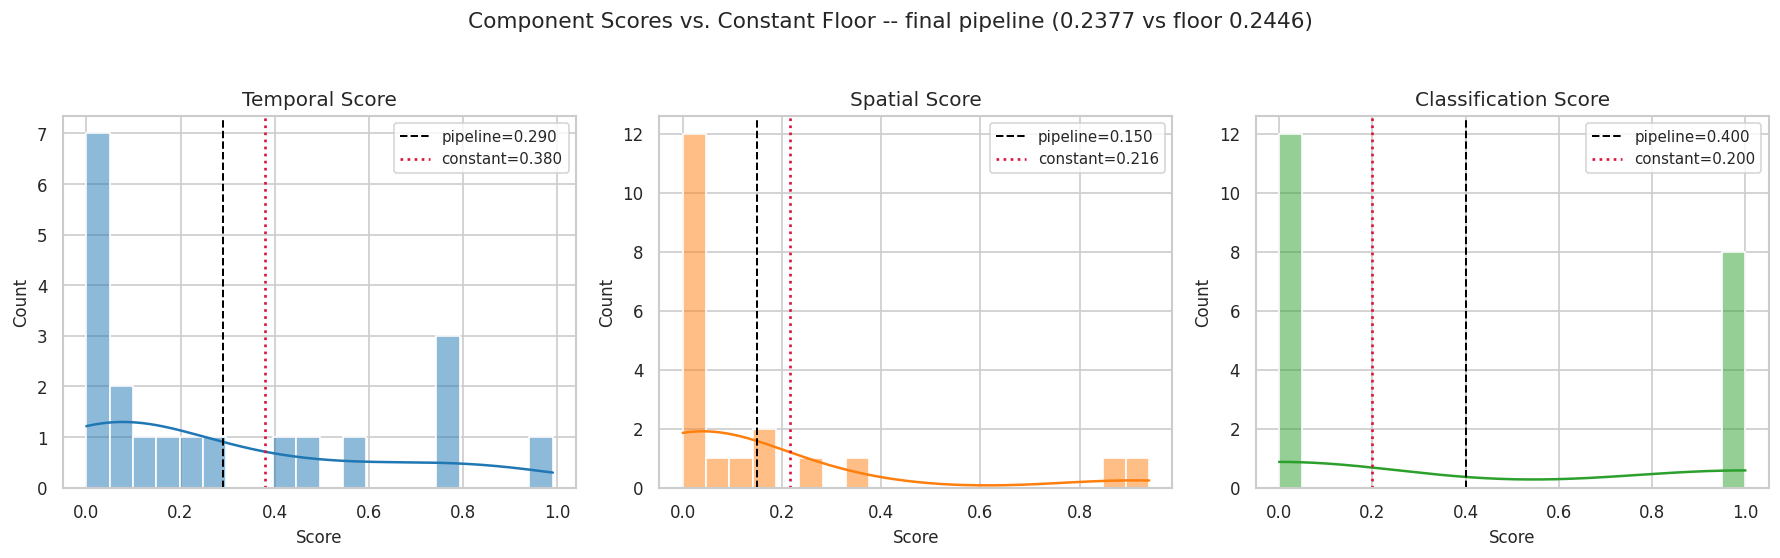

In [65]:
# [EVAL] Component score distributions vs. the constant floor -- final pipeline
if not eval_final.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    score_cols  = ['T', 'S', 'C']
    score_names = ['Temporal Score', 'Spatial Score', 'Classification Score']
    colors      = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary']]

    for ax, col, name, color in zip(axes, score_cols, score_names, colors):
        sns.histplot(eval_final[col], bins=20, kde=True, color=color, ax=ax)
        ax.axvline(eval_final[col].mean(), linestyle='--', color='black',
                   linewidth=1.2, label=f'pipeline={eval_final[col].mean():.3f}')
        ax.axvline(const_eval[col].mean(), linestyle=':', color='crimson',
                   linewidth=1.6, label=f'constant={const_eval[col].mean():.3f}')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Score', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.legend(fontsize=9)

    plt.suptitle(f'Component Scores vs. Constant Floor -- final pipeline '
                 f'({accident_score(eval_final):.4f} vs floor {accident_score(const_eval):.4f})',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

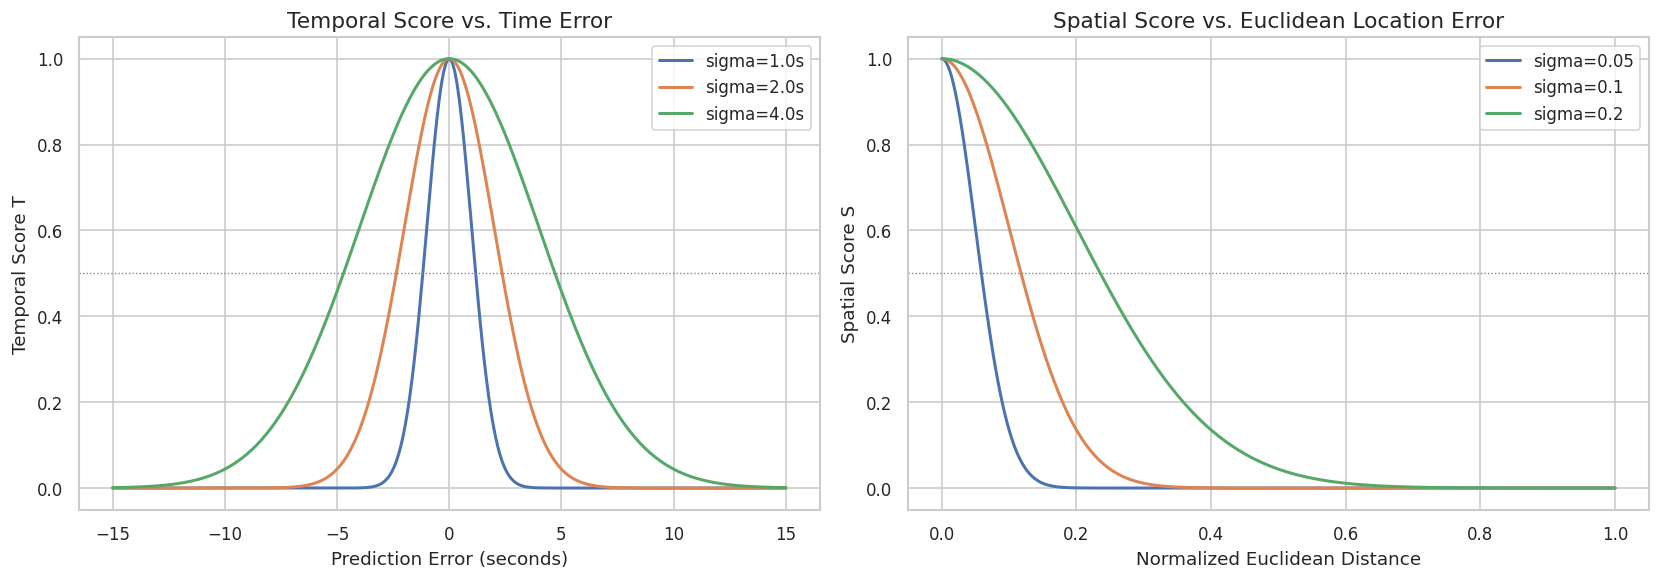

In [66]:
# [EVAL] Score sensitivity analysis -- Gaussian scoring curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_errors = np.linspace(-15, 15, 300)  # seconds from ground truth
for sigma in [1.0, 2.0, 4.0]:
    axes[0].plot(time_errors, np.exp(-0.5 * (time_errors / sigma) ** 2),
                 label=f'sigma={sigma}s', linewidth=1.8)
axes[0].set_title('Temporal Score vs. Time Error')
axes[0].set_xlabel('Prediction Error (seconds)')
axes[0].set_ylabel('Temporal Score T')
axes[0].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)
axes[0].legend()

dist_errors = np.linspace(0, 1.0, 300)  # normalized Euclidean distance
for sigma in [0.05, 0.10, 0.20]:
    axes[1].plot(dist_errors, np.exp(-0.5 * (dist_errors / sigma) ** 2),
                 label=f'sigma={sigma}', linewidth=1.8)
axes[1].set_title('Spatial Score vs. Euclidean Location Error')
axes[1].set_xlabel('Normalized Euclidean Distance')
axes[1].set_ylabel('Spatial Score S')
axes[1].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)
axes[1].legend()

plt.tight_layout()
plt.show()

### 7d-bis. What Is the VLM Actually Saying?

The first calibration run predicted **`t-bone` for all seven clips it reached**, four of them `head-on` and three `rear-end` — C=0/7. Times and coordinates varied per clip, so the model was responding to the video rather than emitting a constant; only the type collapsed.

That has two candidate explanations and they need different fixes:

1. **The model is answering badly.** A collapsed class is the documented failure mode of small VLMs on this task — the reference reports *"InternVL3.5-8B and Gemma 3-27B mapped most predictions to rear-end"* and *"Cosmos-Reason2 missed the t-bone class entirely."* Here it is 4-bit 8B, and after the OOM retries it saw 12 frames over ~20 s.
2. **The model is answering fine and we are mis-reading it.** JSON in a code fence, a label like `"T-bone"` or `"t_bone"`, a refusal, or truncation at `max_new_tokens` would all be silently coerced to a default by `normalize_prediction`.

Guessing between these is pointless when the raw string is one print away. This cell dumps exactly what comes back, before any parsing.

In [ ]:
# [DIAG] Dump the raw Stage-1 output -- no parsing, no coercion
DEBUG_N = 3

for vp, gt in zip(diverse_videos[:DEBUG_N], diverse_labels_df['type'][:DEBUG_N]):
    cap = cv2.VideoCapture(str(vp))
    _fps, _n = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = (_n / _fps) if _fps > 0 else 20.0

    frames = sample_frames_stamped(vp, VLM_CFG['whole_fps'], limit=VLM_CFG['whole_limit'],
                                   max_side=VLM_CFG['image_max_side'], burn=True)
    print('=' * 70)
    print(f'{vp.name}  |  ground truth: {gt}  |  duration {duration:.1f}s')
    print(f'{len(frames)} frames @ {frames[0][1].size} '
          f'(~{frames[0][1].size[0] * frames[0][1].size[1] // 784} visual tokens each, '
          f'~{len(frames) * frames[0][1].size[0] * frames[0][1].size[1] // 784} total)')
    print(f'timestamps: {[round(t, 1) for t, _ in frames[:8]]}...')

    raw = vlm_generate(build_stage1_prompt(duration, ''), [im for _, im in frames])
    print(f'\n--- RAW ---\n{raw!r}\n')
    parsed = _extract_json(raw)
    print(f'parsed : {parsed}')
    print(f'final  : {normalize_prediction(parsed, duration)}')
    if parsed is None:
        print('>>> JSON DID NOT PARSE -- every field below is a default, not a prediction')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### 7d. Qwen3-VL Pipeline on the Calibration Set

Twenty videos, three VLM calls each, scored against the same constant floor as everything else. **This is the number that decides whether the full run is worth 8 hours**, and no version of this notebook has ever produced it: every score in Section 7 so far belongs to the tracking pipeline.

Reference points, all on the real test set: the constant floor here is ~0.24, the tracking pipeline ~0.24, a *single* VLM call is 0.42238, and the winning three-stage 32B system is 0.57080.

Three caveats on reading the number:

- **The calibration clips are CARLA, not CCTV.** This measures the pipeline, not the sim-to-real transfer, and the VLM was never tuned on either.
- **No scene hint fires here.** `scene_layout` exists only for the real test clips, so both the Stage-1 hint (+0.00216) and the t-bone rule (+0.00466) are inactive on synthetic. The real-set score should be slightly *higher* than what this cell reports.
- **n=20.** One video is 0.05 of C. Read the gap, not the digits.

In [1]:
# [EVAL] Qwen3-VL three-stage pipeline on the calibration set
if not VLM_AVAILABLE:
    raise RuntimeError('VLM unavailable -- run Section 6.10 first.')

vlm_calib_rows = []
_t0 = time.time()
for _i, vp in enumerate(diverse_videos):
    vlm_calib_rows.append(run_inference_vlm(vp))
    _el = time.time() - _t0
    print(f'[STATUS] {_i+1}/{len(diverse_videos)}: {vp.name} | '
          f'{vlm_calib_rows[-1]["accident_time"]:.2f}s '
          f'({vlm_calib_rows[-1]["center_x"]:.2f}, {vlm_calib_rows[-1]["center_y"]:.2f}) '
          f'{vlm_calib_rows[-1]["type"]} | {_el/(_i+1):.1f}s/video')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

calib_df_vlm = pd.DataFrame(vlm_calib_rows)
eval_vlm = score_predictions(calib_df_vlm, diverse_labels_df)

# Per-video seconds here is the honest input to the full-run projection: 2027
# clips at this rate is the real cost, and Kaggle sessions cap at 12 h.
_sec = (time.time() - _t0) / len(diverse_videos)
print(f'\n[TIMING] {_sec:.1f}s/video -> {_sec*len(real_videos)/3600:.1f} h for '
      f'{len(real_videos)} test clips')

print(f'\n[COMPARISON] Calibration set (n={len(eval_vlm)})')
_cmp = pd.DataFrame({
    'constant floor': [const_eval['T'].mean(), const_eval['S'].mean(),
                       const_eval['C'].mean(), accident_score(const_eval)],
    'tracking (6.2-6.9)': [eval_final['T'].mean(), eval_final['S'].mean(),
                           eval_final['C'].mean(), accident_score(eval_final)],
    'Qwen3-VL (6.10)': [eval_vlm['T'].mean(), eval_vlm['S'].mean(),
                        eval_vlm['C'].mean(), accident_score(eval_vlm)],
}, index=['T', 'S', 'C', 'ACCIDENT score']).round(4)
display(_cmp)

_floor = accident_score(const_eval)
_got = accident_score(eval_vlm)
print(f'[VERDICT] Qwen3-VL {_got:.4f} vs constant floor {_floor:.4f} -- '
      f'{"BEATS" if _got > _floor else "LOSES TO"} it')
for comp in ['T', 'S', 'C']:
    f, g = const_eval[comp].mean(), eval_vlm[comp].mean()
    print(f'  {comp}: {g:.4f} vs constant {f:.4f}  '
          f'{"BEATS" if g > f else "LOSES TO"}')

print('\n[CONFUSION] predicted vs ground-truth type')
display(pd.crosstab(eval_vlm['type_gt'], eval_vlm['type_pred']))

# A pipeline that has quietly stopped working looks exactly like a constant.
if calib_df_vlm['type'].nunique() <= 1:
    print('[WARNING] every clip got the same type -- check the raw VLM output')
if float(calib_df_vlm[['center_x', 'center_y']].std().mean()) < 1e-6:
    print('[WARNING] every clip got the same point -- Stage 3 is not returning coordinates')

NameError: name 'VLM_AVAILABLE' is not defined

### 7c. Negative Result: Optical-Flow Angle Classification (Removed)

An earlier revision classified collision type from the angle between the two dominant optical-flow direction clusters just before impact (KMeans on high-magnitude flow vectors, angle thresholds per type). It is documented here as a negative result so it is not re-tried:

- On a head-on-only calibration subset it reached **0.80 accuracy** and looked promising.
- On the diverse 5-type set, the measured angles for `single`, `sideswipe`, and `t-bone` videos clustered at **~150-178 degrees** -- the "opposite directions" signature -- because compression noise and background traffic dominate the flow field. The signal does not separate the classes it was meant to separate.
- Precision of a confident head-on commit was **0.09-0.14** across thresholds 140-175 degrees, and a full grid search over all four thresholds topped out at **0.25 accuracy** -- below the CLIP-only baseline (0.35).
- Folded into the pipeline, it dragged overall classification from C=0.35 down to C=0.10.

*(The C values quoted above are from earlier runs on different calibration splits; the ordering is the point, not the absolute numbers. Note also that the constant 'rear-end' predictor scores C=0.359 under the natural synthetic prior -- above every zero-shot classifier tried here, including the CLIP baseline.)*

The general lesson transferred to the current design: **every component must be validated on all five types before being trusted**, and hard rule-based overrides lose to soft probabilistic ensembles when the underlying signal is noisy.

Note that the *tracking-based* geometry of Section 6.3 is not the same idea resurrected: raw optical flow mixed background traffic and compression noise into a single velocity field, whereas track velocities come from the two involved objects only, the signal abstains outside its confident angle bands, is gated on track quality, is cross-checked against an independent temporal anchor, and enters a soft ensemble instead of overriding it.

---
## 8. Test Inference and Submission

The final pipeline runs on the real CCTV test set.

- **Runtime.** The previous design projected ~13.3 h for 2027 videos at ~20.5 s each, over Kaggle's 12 h session limit, because Qwen alone spent ~10 s per video on three prompts. With Qwen, the Perception Encoder, and OWLv2 removed, only YOLO tracking and (optionally) CLIP remain. Re-measure with the `SUBSET_N` dry run rather than trusting this paragraph: the projection printed by the cell below is the number that counts.
- `SUBSET_N` is the dry-run switch: process the first N videos to measure per-video latency, project the full-run ETA, and surface OOM early — then set it to `None` for the full run.
- Predictions are **checkpointed** to `preds_checkpoint.csv` every 25 videos, so a session that dies resumes instead of restarting. Delete the checkpoint to force a clean run.
- **Unmatched rows fall back to `CONST`** (Section 6.7), not to a hardcoded guess.

In [ ]:
# [SUBMIT] Full test set inference -- final pipeline, checkpointed for 12 h sessions
# ============================================================
# SUBSET_N: dry-run switch.
#   SUBSET_N = 100  -> first 100 videos only: measures s/video, projects the
#                      full-run ETA, and catches OOM early.
#   SUBSET_N = None -> full run over all real test videos (the real submission).
# ============================================================
SUBSET_N = 10   # <-- 10 first: confirms the VLM runs on real clips and
                #     measures s/video. Then None for the full run.

# The Qwen3-VL pipeline of Section 6.10. run_inference_final (tracking) is kept
# only for the Section 7 comparison -- it measures below the constant floor and
# must not be submitted. Swap this to compare, but read Section 7b first.
SUBMIT_PIPELINE = run_inference_vlm

if SUBMIT_PIPELINE is run_inference_vlm and not VLM_AVAILABLE:
    raise RuntimeError('Refusing to run: the VLM is unavailable, so every prediction '
                       'would be a constant. Fix Section 6.10 first.')

CHECKPOINT_PATH = OUTPUT_DIR / 'preds_checkpoint.csv'
CHECKPOINT_EVERY = 25

videos_to_run = real_videos[:SUBSET_N] if SUBSET_N is not None else real_videos
is_subset_run = SUBSET_N is not None and SUBSET_N < len(real_videos)

# Resume from checkpoint: previously processed videos are skipped, so a run
# interrupted by the session limit continues in the next session.
test_results, done_paths = [], set()
if CHECKPOINT_PATH.exists():
    prev = pd.read_csv(CHECKPOINT_PATH)
    test_results = prev.to_dict('records')
    done_paths = set(prev['path'])
    print(f'[STATUS] Checkpoint found: {len(done_paths)} videos already processed -- resuming')

print(f'[STATUS] Final-pipeline inference on {len(videos_to_run)} video(s) '
      f'{"(SUBSET DRY RUN)" if is_subset_run else "(FULL RUN)"} '
      f'out of {len(real_videos)} total')

per_video_times = []
run_start = time.time()

for i, vp in enumerate(videos_to_run):
    sub_path = 'videos/' + vp.name  # submission path format
    if sub_path in done_paths:
        continue

    t0 = time.time()
    # sub_path is passed so Stage 1 can look up scene_layout for this clip
    result = SUBMIT_PIPELINE(vp, sub_path)
    per_video_times.append(time.time() - t0)

    result['path'] = sub_path
    test_results.append(result)
    done_paths.add(sub_path)

    if len(test_results) % CHECKPOINT_EVERY == 0:
        pd.DataFrame(test_results).to_csv(CHECKPOINT_PATH, index=False)

    if (i + 1) % 10 == 0 or (i + 1) == len(videos_to_run):
        avg_t   = sum(per_video_times) / len(per_video_times)
        elapsed = time.time() - run_start
        remaining = avg_t * max(0, len(videos_to_run) - len(test_results))
        print(f'[STATUS] {len(test_results)}/{len(videos_to_run)} | avg {avg_t:.2f}s/video | '
              f'elapsed {elapsed/60:.1f} min | remaining ~{remaining/3600:.2f} h | '
              f'full-set projection ~{avg_t * len(real_videos)/3600:.2f} h')
        if avg_t * len(real_videos) > 11 * 3600:
            print('[WARNING] Full-set projection exceeds one 12 h Kaggle session -- '
                  'the checkpoint lets you split the run across sessions safely')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(test_results).to_csv(CHECKPOINT_PATH, index=False)

test_preds_df = pd.DataFrame(test_results)
test_preds_df = test_preds_df[test_preds_df['path'].isin(
    {'videos/' + vp.name for vp in videos_to_run})].reset_index(drop=True)
assert len(test_preds_df) == len(videos_to_run), 'Some videos were dropped during inference'
print(f'[SUCCESS] Inference complete on {len(test_preds_df)} video(s) '
      f'(this session: {len(per_video_times)}, {(time.time() - run_start)/60:.1f} min)')
if 'track_used' in test_preds_df.columns:
    print(f"[STATUS] Tracking trusted on {test_preds_df['track_used'].mean():.0%} of test videos "
          '-- a sharp drop vs calibration signals a synthetic-to-real detection gap')
display(test_preds_df.head())

In [ ]:
# [SUBMIT] Align predictions with the sample submission schema and save
if is_subset_run:
    # Dry run: save under a distinct name so it is never confused with the real submission
    submission_df = test_preds_df[['path', 'accident_time', 'center_x', 'center_y', 'type']].copy()
    SUBMISSION_PATH = OUTPUT_DIR / f'submission_dryrun_{len(videos_to_run)}.csv'
    print(f'[STATUS] SUBSET DRY RUN -- {SUBMISSION_PATH.name} is for validation only. '
          'Set SUBSET_N = None and re-run for the real submission.')
elif not sample_sub.empty:
    submission_df = sample_sub[['path']].merge(
        test_preds_df[['path', 'accident_time', 'center_x', 'center_y', 'type']],
        on='path', how='left',
    )
    # Unmatched rows fall back to CONST -- the constants fitted on the synthetic
    # training set in Section 6.7. The previous values here (median of our own
    # predictions, 0.5/0.5, hardcoded 'rear-end') were guesses that happened to
    # land near the fitted optimum; there is no reason to guess when the prior
    # has been measured.
    n_unmatched = submission_df['type'].isnull().sum()
    if n_unmatched > 0:
        print(f'[WARNING] {n_unmatched} submission rows had no matching prediction '
              '-- filling with the fitted constant prior')
    submission_df = submission_df.fillna({
        'accident_time': CONST['accident_time'],
        'center_x': CONST['center_x'],
        'center_y': CONST['center_y'],
        'type': CONST['type'],
    })
    assert len(submission_df) == len(sample_sub), 'Submission row count mismatch'
    SUBMISSION_PATH = OUTPUT_DIR / 'submission.csv'
else:
    submission_df = test_preds_df[['path', 'accident_time', 'center_x', 'center_y', 'type']].copy()
    SUBMISSION_PATH = OUTPUT_DIR / 'submission.csv'

submission_df.to_csv(SUBMISSION_PATH, index=False)
# Degenerate-output check. A pipeline that has silently stopped working produces
# a submission with almost no variety -- one type, one point, one time. That is
# indistinguishable from a valid file until the leaderboard says nothing moved.
_n_types = submission_df['type'].nunique()
_xy_std = float(submission_df[['center_x', 'center_y']].std().mean())
_t_std = float(submission_df['accident_time'].std())
print(f'[CHECK] distinct types={_n_types} | xy std={_xy_std:.4f} | time std={_t_std:.3f}')
if _n_types <= 1 or _xy_std < 1e-6:
    print('[WARNING] This submission is (near) constant -- one collision type and/or a '
          'single impact point for every clip. That is what a dead model looks like. '
          'Check the VLM canary in Section 6.10 before submitting.')

print(f'[SUCCESS] Saved: {SUBMISSION_PATH} ({len(submission_df)} rows)')
display(submission_df.head())

In [ ]:
# [SUBMIT] Predicted collision type distribution
if not submission_df.empty and 'type' in submission_df.columns:
    pred_type_dist = submission_df['type'].value_counts().reset_index()
    pred_type_dist.columns = ['collision_type', 'count']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=pred_type_dist, x='collision_type', y='count', palette='Set2', ax=ax)
    ax.set_title('Predicted Collision Type Distribution (Test Set)')
    ax.set_xlabel('Predicted Collision Type')
    ax.set_ylabel('Count')
    ax.bar_label(ax.containers[0], fontsize=9)
    plt.tight_layout()
    plt.show()

In [ ]:
# [SUBMIT] Predicted accident time distribution
if not submission_df.empty and 'accident_time' in submission_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(submission_df['accident_time'], bins=30, kde=True,
                 color=PALETTE['primary'], ax=ax)
    ax.set_title('Predicted Accident Time Distribution (Test Set)')
    ax.set_xlabel('Predicted Accident Time (seconds)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

In [ ]:
# [SUBMIT] Predicted impact location scatter
if not submission_df.empty and all(c in submission_df.columns for c in ['center_x', 'center_y']):
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(submission_df['center_x'], submission_df['center_y'],
                         alpha=0.4, s=25, c=submission_df['center_y'], cmap='viridis')
    plt.colorbar(scatter, ax=ax, label='center_y')
    ax.set_title('Predicted Impact Location Distribution (Test Set)')
    ax.set_xlabel('center_x (0=left, 1=right)')
    ax.set_ylabel('center_y (0=top, 1=bottom)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## 9. Conclusion

### What was wrong

- **The metric was implemented incorrectly, and that error drove the design.** `score_predictions` computed a harmonic mean per video and averaged it. The competition averages T, S, and C across videos *first*, then takes the harmonic mean of those three numbers. Because C is 0/1, the per-video variant zeroes every misclassified video and is bounded above by accuracy. It reported 0.087 for the baseline (real value **0.2321**) and 0.0000 for the final pipeline (real value **0.1739**).
- **Which made classification look decisive when it is the weakest lever.** The claim "the harmonic mean is 0 whenever the type is wrong" is false. On the baseline, raising C from 0.30 to 0.45 is worth **+0.022**; raising S from 0.156 to 0.45 is worth **+0.111**. Nearly all the modelling effort — a three-signal ensemble, prompt engineering, a scene-plausibility rule — went into the component with one fifth the leverage.
- **The pipeline scored below a constant on every component.** Because the scoring sigma is comparable to the spread of the labels themselves, predicting the dataset's central constant is strong: T=0.518 against the frame-difference anchor's 0.314, S≈0.295 against OWLv2/optical-flow's 0.156, C=0.359 against CLIP's 0.300 (and the final ensemble's 0.150, below the 0.20 chance level). Estimated constant-only score ≈ **0.370**, against 0.232 for the baseline. Five models and ~11.5 h of T4 produced less than three numbers.
- **Fallbacks made it worse, not better.** Every stage fell back from a weak model to a weaker one. A fallback must be the prior.
- **The ensemble collapsed for a structural reason.** Qwen's three prompts are quantised to {0, ⅓, ⅔, 1}, so a unanimous vote contributed the full 0.35, while CLIP's probability mass spread over five classes gave its argmax ≈0.21. Qwen won whenever it was unanimous — which was almost always, because the three prompts ask the same question of six 448px stills in which the vehicles span a few dozen pixels, so it fell back on a language prior where `rear-end` is the most common accident. Result: `rear-end` on 18/20 videos.
- **Two tracking bugs.** NMS at the default `iou=0.7` deleted one of the two colliding vehicles as a duplicate at the exact moment of impact. `np.convolve(mode='same')` zero-padded the trajectory ends, fabricating a deceleration of up to 680 px/s precisely where `_impact_time` searches for one.

### What changed

Metric corrected. Constant prior fitted on the synthetic training set and installed as the fallback for every stage. NMS `iou=0.9`; two-stage confidence-split association so tracks survive the confidence collapse at impact; Savitzky-Golay smoothing. Tracking gated on its own kinetic evidence rather than on agreement with an anchor weaker than a constant. Qwen, the Perception Encoder, and OWLv2 removed. A supervised classifier over domain-invariant track kinematics, trained on the 2211 labelled synthetic videos the organizers provide for pretraining — previously used only for EDA.

### What is still unmeasured

The numbers above are from the calibration run of the previous design, plus analytic estimates from the label statistics. Pending:

1. **Section 6.8** — does tracking fire on real CCTV at all? Every downstream claim depends on it and none of it has been tested outside CARLA.
2. **Section 7b** — per-signal ablation, and the `TRACK_EVIDENCE_MIN` sweep.
3. **Section 6.9** — grouped-by-map CV accuracy, and the coverage-weighted C that follows.
4. **The scoring sigmas are assumptions.** The Evaluation page says only "Gaussian-style". At σ_S=0.05 a constant scores 0.095; at σ_S=0.20, 0.622. The priority order between S and C inverts across that range.

### Method notes

- **Measure against the prior, not against zero.** Every component here beat "doing nothing" and lost to "predicting the average". Without a floor, a pipeline can be elaborate, expensive, and worse than a constant while every individual piece looks like it is contributing.
- **Validate on the axis that will shift.** Section 7b's earlier failure (0.80 on a head-on-only subset, 0.10 on a diverse one) and the `map`-grouped CV here are the same lesson at different scales: a split that does not vary what the test set varies reports a number that means nothing.
- **Prefer physics to pixels across a domain gap.** Angles and ratios transfer from CARLA to CCTV; render statistics do not.

---
## 10. References

1. **Competition:** [ACCIDENT @ CVPR 2026 -- Kaggle](https://kaggle.com/competitions/accident)
2. **Workshop:** [AUTOPILOT @ CVPR 2026](https://autopilot-workshop.github.io)
3. **SORT:** Bewley, A. et al. "Simple Online and Realtime Tracking." ICIP 2016. [arXiv:1602.00763](https://arxiv.org/abs/1602.00763)
4. **Hungarian algorithm:** Kuhn, H. W. "The Hungarian Method for the Assignment Problem." Naval Research Logistics Quarterly, 1955.
5. **YOLOv8:** Jocher, G. et al. Ultralytics YOLOv8. [https://github.com/ultralytics/ultralytics](https://github.com/ultralytics/ultralytics)
6. **CLIP:** Radford, A. et al. "Learning Transferable Visual Models From Natural Language Supervision." ICML 2021. [arXiv:2103.00020](https://arxiv.org/abs/2103.00020)
7. **Perception Encoder:** Bolya, D. et al. "Perception Encoder: The best visual embeddings are not at the output of the network." 2025. [arXiv:2504.13181](https://arxiv.org/abs/2504.13181)
8. **Qwen2.5-VL:** Bai, S. et al. "Qwen2.5-VL Technical Report." 2025. [arXiv:2502.13923](https://arxiv.org/abs/2502.13923)
9. **OWLv2:** Minderer, M. et al. "Scaling Open-Vocabulary Object Detection." NeurIPS 2023. [arXiv:2306.09683](https://arxiv.org/abs/2306.09683)
10. **Optical Flow (Farneback):** Farneback, G. "Two-Frame Motion Estimation Based on Polynomial Expansion." SCIA 2003. [Springer](https://link.springer.com/chapter/10.1007/3-540-45103-X_50)
11. **CARLA Simulator:** Dosovitskiy, A. et al. "CARLA: An Open Urban Driving Simulator." CoRL 2017. [arXiv:1711.03938](https://arxiv.org/abs/1711.03938)
12. **OpenCV Documentation:** [https://docs.opencv.org](https://docs.opencv.org)
13. **Traffic accident video datasets survey:** Bouzid, Y. et al. "Anomaly Detection in Traffic Surveillance Videos: A Survey." Sensors 2022.